# DỰ BÁO CHI PHÍ ĐIỀU TRỊ CHO BỆNH NHÂN MẮC BỆNH HIỂM NGHÈO (SUPPORT2)
- Mục đích: Cải thiện quá trình ra quyết định trong chăm sóc bệnh nhân nặng. Cung cấp cái nhìn thực tế cho gia đình và bác sĩ về chi phí chữa bệnh, nhằm giảm thiểu tình trạng kéo dài sự sống một cách đau đớn và không cần thiết.
- Thành viên: Trần Đức Kiên, Tạ Văn Nghĩa, Vũ Tiến Đạt.

## 1. Import Thư viện & Cài đặt chung

In [3]:
# Install packages
#!pip install -q pandas numpy matplotlib seaborn scikit-learn ucimlrepo

In [1]:


import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json

#tránh lỗi nếu chưa có thư mục
import os
save_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')
os.makedirs(save_dir, exist_ok=True)

import warnings
warnings.filterwarnings('ignore')

# ham tinh khoang cach giua Xa va Xb
from scipy.spatial.distance import cdist


# Tải dữ liệu trực tiếp từ repo UCI
from ucimlrepo import fetch_ucirepo 

# sklearn 
# ham xac dinh k optima
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

from scipy.stats import pearsonr

SEP = "_" * 72
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 130)
pd.set_option('display.float_format', '{:.3f}'.format)

# color 
C = {'blue':'#2563EB','red':'#DC2626','green':'#16A34A',
     'amber':'#D97706','gray':'#6B7280','bg':'#F8FAFC','dark':'#1E293B',
     'purple':'#7C3AED','teal':'#0D9488'}

# plot 
plt.rcParams.update({'figure.facecolor':C['bg'],'axes.facecolor':C['bg'],
                    'axes.spines.top':False,'axes.spines.right':False,
                    'axes.titlesize':11,'axes.labelsize':9,'font.family':'DejaVu Sans'})

## 2. Khám pháp dữ liệu (EDA - Exploratory Data Analysis)

### 2.1 Đọc dữ liệu 

In [5]:
support2 = fetch_ucirepo(id=880)
df_raw = pd.concat([support2.data.features, support2.data.targets], axis=1)

# In ra cấu trúc tổng quan gồm số hàng, cột, danh sách cột
N_ROWS, N_COLS = df_raw.shape
print(f"Number of Observations: {N_ROWS}")
print(f"Number of Features: {N_COLS}")
print(f"Features: \n{df_raw.columns.tolist()}\n")

KeyboardInterrupt: 

### 2.2 Mô tả cấu trúc dữ liệu 

In [ ]:
# Định nghĩa N_ROWS, N_COLS và in ra cấu trúc tổng quan
N_ROWS, N_COLS = df_raw.shape
print(f"Tổng số bản ghi (Rows): {N_ROWS}")
print(f"Tổng số trường (Columns): {N_COLS}")
print(f"Danh sách các trường:\n{df_raw.columns.tolist()}\n")

Tổng số bản ghi (Rows): 9105
Tổng số trường (Columns): 45
Danh sách các trường:
['age', 'sex', 'dzgroup', 'dzclass', 'num.co', 'edu', 'income', 'scoma', 'charges', 'totcst', 'totmcst', 'avtisst', 'race', 'sps', 'aps', 'surv2m', 'surv6m', 'hday', 'diabetes', 'dementia', 'ca', 'prg2m', 'prg6m', 'dnr', 'dnrday', 'meanbp', 'wblc', 'hrt', 'resp', 'temp', 'pafi', 'alb', 'bili', 'crea', 'sod', 'ph', 'glucose', 'bun', 'urine', 'adlp', 'adls', 'adlsc', 'death', 'hospdead', 'sfdm2']



### 2.3 Thống kê sơ bộ 

In [ ]:
# Thống kê sơ bộ
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 45 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       9105 non-null   float64
 1   sex       9105 non-null   object 
 2   dzgroup   9105 non-null   object 
 3   dzclass   9105 non-null   object 
 4   num.co    9105 non-null   int64  
 5   edu       7471 non-null   float64
 6   income    6123 non-null   object 
 7   scoma     9104 non-null   float64
 8   charges   8933 non-null   float64
 9   totcst    8217 non-null   float64
 10  totmcst   5630 non-null   float64
 11  avtisst   9023 non-null   float64
 12  race      9063 non-null   object 
 13  sps       9104 non-null   float64
 14  aps       9104 non-null   float64
 15  surv2m    9104 non-null   float64
 16  surv6m    9104 non-null   float64
 17  hday      9105 non-null   int64  
 18  diabetes  9105 non-null   int64  
 19  dementia  9105 non-null   int64  
 20  ca        9105 non-null   obje

In [ ]:
df_raw.describe()

,age,num.co,edu,scoma,charges,totcst,totmcst,avtisst,sps,aps,surv2m,surv6m,hday,diabetes,dementia,prg2m,prg6m,dnrday,meanbp,wblc,hrt,resp,temp,pafi,alb,bili,crea,sod,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead
count,9105.000,9105.000,7471.000,9104.000,8933.000,8217.000,5630.000,9023.000,9104.000,9104.000,9104.000,9104.000,9105.000,9105.000,9105.000,7456.000,7472.000,9075.000,9104.000,8893.000,9104.000,9104.000,9104.000,6780.000,5733.000,6504.000,9038.000,9104.000,6821.000,4605.000,4753.000,4243.000,3464.000,6238.000,9105.000,9105.000,9105.000
mean,62.651,1.869,11.748,12.059,59995.788,30825.868,28828.878,22.611,25.526,37.598,0.636,0.520,4.400,0.195,0.033,0.619,0.500,14.583,84.546,12.348,97.157,23.330,37.103,239.529,2.951,2.554,1.771,137.569,7.415,159.873,32.349,2191.546,1.158,1.637,1.888,0.681,0.259
std,15.594,1.344,3.448,24.637,102648.778,45780.821,43604.262,13.233,9.899,19.904,0.248,0.253,9.127,0.396,0.177,0.298,0.304,19.944,27.688,9.266,31.559,9.574,1.252,109.666,0.876,5.318,1.686,6.029,0.081,88.392,26.792,1455.246,1.740,2.231,2.004,0.466,0.438
min,18.042,0.000,0.000,0.000,1169.000,0.000,-102.720,1.000,0.200,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,-88.000,0.000,0.000,0.000,0.000,31.699,12.000,0.400,0.100,0.100,110.000,6.829,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,52.797,1.000,10.000,0.000,9740.000,5929.566,5177.404,12.000,19.000,23.000,0.508,0.343,1.000,0.000,0.000,0.500,0.200,4.000,63.000,7.000,72.000,18.000,36.195,155.094,2.400,0.500,0.900,134.000,7.380,103.000,14.000,1165.500,0.000,0.000,0.000,0.000,0.000
50%,64.857,2.000,12.000,0.000,25024.000,14452.734,13223.500,19.500,23.898,34.000,0.716,0.575,1.000,0.000,0.000,0.700,0.500,9.000,77.000,10.600,100.000,24.000,36.695,224.000,2.900,0.900,1.200,137.000,7.420,135.000,23.000,1968.000,0.000,1.000,1.000,1.000,0.000
75%,73.999,3.000,14.000,9.000,64598.000,36087.938,34223.602,31.667,30.199,49.000,0.826,0.726,3.000,0.000,0.000,0.900,0.750,17.000,107.000,15.299,120.000,28.000,38.195,304.750,3.600,1.900,1.900,141.000,7.470,188.000,42.000,3000.000,2.000,3.000,3.000,1.000,1.000
max,101.848,9.000,31.000,100.000,1435423.000,633212.000,710682.000,83.000,99.188,143.000,0.970,0.948,148.000,1.000,1.000,1.000,1.000,285.000,195.000,200.000,300.000,90.000,41.695,890.375,29.000,63.000,21.500,181.000,7.770,1092.000,300.000,9000.000,7.000,7.000,7.073,1.000,1.000


In [ ]:

num_cols = df_raw.select_dtypes(include='number').columns.tolist()
obj_cols = df_raw.select_dtypes(include='object').columns.tolist()

print(f"\n THỐNG KÊ MÔ TẢ — NUMERICAL ({len(num_cols)} cột)")
desc = df_raw[num_cols].describe().T
desc['skew']   = df_raw[num_cols].skew().round(3)
desc['null%']  = (df_raw[num_cols].isna().sum() / N_ROWS * 100).round(1)
print(desc[['count','mean','std','min','50%','max','skew','null%']].to_string())

print(f"\n THỐNG KÊ MÔ TẢ — CATEGORY ({len(obj_cols)} cột)")
for col in obj_cols:
    vc = df_raw[col].value_counts(dropna=False)
    print(f"\n  ▸ {col}  (unique={df_raw[col].nunique()}, null={df_raw[col].isna().sum()})")
    print(vc.head(6).to_string())


 THỐNG KÊ MÔ TẢ — NUMERICAL (37 cột)
            count      mean        std      min       50%         max   skew  null%
age      9105.000    62.651     15.594   18.042    64.857     101.848 -0.502  0.000
num.co   9105.000     1.869      1.344    0.000     2.000       9.000  0.823  0.000
edu      7471.000    11.748      3.448    0.000    12.000      31.000 -0.058 17.900
scoma    9104.000    12.059     24.637    0.000     0.000     100.000  2.334  0.000
charges  8933.000 59995.788 102648.778 1169.000 25024.000 1435423.000  4.687  1.900
totcst   8217.000 30825.868  45780.821    0.000 14452.734  633212.000  3.955  9.800
totmcst  5630.000 28828.878  43604.262 -102.720 13223.500  710682.000  4.364 38.200
avtisst  9023.000    22.611     13.233    1.000    19.500      83.000  0.766  0.900
sps      9104.000    25.526      9.899    0.200    23.898      99.188  1.605  0.000
aps      9104.000    37.598     19.904    0.000    34.000     143.000  0.945  0.000
surv2m   9104.000     0.636      0.248

### 2.4 Trực quan hóa biến mục tiêu

### 2.5 Ma trận tương quan 

## 3. Tiền xử lý dữ liệu

### 3.1 Làm sạch và xử lý dữ liệu lỗi

In [ ]:
print(f"\n{SEP}")
print("  PHẦN 3.1 — LÀM SẠCH VÀ XỬ LÝ DỮ LIỆU LỖI")
print(SEP)

# Tạo bản sao để làm sạch
df = df_raw.copy()



________________________________________________________________________
  PHẦN 3.1 — LÀM SẠCH VÀ XỬ LÝ DỮ LIỆU LỖI
________________________________________________________________________


In [ ]:
# [1] Xóa các hàng thiếu trường 'charge'
n_missing_target = df['charges'].isna().sum()
df.dropna(subset=['charges'], inplace=True)
print(f"[2.0] Đã xóa {n_missing_target} bản ghi bị thiếu biến mục tiêu 'charges'")

[2.0] Đã xóa 172 bản ghi bị thiếu biến mục tiêu 'charges'


In [ ]:

# [2] Xóa các biến gây rò rỉ dữ liệu
# surv2m, surv6m, prg2m, prg6m là kết quả dự đoán của chính mô hình dataset SUPPORT2 hoặc của bác sĩ, không có ý nghĩa huấn luyện
# totcst, totmcst là tổng chi phí, nếu sử dụng chính 2 biến này để dự đoán chi phí sẽ gây rò rỉ dữ liệu
# death, hospdead là kết quả kết quả cuối cùng, cho biết bệnh nhân sống hay chết
# sfdm2 cho biết tình trạng bệnh nhân trong và sau 2 tháng, cũng là kết quả cuối cùng
leakage_cols = ['death', 'hospdead', 'sfdm2', 'totcst', 'totmcst', 'surv2m', 'surv6m', 'prg2m', 'prg6m']
cols_to_drop = [c for c in leakage_cols if c in df.columns]
df.drop(columns=cols_to_drop, inplace=True)
print(f"\n[2.1] Đã xóa {len(cols_to_drop)} cột gây rò rỉ dữ liệu")


[2.1] Đã xóa 9 cột gây rò rỉ dữ liệu


In [ ]:
# [3] Bản ghi trùng lặp
n_dup = df.duplicated().sum()
df.drop_duplicates(keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\n[2.2] Bản ghi trùng lặp: phát hiện {n_dup:,}, xóa → còn {len(df):,} hàng")


[2.2] Bản ghi trùng lặp: phát hiện 0, xóa → còn 8,933 hàng


In [ ]:
# [4] Chuẩn hóa giá trị cột phân loại (inconsistency)
SEX_MAP = {'male':'male','Male':'male','MALE':'male','m':'male','M':'male',
           'female':'female','Female':'female','FEMALE':'female','f':'female','F':'female'}
CA_MAP  = {'yes':'yes','Yes':'yes','YES':'yes',
           'no':'no','No':'no','NO':'no',
           'metastatic':'metastatic','Metastatic':'metastatic'}

if 'sex' in df.columns: df['sex'] = df['sex'].astype(str).str.strip().map(SEX_MAP)
if 'ca' in df.columns:  df['ca']  = df['ca'].astype(str).str.strip().map(CA_MAP)

for col in ['race','income','dzgroup','dzclass']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].replace({'nan':np.nan,'none':np.nan,'':np.nan})

print(f"\n[2.3] Chuẩn hóa phân loại (xử lý hoa/thường, khoảng trắng)")


[2.3] Chuẩn hóa phân loại (xử lý hoa/thường, khoảng trắng)


In [ ]:
# [5] Giá trị ngoài khoảng y khoa (không đúng về mặt giới hạn cơ thể con người)
VALID_RANGE = {
    'age':    (18, 120),  'meanbp': (10, 300),
    'temp':   (25,  42),  'hrt':    (20, 300),
    'resp':   ( 4,  60),  'ph':     (6.5, 8.0),
    'sod':    (100, 180)
}
print(f"\n[5] Giá trị ngoài khoảng hợp lệ → NaN:")
for col, (lo, hi) in VALID_RANGE.items():
    if col not in df.columns: continue
    df[col] = pd.to_numeric(df[col], errors='coerce')
    mask = df[col].notna() & ((df[col] < lo) | (df[col] > hi))
    n = mask.sum()
    if n: df.loc[mask, col] = np.nan
    print(f"      {col:<10}: {n:4d} giá trị ngoài [{lo}, {hi}] → NaN")



[5] Giá trị ngoài khoảng hợp lệ → NaN:
      age       :    0 giá trị ngoài [18, 120] → NaN
      meanbp    :   50 giá trị ngoài [10, 300] → NaN
      temp      :    0 giá trị ngoài [25, 42] → NaN
      hrt       :   80 giá trị ngoài [20, 300] → NaN
      resp      :   72 giá trị ngoài [4, 60] → NaN
      ph        :    0 giá trị ngoài [6.5, 8.0] → NaN
      sod       :    1 giá trị ngoài [100, 180] → NaN


In [ ]:

# [6] Xử lý Missing Values
print(f"\n[6] Xử lý giá trị thiếu:")

# a. Điền theo khuyến nghị y khoa (Prof. Frank Harrell)
HARRELL_FILL = {
    'alb': 3.5, 'pafi': 333.3, 'bili': 1.01,
    'crea': 1.01, 'bun': 6.51, 'wblc': 9.0, 'urine': 2502.0
}
for col, val in HARRELL_FILL.items():
    if col in df.columns:
        n_fill = df[col].isna().sum()
        if n_fill > 0:
            df[col].fillna(val, inplace=True)
            print(f"      '{col:<5}': {n_fill:5,} NaN → domain expert = {val}")

# b. Xử lý các cột còn lại
THRESHOLD_DROP = 0.50
SKEW_THRESHOLD = 1.0
cols_dropped_na = []

for col in df.columns:
    if col == 'charges': continue # không xử lý cột của biến mục tiêu

    miss_pct = df[col].isna().mean()
    if miss_pct == 0: continue

    # Xóa cột nếu thiếu quá nhiều
    if miss_pct > THRESHOLD_DROP:
        cols_dropped_na.append(col)
        print(f"      xóa cột '{col}': thiếu {miss_pct*100:.1f}%")
        continue

    # Impute số
    if df[col].dtype in ['float64','int64']:
        skew = df[col].skew()
        if abs(skew) > SKEW_THRESHOLD:
            fill_val = df[col].median()
            method   = f'median={fill_val:.3g}'
        else:
            fill_val = df[col].mean()
            method   = f'mean={fill_val:.3g}'
    # Impute category
    else:
        mode_s = df[col].mode()
        fill_val = mode_s[0] if len(mode_s) else 'unknown'
        method   = f'mode="{fill_val}"'

    n_fill = df[col].isna().sum()
    df[col].fillna(fill_val, inplace=True)
    print(f"      '{col:<5}': {n_fill:5,} NaN → {method}")

df.drop(columns=cols_dropped_na, inplace=True, errors='ignore')

# Ép kiểu sau khi làm sạch
for col in ['age','num.co']:
    if col in df.columns:
        df[col] = df[col].fillna(0).round().astype(int)

for col in ['sex','race','income','dzgroup','dzclass','ca']:
    if col in df.columns:
        df[col] = df[col].astype('category')

print(f"\n      - Sau làm sạch: {df.shape[0]:,} hàng × {df.shape[1]} cột")
print(f"      - Giá trị thiếu trên toàn bộ Dataset: {df.isna().sum().sum()}")


[6] Xử lý giá trị thiếu:
      'alb  ': 3,292 NaN → domain expert = 3.5
      'pafi ': 2,280 NaN → domain expert = 333.3
      'bili ': 2,549 NaN → domain expert = 1.01
      'crea ':    66 NaN → domain expert = 1.01
      'bun  ': 4,294 NaN → domain expert = 6.51
      'wblc ':   209 NaN → domain expert = 9.0
      'urine': 4,797 NaN → domain expert = 2502.0
      'edu  ': 1,611 NaN → mean=11.7
      'income': 2,933 NaN → mode="under $11k"
      'avtisst':    81 NaN → mean=22.5
      'race ':    42 NaN → mode="white"
      'dnr  ':     4 NaN → mode="no dnr"
      'dnrday':     4 NaN → median=9
      'meanbp':    51 NaN → mean=85
      'hrt  ':    81 NaN → mean=98.1
      'resp ':    73 NaN → mean=23.5
      'temp ':     1 NaN → mean=37.1
      'sod  ':     2 NaN → mean=138
      'ph   ': 2,240 NaN → median=7.42
      'glucose': 4,440 NaN → median=135
      xóa cột 'adlp': thiếu 61.7%
      'adls ': 2,819 NaN → median=1

      - Sau làm sạch: 8,933 hàng × 35 cột
      - Giá trị thiếu 

### 3.2 Encoding

In [ ]:
print(f"\n{SEP}")
print("  PHẦN 3.2 — ENCODING")
print(SEP)

"""
'sex': 2 giá trị → ánh xạ về 0/1.
'ca' (Ung thư): Có thứ tự tiến triển y khoa (Không < Có < Di căn) → 0, 1, 2
"""
df_enc = df.copy()


________________________________________________________________________
  PHẦN 3.2 — ENCODING
________________________________________________________________________


In [ ]:
BINARY_MAP = {
    'sex':   {'male': 0, 'female': 1},
    'ca':    {'no': 0, 'yes': 1, 'metastatic': 2},
}
print("\n[1] Binary / Ordinal Encoding (Sex, CA):")
for col, mapping in BINARY_MAP.items():
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].map(mapping)
        print(f"      {col}: {mapping}")


[1] Binary / Ordinal Encoding (Sex, CA):
      sex: {'male': 0, 'female': 1}
      ca: {'no': 0, 'yes': 1, 'metastatic': 2}


In [ ]:
# ── 2 Ordinal Encoding (Thu nhập) ──────────────────────────────────
# Cột thu nhập có thứ tự tự nhiên.
ORDINAL_MAP = {
    'income': {'under $11k': 0, '$11-$25k': 1, '$25-$50k': 2, '>$50k': 3},
}
print("\n[2] Ordinal Encoding (Income):")
for col, mapping in ORDINAL_MAP.items():
    if col in df_enc.columns:
        df_enc[col] = df_enc[col].map(mapping)
        print(f"      {col}: {mapping}")


[2] Ordinal Encoding (Income):
      income: {'under $11k': 0, '$11-$25k': 1, '$25-$50k': 2, '>$50k': 3}


In [ ]:

# ── 3 One-Hot Encoding (Nominal không có thứ tự) ───────────────────
"""
Các cột phân loại không có thứ tự (dzgroup, dzclass, race).
Sử dụng drop_first=True để tránh đa cộng tuyến.
"""
OHE_COLS = ['race', 'dzgroup', 'dzclass', 'dnr']
OHE_COLS = [c for c in OHE_COLS if c in df_enc.columns]

print(f"\n[3] One-Hot Encoding: {OHE_COLS}")
df_before_ohe = df_enc.shape[1]

for col in OHE_COLS:
    dummies = pd.get_dummies(df_enc[col], prefix=col, drop_first=True, dtype=int)
    df_enc  = pd.concat([df_enc.drop(columns=[col]), dummies], axis=1)
    print(f"      '{col}' → {dummies.shape[1]} cột mới")

print(f"\n      Số cột: {df_before_ohe} → {df_enc.shape[1]} (thêm {df_enc.shape[1]-df_before_ohe} cột OHE)")


[3] One-Hot Encoding: ['race', 'dzgroup', 'dzclass', 'dnr']
      'race' → 4 cột mới
      'dzgroup' → 7 cột mới
      'dzclass' → 3 cột mới
      'dnr' → 2 cột mới

      Số cột: 35 → 47 (thêm 12 cột OHE)


In [ ]:
# ── 4 Kiểm tra kết quả encoding ────────────────────────────────────
remaining_obj = df_enc.select_dtypes(include=['object','category']).columns.tolist()
print(f"\n[4] Kiểm tra: còn {len(remaining_obj)} cột object/category")
if remaining_obj:
    print(f"      - Cần xử lý các cột sau: {remaining_obj}")
else:
    print(f"      - Tất cả cột đã là dạng số.")

print(f"\n      Kích thước sau khi encoding: {df_enc.shape}")


[4] Kiểm tra: còn 3 cột object/category
      - Cần xử lý các cột sau: ['sex', 'income', 'ca']

      Kích thước sau khi encoding: (8933, 47)


### 3.3 Chuẩn hóa dữ liệu

In [ ]:
print(f"\n{SEP}")
print("  PHẦN 3.3 — CHUẨN HÓA DỮ LIỆU")
print(SEP)

df_scaled = df_enc.copy()
TARGET_COLS  = ['charges']

# Tìm các cột nhị phân (0/1) gốc và các cột sinh ra từ One-Hot Encoding
BINARY_FLAGS = [c for c in df_scaled.columns if df_scaled[c].dtype not in ["object","category"] and df_scaled[c].nunique() == 2 and df_scaled[c].min() == 0 and df_scaled[c].max() == 1]
OHE_NEW_COLS = [c for c in df_scaled.columns if any(c.startswith(p + '_') for p in OHE_COLS)]

# Tập hợp các cột KHÔNG DÙNG Z-score
SKIP_SCALE   = set(TARGET_COLS + BINARY_FLAGS + OHE_NEW_COLS)
SCALE_COLS   = [c for c in df_scaled.select_dtypes(include='number').columns if c not in SKIP_SCALE]

print(f"\n▸ Cột cần scale (Z-score): {len(SCALE_COLS)}")
print(f"▸ Cột bỏ qua (Không Z-score): {len(SKIP_SCALE)} (target + binary/OHE)")


________________________________________________________________________
  PHẦN 3.3 — CHUẨN HÓA DỮ LIỆU
________________________________________________________________________

▸ Cột cần scale (Z-score): 25
▸ Cột bỏ qua (Không Z-score): 19 (target + binary/OHE)


In [ ]:
# 1 Log transform cho biến mục tiêu và các cột lệch phải
"""
Log1p(x) = log(x + 1) an toàn với x=0, giúp giảm độ lệch phải (skewness).
Áp dụng cho charges (Target) và các biến sinh lý có độ lệch lớn.
"""
LOG_COLS = ['charges', 'bili', 'crea', 'bun', 'wblc', 'urine', 'sps', 'aps']
LOG_COLS = [c for c in LOG_COLS if c in df_scaled.columns]

print(f"\n[1] Log1p transform (giảm lệch phải):")
for col in LOG_COLS:
    skew_before = df_scaled[col].skew()
    df_scaled[col] = np.log1p(df_scaled[col].clip(lower=0))
    skew_after = df_scaled[col].skew()
    print(f"      {col:<14}: skew {skew_before:+.2f} → {skew_after:+.2f}")


[1] Log1p transform (giảm lệch phải):
      charges       : skew +4.69 → +0.24
      bili          : skew +5.82 → +2.36
      crea          : skew +3.26 → +1.52
      bun           : skew +2.61 → +0.94
      wblc          : skew +4.30 → -0.78
      urine         : skew +0.87 → -5.08
      sps           : skew +1.58 → -0.49
      aps           : skew +0.94 → -0.58


In [ ]:

# 2 Z-score Standardization
"""
Z-score: (x - mean) / std → Đưa về trung bình 0, độ lệch chuẩn 1.
Chỉ áp dụng cho các cột liên tục trong SCALE_COLS (không scale y).
"""
print(f"\n[2] Z-score Standardization:")
scale_params = {}
for col in SCALE_COLS:
    if col not in df_scaled.columns: continue

    mu  = df_scaled[col].mean()
    sig = df_scaled[col].std()

    if sig == 0: continue   # tránh chia 0 cho cột hằng số

    df_scaled[col] = (df_scaled[col] - mu) / sig
    scale_params[col] = {'mean': round(mu,4), 'std': round(sig,4)}
    print(f"      {col:<14}: mean={mu:8.3f}, std={sig:7.3f} → z-score")


[2] Z-score Standardization:
      age           : mean=  62.699, std= 15.579 → z-score
      num.co        : mean=   1.875, std=  1.346 → z-score
      edu           : mean=  11.745, std=  3.119 → z-score
      scoma         : mean=  11.940, std= 24.523 → z-score
      avtisst       : mean=  22.534, std= 13.155 → z-score
      sps           : mean=   3.212, std=  0.365 → z-score
      aps           : mean=   3.510, std=  0.557 → z-score
      hday          : mean=   4.366, std=  9.076 → z-score
      dnrday        : mean=  14.405, std= 19.523 → z-score
      meanbp        : mean=  84.984, std= 26.839 → z-score
      wblc          : mean=   2.400, std=  0.635 → z-score
      hrt           : mean=  98.077, std= 30.035 → z-score
      resp          : mean=  23.459, std=  9.241 → z-score
      temp          : mean=  37.103, std=  1.252 → z-score
      pafi          : mean= 263.368, std=102.982 → z-score
      alb           : mean=   3.155, std=  0.745 → z-score
      bili          : mean

In [ ]:
# 3 Lưu thông số scale
try:
    with open(os.path.join(save_dir, 'scale_params.json'), 'w') as f:
        json.dump(scale_params, f, indent=2)
    print(f"\n      Lưu scale_params.json thành công ({len(scale_params)} cột)")
except FileNotFoundError:
    print(f"\n      [CẢNH BÁO] Không tìm thấy đường dẫn lưu file json. Vui lòng kiểm tra lại đường dẫn.")


      Lưu scale_params.json thành công (25 cột)


### 3.4 Mô tả dữ liệu sau chuẩn hóa

In [ ]:
print(f"\n{SEP}")
print("  PHẦN 3.4 — MÔ TẢ DỮ LIỆU SAU CHUẨN HÓA")
print(SEP)

print(f"\n▸ Shape  : {df_scaled.shape[0]:,} hàng × {df_scaled.shape[1]} cột")
print(f"▸ Missing: {df_scaled.isna().sum().sum()} (phải = 0)")
print(f"▸ Dtypes : {dict(df_scaled.dtypes.value_counts())}")


________________________________________________________________________
  PHẦN 3.4 — MÔ TẢ DỮ LIỆU SAU CHUẨN HÓA
________________________________________________________________________

▸ Shape  : 8,933 hàng × 47 cột
▸ Missing: 0 (phải = 0)
▸ Dtypes : {dtype('float64'): np.int64(26), dtype('int64'): np.int64(18), CategoricalDtype(categories=[1, 0], ordered=False, categories_dtype=int64): np.int64(1), CategoricalDtype(categories=[1, 2, 3, 0], ordered=False, categories_dtype=int64): np.int64(1), CategoricalDtype(categories=[2, 0, 1], ordered=False, categories_dtype=int64): np.int64(1)}


In [ ]:
# Thống kê mô tả sau scale (chỉ cột numeric đã scale)
SAMPLE_SCALED = [c for c in SCALE_COLS if c in df_scaled.columns][:12]
print(f"\n Thống kê mô tả sau chuẩn hóa (chọn {len(SAMPLE_SCALED)} cột đại diện):")
desc_scaled = df_scaled[SAMPLE_SCALED].describe().T
print(desc_scaled[['mean','std','min','25%','50%','75%','max']].round(3).to_string())

print("\n  → Sau Z-score: mean ≈ 0, std ≈ 1 với tất cả cột số (đặc trưng X)")
print("  → OHE columns vẫn là 0/1 nguyên")
print("  → Target ('charges') ở dạng Log1p")



 Thống kê mô tả sau chuẩn hóa (chọn 12 cột đại diện):
          mean   std    min    25%    50%    75%    max
age      0.000 1.000 -2.869 -0.623  0.148  0.725  2.523
num.co  -0.000 1.000 -1.393 -0.650  0.093  0.836  5.293
edu      0.000 1.000 -3.765 -0.239  0.082  0.082  6.173
scoma    0.000 1.000 -0.487 -0.487 -0.487 -0.120  3.591
avtisst  0.000 1.000 -1.637 -0.801 -0.218  0.669  4.597
sps     -0.000 1.000 -8.301 -0.593  0.007  0.625  3.822
aps     -0.000 1.000 -6.299 -0.596  0.081  0.685  2.619
hday    -0.000 1.000 -0.371 -0.371 -0.371 -0.151 15.826
dnrday   0.000 1.000 -5.245 -0.533 -0.277  0.133 13.860
meanbp   0.000 1.000 -2.794 -0.782 -0.260  0.820  4.099
wblc     0.000 1.000 -3.782 -0.505  0.053  0.597  4.574
hrt      0.000 1.000 -2.600 -0.868  0.064  0.730  6.723

  → Sau Z-score: mean ≈ 0, std ≈ 1 với tất cả cột số (đặc trưng X)
  → OHE columns vẫn là 0/1 nguyên
  → Target ('charges') ở dạng Log1p


In [ ]:
# ── Thống kê cột One-hot Encoding ─────────────────────────────────────────────────
print(f"\n Cột One-Hot Encoding (tỷ lệ = 1):")
ohe_existing = [c for c in OHE_NEW_COLS if c in df_scaled.columns]
for col in ohe_existing:
    pct = df_scaled[col].mean() * 100
    print(f"  {col:<40}: {pct:5.1f}%")


 Cột One-Hot Encoding (tỷ lệ = 1):
  race_black                              :  15.1%
  race_hispanic                           :   3.2%
  race_other                              :   1.2%
  race_white                              :  79.5%
  dzgroup_chf                             :  15.3%
  dzgroup_cirrhosis                       :   5.6%
  dzgroup_colon cancer                    :   5.6%
  dzgroup_coma                            :   6.6%
  dzgroup_copd                            :  10.7%
  dzgroup_lung cancer                     :  10.0%
  dzgroup_mosf w/malig                    :   7.8%
  dzclass_cancer                          :  15.6%
  dzclass_coma                            :   6.6%
  dzclass_copd/chf/cirrhosis              :  31.7%
  dnr_dnr before sadm                     :   2.7%
  dnr_no dnr                              :  64.8%


In [ ]:
# ── Phân phối biến target (Charges dạng Log) ────────────────────────
print(f"\n Phân phối biến mục tiêu (charges - dạng Log1p):")
if 'charges' in df_scaled.columns:
    bins = pd.cut(df_scaled['charges'], bins=5)
    print(bins.value_counts().sort_index().to_string())


 Phân phối biến mục tiêu (charges - dạng Log1p):
charges
(7.058, 8.487]       826
(8.487, 9.91]       3113
(9.91, 11.332]      3246
(11.332, 12.755]    1529
(12.755, 14.177]     219


### 3.5 Tổng hợp toàn bộ quy trình

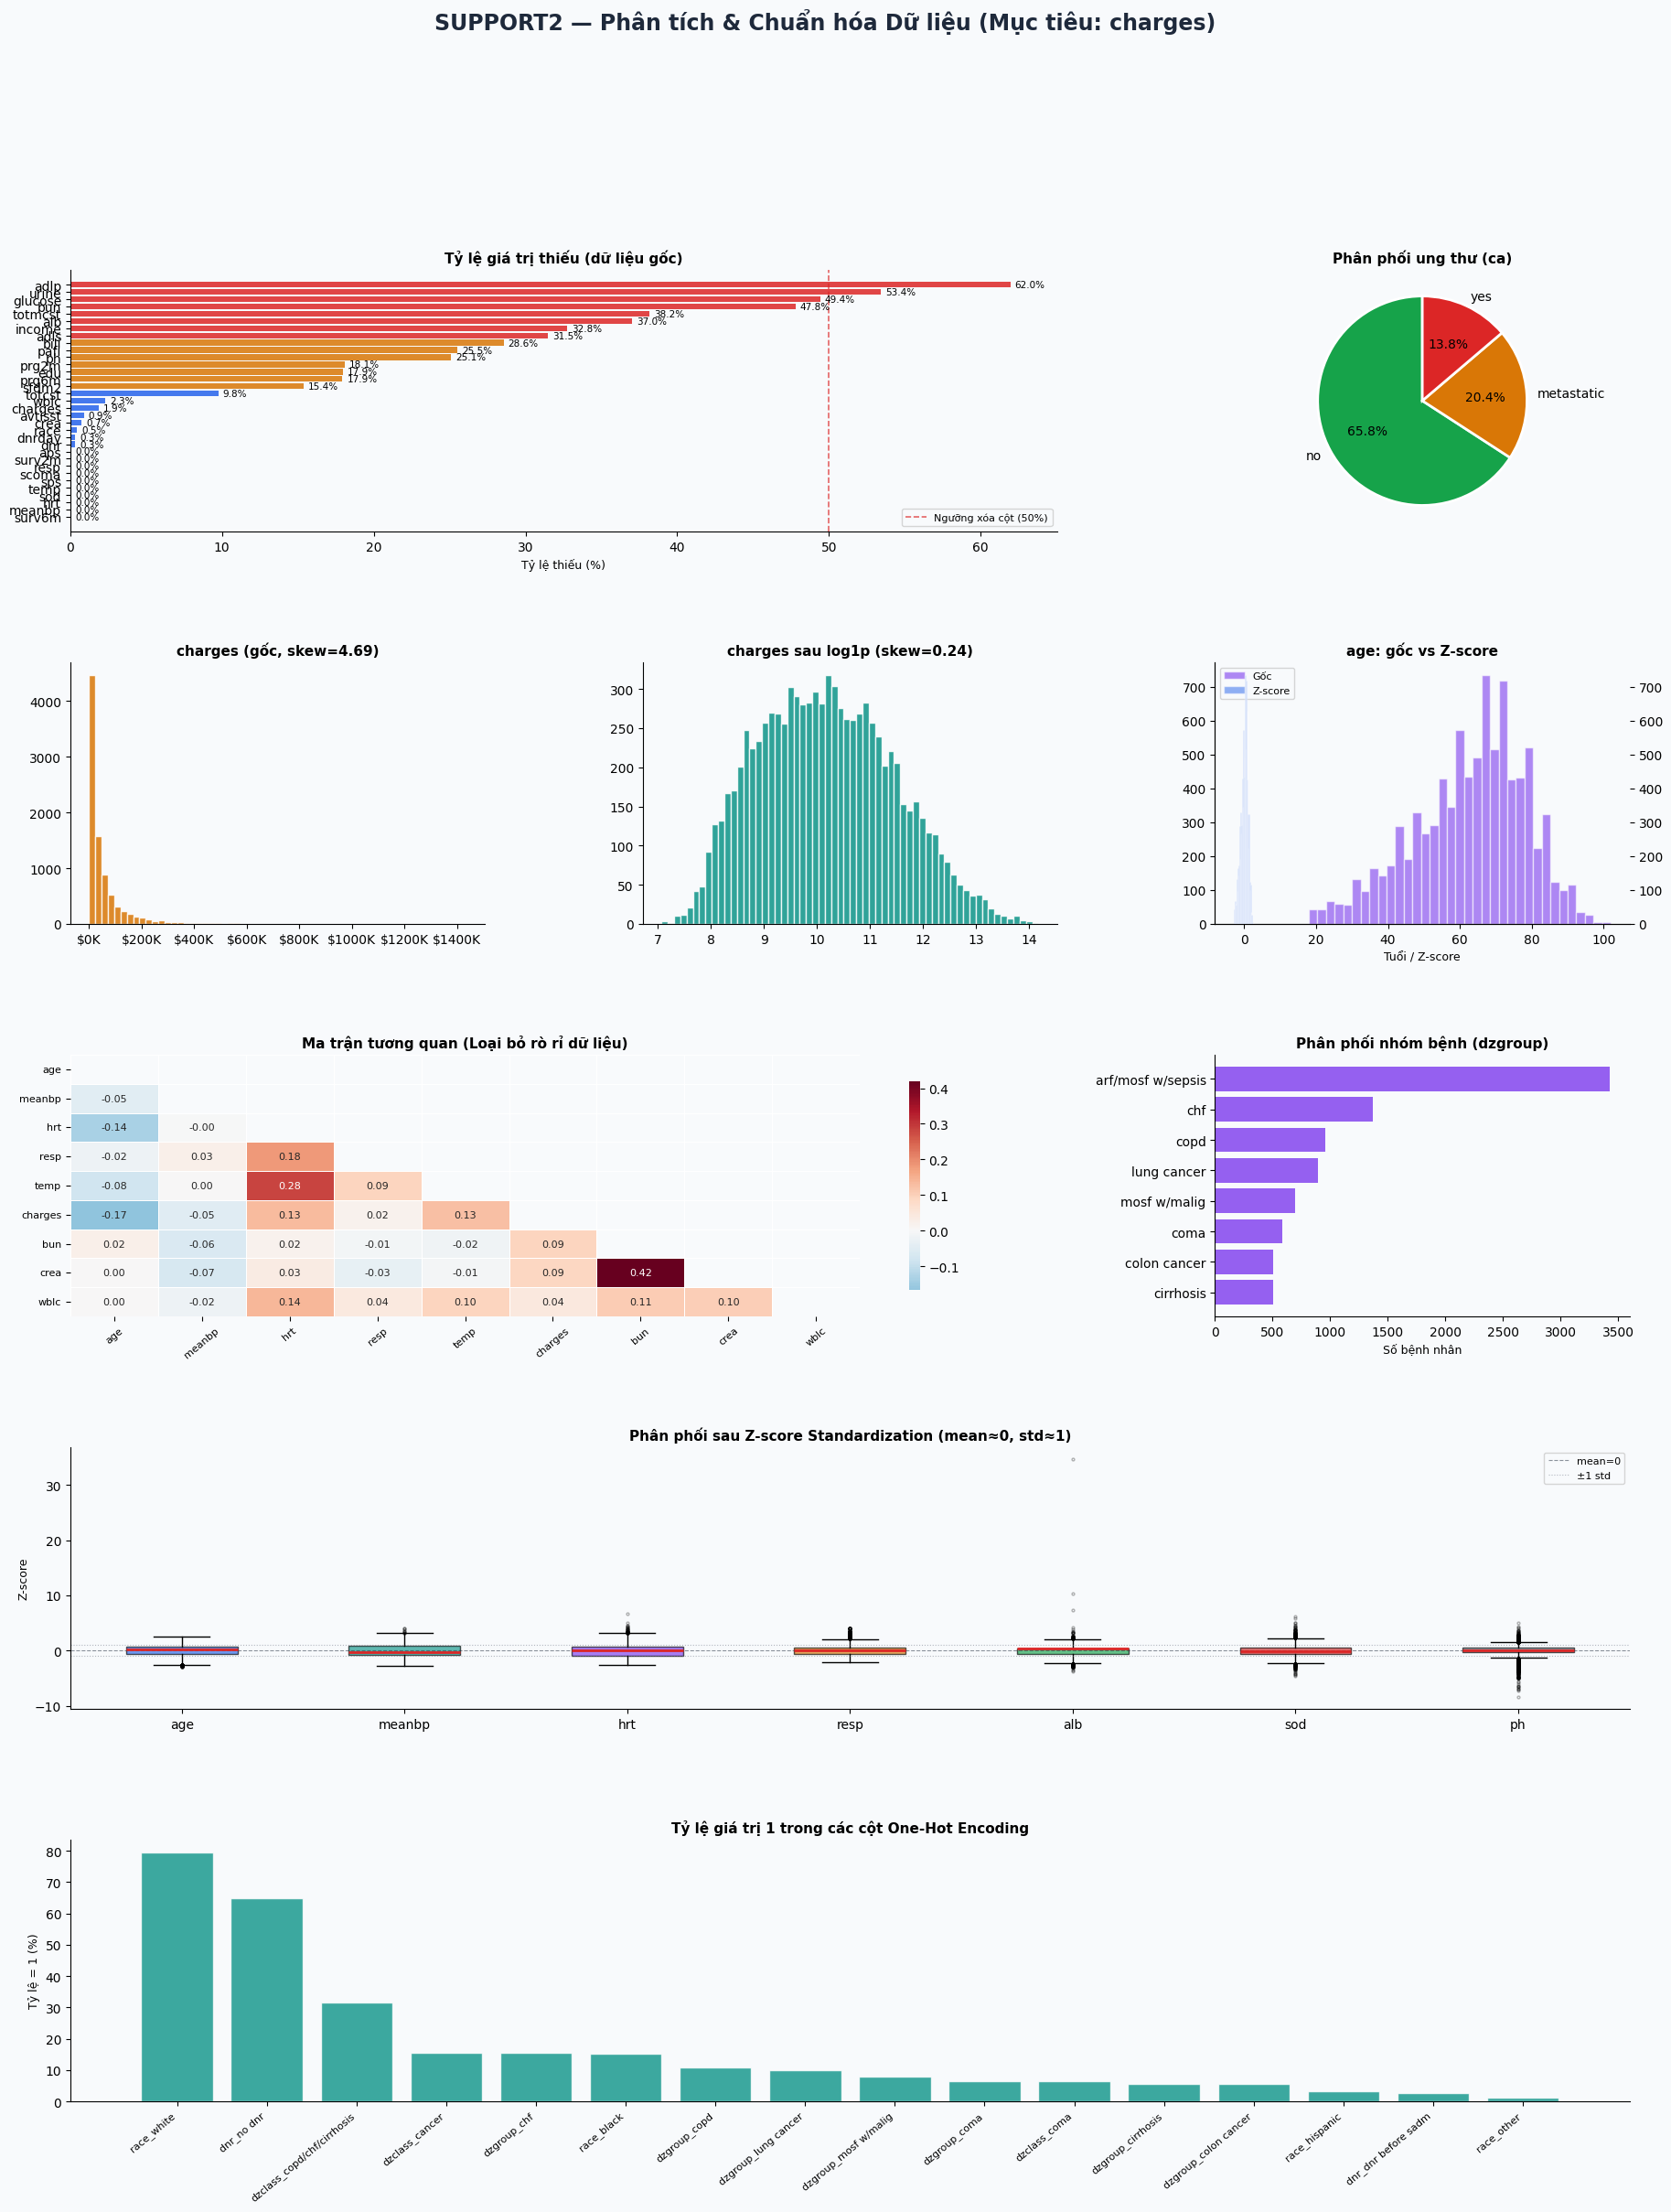

In [ ]:

fig = plt.figure(figsize=(22, 26), facecolor=C['bg'])
fig.suptitle("SUPPORT2 — Phân tích & Chuẩn hóa Dữ liệu (Mục tiêu: charges)", fontsize=17,
             fontweight='bold', color=C['dark'], y=0.99)

gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.50, wspace=0.38)

# (1) Tỷ lệ missing gốc
ax1 = fig.add_subplot(gs[0, :2])
miss = (df_raw.isna().sum() / len(df_raw) * 100).sort_values(ascending=False)
miss = miss[miss > 0]
colors_bar = [C['red'] if v > 30 else C['amber'] if v > 10 else C['blue'] for v in miss]
bars = ax1.barh(miss.index[::-1], miss.values[::-1], color=colors_bar[::-1], alpha=0.85)
ax1.axvline(50, color=C['red'], ls='--', lw=1.2, alpha=0.7, label='Ngưỡng xóa cột (50%)')
ax1.set_xlabel("Tỷ lệ thiếu (%)")
ax1.set_title("Tỷ lệ giá trị thiếu (dữ liệu gốc)", fontweight='bold')
ax1.legend(fontsize=8)
for bar, val in zip(bars, miss.values[::-1]):
    ax1.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=7.5)

# (2) Phân phối Ung thư (ca) thay vì death
ax2 = fig.add_subplot(gs[0, 2])
if 'ca' in df.columns:
    ca_vc = df['ca'].value_counts()
    ax2.pie(ca_vc, labels=ca_vc.index, colors=[C['green'], C['amber'], C['red']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':10})
    ax2.set_title("Phân phối ung thư (ca)", fontweight='bold')

# (3) Trước/Sau log transform cho charges
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
raw_ch = df_raw['charges'].dropna()
log_ch = np.log1p(raw_ch.clip(lower=0))
ax3.hist(raw_ch, bins=60, color=C['amber'], edgecolor='white', alpha=0.85)
ax3.set_title(f"charges (gốc, skew={raw_ch.skew():.2f})", fontweight='bold')
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax4.hist(log_ch, bins=60, color=C['teal'], edgecolor='white', alpha=0.85)
ax4.set_title(f"charges sau log1p (skew={log_ch.skew():.2f})", fontweight='bold')

# (4) Trước/Sau Z-score (age)
ax5 = fig.add_subplot(gs[1, 2])
age_raw = df['age'].dropna()
age_z   = (age_raw - age_raw.mean()) / age_raw.std()
ax5.hist(age_raw, bins=35, color=C['purple'], edgecolor='white', alpha=0.6, label='Gốc')
ax5_r = ax5.twinx()
ax5_r.hist(age_z, bins=35, color=C['blue'], edgecolor='white', alpha=0.5, label='Z-score')
ax5.set_title("age: gốc vs Z-score", fontweight='bold')
ax5.set_xlabel("Tuổi / Z-score")
lines1,_ = ax5.get_legend_handles_labels()
lines2,_ = ax5_r.get_legend_handles_labels()
ax5.legend(lines1+lines2, ['Gốc','Z-score'], fontsize=8, loc='upper left')

# (5) Correlation heatmap (Đã dọn dẹp các biến leakage)
ax6 = fig.add_subplot(gs[2, :2])
corr_cols = ['age','meanbp','hrt','resp','temp','charges','los','bun','crea','wblc']
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax6, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size':8}, cbar_kws={'shrink':0.8})
ax6.set_title("Ma trận tương quan (Loại bỏ rò rỉ dữ liệu)", fontweight='bold')
ax6.tick_params(axis='x', rotation=40, labelsize=8)
ax6.tick_params(axis='y', rotation=0,  labelsize=8)

# (6) Phân phối nhóm bệnh
ax7 = fig.add_subplot(gs[2, 2])
if 'dzgroup' in df.columns:
    dz = df['dzgroup'].value_counts()
    ax7.barh(dz.index[::-1], dz.values[::-1], color=C['purple'], alpha=0.8)
    ax7.set_title("Phân phối nhóm bệnh (dzgroup)", fontweight='bold')
    ax7.set_xlabel("Số bệnh nhân")

# (7) Boxplot Z-score sau scale
ax8 = fig.add_subplot(gs[3, :])
box_cols = [c for c in ['age','meanbp','hrt','resp','alb','sod','ph'] if c in df_scaled.columns]
box_data = [df_scaled[c].dropna().values for c in box_cols]
bp = ax8.boxplot(box_data, labels=box_cols, patch_artist=True,
                 medianprops={'color':C['red'],'linewidth':2},
                 flierprops={'marker':'o','markersize':2,'alpha':0.3})
palette = [C['blue'],C['teal'],C['purple'],C['amber'],C['green'],C['red'],C['gray']]
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color); patch.set_alpha(0.65)
ax8.axhline(0, color=C['dark'], ls='--', lw=0.8, alpha=0.5, label='mean=0')
ax8.axhline(1, color=C['gray'], ls=':', lw=0.8, alpha=0.5, label='±1 std')
ax8.axhline(-1,color=C['gray'], ls=':', lw=0.8, alpha=0.5)
ax8.set_title("Phân phối sau Z-score Standardization (mean≈0, std≈1)", fontweight='bold')
ax8.set_ylabel("Z-score"); ax8.legend(fontsize=8)

# (8) OHE proportion bar chart
ax9 = fig.add_subplot(gs[4, :])
ohe_pct = {c: df_scaled[c].mean()*100 for c in ohe_existing if c in df_scaled.columns}
if ohe_pct:
    ohe_series = pd.Series(ohe_pct).sort_values(ascending=False)
    ax9.bar(range(len(ohe_series)), ohe_series.values, color=C['teal'], alpha=0.8, edgecolor='white')
    ax9.set_xticks(range(len(ohe_series)))
    ax9.set_xticklabels(ohe_series.index, rotation=40, ha='right', fontsize=8)
    ax9.set_ylabel("Tỷ lệ = 1 (%)")
    ax9.set_title("Tỷ lệ giá trị 1 trong các cột One-Hot Encoding", fontweight='bold')


In [ ]:
# Xử lý lưu file ảnh an toàn 

plt.savefig(os.path.join(save_dir, 'support2_full_analysis.png'), dpi=120, bbox_inches='tight', facecolor=C['bg'])
plt.show()
print(f"\n✔ Lưu biểu đồ: support2_full_analysis.png")

# ── Lưu file ─────────────────────────────────────────────────────────
df.to_csv(os.path.join(save_dir, 'support2_cleaned.csv'), index=False)
df_enc.to_csv(os.path.join(save_dir, 'support2_encoded.csv'), index=False)
df_scaled.to_csv(os.path.join(save_dir, 'support2_final.csv'), index=False)
print(f"✔ support2_cleaned.csv  — {df.shape}")
print(f"✔ support2_encoded.csv  — {df_enc.shape}")
print(f"✔ support2_final.csv    — {df_scaled.shape}")

print(f"""
{SEP}
  QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU
{SEP}
  1. Đọc dữ liệu     : {N_ROWS:,} hàng × {N_COLS} cột gốc.
  2. Làm sạch        : - Đã xóa dòng thiếu 'charges' và xóa các cột rò rỉ dữ liệu.
                       - Xóa {n_dup} trùng lặp, chuẩn hóa categorical.
                       - Xử lý invalid range và Impute missing (y khoa + thống kê).
  3. Encoding        : Binary (sex, ca), Ordinal (income), One-Hot (race, dzgroup, dzclass).
  4. Scaling         : Log1p cho charges và {len(LOG_COLS)-1} cột lệch, Z-score cho {len(scale_params)} cột số.
  5. Kết quả cuối    : {df_scaled.shape[0]:,} hàng × {df_scaled.shape[1]} cột.
{SEP}
""")

<Figure size 640x480 with 0 Axes>


✔ Lưu biểu đồ: support2_full_analysis.png
✔ support2_cleaned.csv  — (8933, 35)
✔ support2_encoded.csv  — (8933, 47)
✔ support2_final.csv    — (8933, 47)

________________________________________________________________________
  QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU
________________________________________________________________________
  1. Đọc dữ liệu     : 9,105 hàng × 45 cột gốc.
  2. Làm sạch        : - Đã xóa dòng thiếu 'charges' và xóa các cột rò rỉ dữ liệu.
                       - Xóa 0 trùng lặp, chuẩn hóa categorical.
                       - Xử lý invalid range và Impute missing (y khoa + thống kê).
  3. Encoding        : Binary (sex, ca), Ordinal (income), One-Hot (race, dzgroup, dzclass).
  4. Scaling         : Log1p cho charges và 7 cột lệch, Z-score cho 25 cột số.
  5. Kết quả cuối    : 8,933 hàng × 47 cột.
________________________________________________________________________



## 4. Phân tích và trực quan hóa dữ liệu

### 4.1 Phân tích các tham số thống kê

### 4.2 Chuẩn hóa dữ liệu và đánh giá các thành phần chính 

### 4.3 Thực hiện hiển thị trực quan hóa đối với dữ liệu theo từng cặp 

### 4.4 Xác định lượng thông tin được bảo tồn theo phương sai, giải thích trong mỗi trường hợp 

### 4.5 Thực hiện việc trực quan hóa mối quan hệ của một số chiều dữ liệu chính với đầu ra

### 4.6 So sánh giữa các phương pháp phân tích và giảm số chiều

## 5. Phân cụm dữ liệu 

In [ ]:
df = df_scaled
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8933 entries, 0 to 8932
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         8933 non-null   float64 
 1   sex                         8933 non-null   category
 2   num.co                      8933 non-null   float64 
 3   edu                         8933 non-null   float64 
 4   income                      8933 non-null   category
 5   scoma                       8933 non-null   float64 
 6   charges                     8933 non-null   float64 
 7   avtisst                     8933 non-null   float64 
 8   sps                         8933 non-null   float64 
 9   aps                         8933 non-null   float64 
 10  hday                        8933 non-null   float64 
 11  diabetes                    8933 non-null   int64   
 12  dementia                    8933 non-null   int64   
 13  ca                

- k-mmeans

In [ ]:
# khoi tao tam cum
def kmeans_init_centers(X, k):
    return X[np.random.choice(X.shape[0], k, replace = False)]

# gan nhan cum
def kmeans_assign_labels(X, centers):
    D = cdist(X, centers)
    return np.argmin(D, axis = 1)

# cap nhat tam cum 
def kmeans_update_centers(X, labels, K):
    centers  = np.zeros((K, X.shape[1]))
    for k in range(K):
        Xk = X[labels == k, :]
        
        if Xk.shape[0] > 0:
            centers[k, :] = np.mean(Xk, axis = 0)
        else: 
            centers[k, :] = X[np.random.choice(X.shape[0])]
    return centers
    
    
# kiem tra hoi tu 
def has_converged(centers, new_centers):
    return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))

# kmeans
def kmeans(X, K):
    centers = [kmeans_init_centers(X, K)]
    labels = []
    it = 0 
    while True:
        labels.append(kmeans_assign_labels(X, centers[-1]))
        new_centers = kmeans_update_centers(X, labels[-1], K)
        if has_converged(centers[-1], new_centers):
            break
        centers.append(new_centers)
        it += 1
    return (centers, labels, it)


In [ ]:
def kmeans_display(X, label, centers):
    plt.figure(figsize=(8, 6))
    K = np.amax(label) + 1
    # Vẽ các điểm dữ liệu theo từng cụm
    for k in range(K):
        Xk = X[label == k, :]
        plt.plot(Xk[:, 0], Xk[:, 1], 'o', markersize=4, alpha=0.6, label=f'Cụm {k}')
    
    # Vẽ tâm cụm
    plt.plot(centers[:, 0], centers[:, 1], 'rX', markersize=15, markeredgecolor='k', label='Tâm cụm')
    
    plt.title(f'Kết quả phân cụm K-Means tự code (K={K})', fontweight='bold')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.savefig(os.path.join(save_dir, 'kmeans_scratch_results.png'), dpi=120)
    plt.show()

- Tìm k tối ưu
    - 1. Phương pháp Elbow
    - 2. Silhouette Score
    - 3. Davies-Bouldin Score 

In [ ]:
def evaluate_kmeans_comprehensive(X, k_min, k_max):
    k_values = list(range(k_min, k_max + 1))
    inertia_values = []
    silhouette_scores = []
    dbi_scores = []
    
    print(f"Đang tính toán 3 chỉ số cho K từ {k_min} đến {k_max}...")
    for k in k_values:
        # Chạy thuật toán K-Means
        (centers_history, labels_history, iterations) = kmeans(X, k)
        final_centers = centers_history[-1]
        final_labels = labels_history[-1]
        
        # 1. Tính Inertia
        inertia = 0
        for i in range(k):
            cluster_points = X[final_labels == i]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - final_centers[i])**2)
        inertia_values.append(inertia)
        
        # 2 & 3. Tính Silhouette và DBI (Chỉ tính khi có >1 cụm)
        if len(set(final_labels)) > 1:
            sil_score = silhouette_score(X, final_labels)
            # Dùng hàm có sẵn của sklearn cho chuẩn xác
            db_score = davies_bouldin_score(X, final_labels) 
        else:
            sil_score = -1
            db_score = np.inf
            
        silhouette_scores.append(sil_score)
        dbi_scores.append(db_score)
        
    return k_values, inertia_values, silhouette_scores, dbi_scores

In [ ]:
def plot_comprehensive_evaluation(k_values, inertias, silhouettes, dbis):
    
    # Tạo 2 biểu đồ xếp chồng lên nhau
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    
    # --- Biểu đồ 1: Inertia (Elbow) ---
    color1 = 'tab:blue'
    ax1.plot(k_values, inertias, 'o-', color=color1, linewidth=2)
    ax1.set_ylabel('Inertia (WCSS)\n(Càng thấp càng tạo thành khuỷu tay)', color=color1, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_title("1. Phương pháp Elbow (Inertia)", fontweight='bold')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # --- Biểu đồ 2: Silhouette & Davies-Bouldin ---
    color2 = 'tab:red'
    color3 = 'tab:green'
    
    # Trục trái của ax2: Silhouette
    ax2.plot(k_values, silhouettes, 's-', color=color2, linewidth=2, label='Silhouette (Càng CAO càng tốt)')
    ax2.set_ylabel('Silhouette Score', color=color2, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Trục phải của ax2: Davies-Bouldin
    ax3 = ax2.twinx()
    ax3.plot(k_values, dbis, '^-', color=color3, linewidth=2, label='Davies-Bouldin (Càng THẤP càng tốt)')
    ax3.set_ylabel('Davies-Bouldin Index', color=color3, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor=color3)
    
    ax2.set_xlabel('Số lượng cụm (K)', fontweight='bold')
    ax2.set_title("2. Đánh giá chất lượng cụm (Silhouette & DBI)", fontweight='bold')
    ax2.set_xticks(k_values)
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    # Gom chú thích
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()
    ax2.legend(lines_2 + lines_3, labels_2 + labels_3, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

    fig.tight_layout()
    plt.savefig(save_dir, dpi=120, bbox_inches='tight')
    plt.show()
    

- dbscan

In [ ]:
def dbscan_scratch(X, eps, min_samples):
    n = X.shape[0]
    labels = np.full(n, -2, dtype=int)  # -2: chưa thăm, -1: noise
    cluster_id = 0

    def region_query(idx):
        dists = np.linalg.norm(X - X[idx], axis=1)
        return list(np.where(dists <= eps)[0])

    def expand_cluster(P, neighbor_pts, C):
        labels[P] = C
        i = 0
        while i < len(neighbor_pts):
            P1 = neighbor_pts[i]
            if labels[P1] == -2:          # chưa thăm
                labels[P1] = -1           # mark visited (tạm noise)
                neighbor_pts1 = region_query(P1)
                if len(neighbor_pts1) >= min_samples:
                    neighbor_pts += neighbor_pts1   # hợp tập
            if labels[P1] < 0:            # chưa thuộc cụm nào
                labels[P1] = C
            i += 1

    for P in range(n):
        if labels[P] != -2:               # đã thăm rồi
            continue
        labels[P] = -1                    # mark visited
        neighbor_pts = region_query(P)
        if len(neighbor_pts) < min_samples:
            labels[P] = -1               # noise
        else:
            expand_cluster(P, neighbor_pts, cluster_id)
            cluster_id += 1

    # Đổi -1 thành -1 (noise), còn lại giữ nguyên cluster id
    labels[labels == -2] = -1
    return labels

- Tìm eps & min_samples optima

In [ ]:
def find_optimal_dbscan_params(X):
    n_samples, n_features = X.shape
    
    # 1. Chọn min_samples (Quy tắc 2 * số chiều)
    min_samples = 2 * n_features
    print(f" min_samples = {min_samples} (2 * {n_features} chiều)")
    
    # 2. Tính khoảng cách đến láng giềng thứ k (k = min_samples)
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors_fit = neighbors.fit(X)
    distances, indices = neighbors_fit.kneighbors(X)
    k_distances = distances[:, -1]
    k_distances = np.sort(k_distances)
    
    # 3. Tự động dò tìm "Điểm uốn" (Elbow) bằng hình học
    x_coords = np.arange(len(k_distances))
    
    p1 = np.array([x_coords[0], k_distances[0]])
    p2 = np.array([x_coords[-1], k_distances[-1]])
    
    distances_to_line = []
    for i in range(len(k_distances)):
        p3 = np.array([x_coords[i], k_distances[i]])
        dist = np.abs(np.cross(p2 - p1, p3 - p1)) / np.linalg.norm(p2 - p1)
        distances_to_line.append(dist)
        
    # Điểm có khoảng cách lớn nhất chính là điểm uốn
    optimal_idx = np.argmax(distances_to_line)
    optimal_eps = k_distances[optimal_idx]
    
    print(f"Tìm được điểm uốn tại: eps ≈ {optimal_eps:.3f}")
    
    # 4. Trực quan hóa
    plt.figure(figsize=(10, 6))
    plt.plot(x_coords, k_distances, color='tab:purple', linewidth=2, label='K-Distance Curve')
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], color='gray', linestyle='--', alpha=0.5, label='Đường chuẩn đoán')
    plt.scatter(optimal_idx, optimal_eps, color='red', s=100, zorder=5, edgecolors='black', label='Điểm uốn (Elbow)')
    plt.axhline(y=optimal_eps, color='red', linestyle=':', alpha=0.7)
    plt.axvline(x=optimal_idx, color='red', linestyle=':', alpha=0.7)

    plt.annotate(f'Eps Tối Ưu: {optimal_eps:.2f}', 
                 xy=(optimal_idx, optimal_eps), 
                 xytext=(-50, 40), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='red'),
                 color='red', fontweight='bold', fontsize=12)

    plt.title(f"K-Distance Graph tìm Eps tối ưu (min_samples = {min_samples})", fontweight='bold')
    plt.xlabel('Các điểm dữ liệu')
    plt.ylabel(f'Khoảng cách tới láng giềng thứ {min_samples}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_dir, dpi=120)
    plt.show()
    
    return optimal_eps, min_samples

### 5.1 Trên dữ liệu giảm số chiều

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from kneed import KneeLocator


In [ ]:
df = df_scaled
X = df.drop(columns=['charges']) 

# thử nhiều số chiều để giữ đủ thông tin
pca_full = PCA().fit(X)

import numpy as np
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# chọn số chiều giữ ~90% phương sai
n_components = np.argmax(cum_var >= 0.9) + 1
print("👉 Số chiều PCA:", n_components)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

print("👉 Tổng phương sai giữ lại:", sum(pca.explained_variance_ratio_))

👉 Số chiều PCA: 24
👉 Tổng phương sai giữ lại: 0.9133297856574651


In [ ]:

inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# ===== Knee detection =====
knee = KneeLocator(K_range, inertia, curve='convex', direction='decreasing')
k_opt_knee = knee.knee

print("K tối ưu theo Knee:", k_opt_knee)

K tối ưu theo Knee: 4


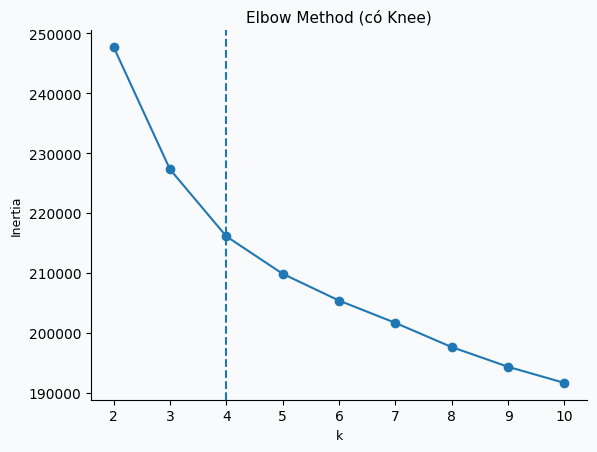

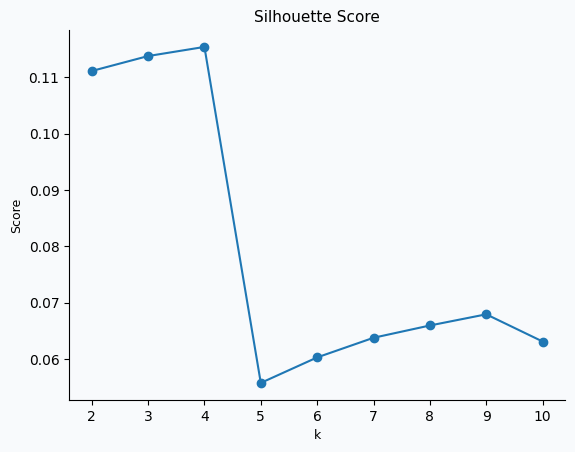

In [ ]:
plt.figure()
plt.plot(K_range, inertia, marker='o')
if k_opt_knee:
    plt.axvline(x=k_opt_knee, linestyle='--')
plt.title("Elbow Method (có Knee)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(K_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Score")
plt.show()

#### 5.1.1 K-Means

In [ ]:
k_opt = 4

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
clusters_kmeans = kmeans.fit_predict(X_pca)

df['cluster_kmeans'] = clusters_kmeans

print("Silhouette Score cuối:", silhouette_score(X_pca, clusters_kmeans))

Silhouette Score cuối: 0.12123967855847159


In [1]:
pca_nd = LDA(n_components = 2)
X_pca_nd = pca_nd.fit_transform(X_pca)

plt.figure()
plt.scatter(X_pca_nd[:, 0], X_pca_nd[:, 1], c=clusters_kmeans)
plt.title("K-Means Clustering (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


NameError: name 'LDA' is not defined

In [ ]:
df_mean = df.groupby('cluster_kmeans').mean(numeric_only=True)
important_cols = [
    'charges', 'aps', 'sps', 'avtisst', 'hday',
    'age', 'num.co',
    'crea', 'bun', 'glucose',
    'resp', 'hrt', 'temp'
]

df_mean_small = df_mean[important_cols].round(3)

print("=== BẢNG TRUNG BÌNH (CÁC BIẾN QUAN TRỌNG) ===")
print(df_mean_small)

=== BẢNG TRUNG BÌNH (CÁC BIẾN QUAN TRỌNG) ===
                charges    aps    sps  avtisst   hday    age  num.co   crea    bun  glucose   resp    hrt   temp
cluster_kmeans                                                                                                  
0                11.089  0.688  0.695    0.814  0.414 -0.260  -0.330  0.031 -0.165   -0.072  0.171  0.412  0.353
1                10.437  0.164  0.137    0.101 -0.015  0.079   0.083  1.556  1.836    0.945 -0.146  0.156 -0.026
2                 9.423 -0.619 -0.615   -0.645 -0.297  0.104   0.139 -0.285 -0.220   -0.111 -0.103 -0.331 -0.247
3                10.212  0.210  0.200    0.044 -0.032  0.226   0.275 -0.168 -0.094   -0.082  0.014 -0.029 -0.037


In [ ]:
def analyze_clusters(df_mean):
    print("\n=== NHẬN XÉT CLUSTER ===\n")
    
    # tìm cluster có charges cao/thấp nhất
    max_cluster = df_mean['charges'].idxmax()
    min_cluster = df_mean['charges'].idxmin()
    
    print(f" Cluster {max_cluster} có chi phí cao nhất")
    print(f" Cluster {min_cluster} có chi phí thấp nhất\n")
    
    for i in df_mean.index:
        print(f"--- Cluster {i} ---")
        
        charges = df_mean.loc[i, 'charges']
        aps = df_mean.loc[i, 'aps']
        sps = df_mean.loc[i, 'sps']
        hday = df_mean.loc[i, 'hday']
        
        # mức độ bệnh
        if aps > 0.5 or sps > 0.5:
            severity = "bệnh nặng"
        elif aps < -0.3 and sps < -0.3:
            severity = "bệnh nhẹ"
        else:
            severity = "mức trung bình"
        
        # thời gian nằm viện
        if hday > 0.3:
            stay = "nằm viện lâu"
        elif hday < -0.2:
            stay = "nằm viện ngắn"
        else:
            stay = "thời gian trung bình"
        
        print(f"- Chi phí (charges): {charges:.3f}")
        print(f"- Mức độ bệnh: {severity}")
        print(f"- Thời gian điều trị: {stay}")
        
        # insight đặc biệt
        if df_mean.loc[i, 'crea'] > 1 or df_mean.loc[i, 'bun'] > 1:
            print(" Có dấu hiệu suy thận (creatinine/bun cao)")
        
        if df_mean.loc[i, 'resp'] > 0.3:
            print(" Có vấn đề hô hấp (resp cao)")
        
        if df_mean.loc[i, 'dementia'] > 0.2:
            print(" Tỷ lệ sa sút trí tuệ cao")
        
        print()

In [ ]:
analyze_clusters(df_mean)


=== NHẬN XÉT CLUSTER ===

 Cluster 0 có chi phí cao nhất
 Cluster 2 có chi phí thấp nhất

--- Cluster 0 ---
- Chi phí (charges): 11.089
- Mức độ bệnh: bệnh nặng
- Thời gian điều trị: nằm viện lâu

--- Cluster 1 ---
- Chi phí (charges): 10.437
- Mức độ bệnh: mức trung bình
- Thời gian điều trị: thời gian trung bình
 Có dấu hiệu suy thận (creatinine/bun cao)

--- Cluster 2 ---
- Chi phí (charges): 9.423
- Mức độ bệnh: bệnh nhẹ
- Thời gian điều trị: nằm viện ngắn

--- Cluster 3 ---
- Chi phí (charges): 10.212
- Mức độ bệnh: mức trung bình
- Thời gian điều trị: thời gian trung bình



#### 5.1.2 DBSCAN

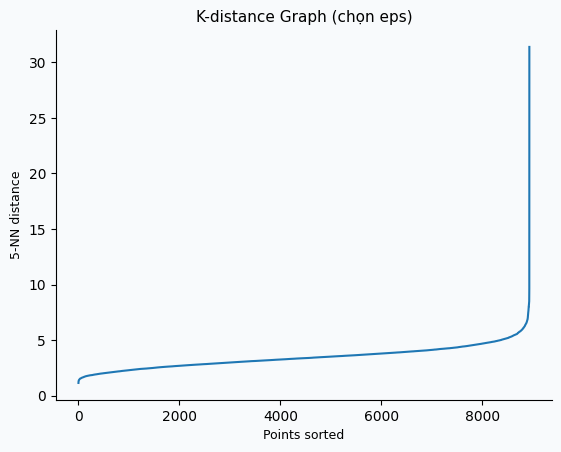

In [ ]:
# k = min_samples (thường 4–6)
k = 5
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_pca)

distances, _ = neighbors_fit.kneighbors(X_pca)

# lấy khoảng cách k-th neighbor
distances = np.sort(distances[:, k-1])

plt.figure()
plt.plot(distances)
plt.title("K-distance Graph (chọn eps)")
plt.xlabel("Points sorted")
plt.ylabel(f"{k}-NN distance")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# chỉnh eps theo graph (ví dụ 1.5 → bạn thay lại)
dbscan = DBSCAN(eps=0.45, min_samples=4)

clusters_dbscan = dbscan.fit_predict(X_pca)

df['cluster_dbscan'] = clusters_dbscan

# số cụm (không tính noise -1)
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)

print(" Số cụm (DBSCAN):", n_clusters)
print(" Số điểm noise:", list(clusters_dbscan).count(-1))

 Số cụm (DBSCAN): 0
 Số điểm noise: 8933


In [ ]:
df_dbscan_mean = df[df['cluster_dbscan'] != -1] \
    .groupby('cluster_dbscan') \
    .mean(numeric_only=True)

important_cols = [
    'charges', 'aps', 'sps', 'avtisst', 'hday',
    'crea', 'bun', 'glucose', 'resp', 'hrt'
]

df_dbscan_small = df_dbscan_mean[important_cols].round(3)

print("=== BẢNG DBSCAN (BIẾN QUAN TRỌNG) ===")
print(df_dbscan_small)

=== BẢNG DBSCAN (BIẾN QUAN TRỌNG) ===
                charges    aps    sps  avtisst   hday   crea    bun  glucose   resp    hrt
cluster_dbscan                                                                            
0                10.056 -0.077 -0.078   -0.089 -0.109 -0.131 -0.124   -0.101 -0.010 -0.064
1                 8.846 -0.496 -0.491   -0.898 -0.371  3.205  1.960   -0.667 -0.350 -0.691
2                10.967  1.137  1.172    1.442 -0.371 -0.140  1.309   -0.384  0.437  0.480


In [ ]:
def analyze_dbscan(df_mean):
    print("\n=== NHẬN XÉT DBSCAN ===\n")
    
    if df_mean.empty:
        print(" Không có cụm rõ ràng (DBSCAN coi hầu hết là noise)")
        return
    
    max_cluster = df_mean['charges'].idxmax()
    min_cluster = df_mean['charges'].idxmin()
    
    print(f"Cụm chi phí cao nhất: Cluster {max_cluster}")
    print(f"Cụm chi phí thấp nhất: Cluster {min_cluster}\n")
    
    for i in df_mean.index:
        print(f"--- Cluster {i} ---")
        row = df_mean.loc[i]
        
        print(f"  charges : {row['charges']:.3f}")
        print(f"  aps     : {row['aps']:.3f}")
        print(f"  sps     : {row['sps']:.3f}")
        print(f"  hday    : {row['hday']:.3f}")
        
        if row['crea'] > 1 or row['bun'] > 1:
            print("   Dấu hiệu suy thận")
        
        if row['resp'] > 0.3:
            print("   Vấn đề hô hấp")
        
        print()

In [ ]:
analyze_dbscan(df_dbscan_small)


=== NHẬN XÉT DBSCAN ===

Cụm chi phí cao nhất: Cluster 2
Cụm chi phí thấp nhất: Cluster 1

--- Cluster 0 ---
  charges : 10.056
  aps     : -0.077
  sps     : -0.078
  hday    : -0.109

--- Cluster 1 ---
  charges : 8.846
  aps     : -0.496
  sps     : -0.491
  hday    : -0.371
   Dấu hiệu suy thận

--- Cluster 2 ---
  charges : 10.967
  aps     : 1.137
  sps     : 1.172
  hday    : -0.371
   Dấu hiệu suy thận
   Vấn đề hô hấp



### 5.2 Trên dữ liệu đã giảm chiều

#### 5.2.1 Domain grouping
severity (scoma, aps, sps)
vitals (bp, hr, resp, temp)
lab (bun, crea, alb, bili)
comorbidity (diabetes, dementia)

#### 5.2.2 Correlation filtering trong từng nhóm

#### 5.2.3 PCA loading analysis

In [ ]:
explained_var_cumsum = pca_full.explained_variance_ratio_.cumsum()
n_components_90 = np.argmax(explained_var_cumsum >= 0.90) + 1
X_pca_90 = pca_full.transform(X_final)[:, :n_components_90]

print(f"Số chiều cho PCA >= 90% phương sai: {n_components_90}")

#### 5.2.4 Clustering

#### 5.2.5 So sánh mô hình

### 5.3 Tổng kết

Sau clustering, mày phải quay về dữ liệu gốc (charges)
Step 1: gắn label cluster vào data gốc
Step 2: phân tích charges theo cluster

gif, sten,  ummap

## 6. Phân tích hồi quy 

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import pearsonr

In [3]:
df = pd.read_csv("../data/support2_final_1.csv")

# Thiết lập giao diện
sns.set_theme(style="whitegrid")
pastel_palette = sns.color_palette("pastel")

In [4]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    if random_state is not None:
        np.random.seed(random_state)
    indices = np.random.permutation(len(X))
    test_samples = int(len(X) * test_size)
    
    test_idx, train_idx = indices[:test_samples], indices[test_samples:]
    if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series):
        return X.iloc[train_idx].values, X.iloc[test_idx].values, y.iloc[train_idx].values, y.iloc[test_idx].values
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

In [5]:
def mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


In [ ]:
# ==========================================
# TRIỂN KHAI CÁC MÔ HÌNH HỒI QUY
# ==========================================

# KNNRegressor
class CustomKNNRegressor:
    def __init__(self, n_neighbors=5):
        self.k = n_neighbors

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        return self

    def predict(self, X_test):
        # Vectorized: tính toàn bộ distance matrix 1 lần
        # ||a-b||² = ||a||² + ||b||² - 2a·b
        X_test_sq  = np.sum(X_test ** 2, axis=1, keepdims=True)   
        X_train_sq = np.sum(self.X_train ** 2, axis=1, keepdims=True)  
        cross      = X_test @ self.X_train.T

        dist_matrix = np.sqrt(np.maximum(X_test_sq + X_train_sq.T - 2 * cross, 0))
        # shape: (n_test, n_train)

        k = min(self.k, len(self.X_train))
        # Lấy k chỉ số nhỏ nhất mỗi hàng
        nearest_indices = np.argpartition(dist_matrix, k, axis=1)[:, :k]

        # Tính mean của k láng giềng
        y_pred = np.mean(self.y_train[nearest_indices], axis=1)

        return y_pred

In [ ]:
# LinearRegression
class CustomLinearRegression:
    def __init__(self):
        self.theta = None

    def fit(self, X_train, y_train):
        y_train = y_train.reshape(-1) # đảm bảo y là một chiều 

        # Thêm bias (cột 1)
        X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train] # để học được bias 0

        # Normal Equation
        self.theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y_train # công thức này tính nghiệm min mse

        return self

    def predict(self, X_test):
        X_b = np.c_[np.ones((X_test.shape[0], 1)), X_test] # theemm bias 
        return X_b @ self.theta # nhan a với thetaa để dự báo 

In [ ]:
# RidgeRegression
class CustomRidgeRegression:
    def __init__(self, alpha=1.0):
        self.alpha = alpha # Thành phần Regularization L2: ép các hệ số co lại 

    def fit(self, X_train, y_train):
        X_b = np.c_[np.ones((X_train.shape[0], 1)), X_train] # thêm cột bias
        I = np.eye(X_b.shape[1]) # tạo ma trận đơn vị 1
        I[0, 0] = 0 # không regularize bias 
        self.theta = np.linalg.pinv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y_train
        return self

    def predict(self, X_test):
        X_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
        return X_b @ self.theta

In [9]:
class CustomMLPRegressor:
    def __init__(self, hidden_size=32, learning_rate=0.01, epochs=500,
                 lambda_reg=0.0, batch_size=32, early_stopping=False, patience=20):
        self.hidden_size = hidden_size
        self.lr = learning_rate
        self.epochs = epochs
        self.lambda_reg = lambda_reg
        self.batch_size = batch_size
        self.early_stopping = early_stopping
        self.patience = patience

        self.loss_history = []
        self.val_loss_history = []
        
        self.W1, self.b1, self.W2, self.b2 = None, None, None, None

    def _init_params(self, n_features):
        np.random.seed(42)
        # He Initialization cho ReLU
        self.W1 = np.random.randn(n_features, self.hidden_size) * np.sqrt(2. / n_features)
        self.b1 = np.zeros((1, self.hidden_size)) 
        self.W2 = np.random.randn(self.hidden_size, 1) * np.sqrt(2. / self.hidden_size)
        self.b2 = np.zeros((1, 1))

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        y_train = y_train.reshape(-1, 1)
        if y_val is not None:
            y_val = y_val.reshape(-1, 1)
            
        N, d = X_train.shape
        self._init_params(d)
        
        best_val = np.inf
        best_weights = (self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy())
        wait = 0

        # Nếu batch_size không truyền vào, mặc định lấy Mini-batch 32 (không dùng Full-batch)
        bs = self.batch_size if self.batch_size is not None else 32

        for epoch in range(self.epochs):
            # Xáo trộn dữ liệu mỗi epoch cho Mini-batch SGD chuẩn
            idx = np.random.permutation(N)
            X_shuf, y_shuf = X_train[idx], y_train[idx]
            
            batches = [(X_shuf[i:i+bs], y_shuf[i:i+bs]) for i in range(0, N, bs)]

            epoch_loss = 0
            
            for Xb, yb in batches:
                m = Xb.shape[0]
                
                # ==========================================
                # 1. FORWARD PASS
                # ==========================================
                Z1 = Xb.dot(self.W1) + self.b1
                A1 = np.maximum(Z1, 0)         # ReLU
                Z2 = A1.dot(self.W2) + self.b2
                Yhat = Z2                      # Linear Output

                # ==========================================
                # 2. BACKWARD PASS (Đã fix chuẩn Scale)
                # ==========================================
                E2 = (Yhat - yb) / m
                
                # Fix: L2 penalty scale theo N để không nuốt chửng gradient của data
                l2_term_W2 = (self.lambda_reg / N) * self.W2
                dW2 = A1.T.dot(E2) + l2_term_W2
                db2 = np.sum(E2, axis=0, keepdims=True)
                
                E1 = E2.dot(self.W2.T)
                E1[Z1 <= 0] = 0                # Gradient of ReLU
                
                l2_term_W1 = (self.lambda_reg / N) * self.W1
                dW1 = Xb.T.dot(E1) + l2_term_W1
                db1 = np.sum(E1, axis=0, keepdims=True)

                # ==========================================
                # 3. UPDATE WEIGHTS
                # ==========================================
                self.W1 -= self.lr * dW1
                self.b1 -= self.lr * db1
                self.W2 -= self.lr * dW2
                self.b2 -= self.lr * db2
                
                batch_loss = 0.5 * np.mean((Yhat - yb)**2) + \
                             0.5 * (self.lambda_reg / N) * (np.sum(self.W1**2) + np.sum(self.W2**2))
                epoch_loss += batch_loss * m

            self.loss_history.append(epoch_loss / N)

            # --- Validation & Early Stopping ---
            if X_val is not None and y_val is not None:
                Z1_v = X_val.dot(self.W1) + self.b1
                A1_v = np.maximum(Z1_v, 0)
                Yhat_v = A1_v.dot(self.W2) + self.b2
                
                val_loss = 0.5 * np.mean((Yhat_v - y_val)**2)
                self.val_loss_history.append(val_loss)

                if self.early_stopping:
                    if val_loss < best_val - 1e-7:
                        best_val = val_loss
                        best_weights = (self.W1.copy(), self.b1.copy(), self.W2.copy(), self.b2.copy())
                        wait = 0
                    else:
                        wait += 1
                        if wait >= self.patience:
                            self.W1, self.b1, self.W2, self.b2 = best_weights
                            break
        return self

    def predict(self, X_test):
        Z1 = X_test.dot(self.W1) + self.b1
        A1 = np.maximum(Z1, 0)
        Z2 = A1.dot(self.W2) + self.b2
        return Z2.flatten()

In [10]:
# plot metrics base
def plot_metrics_bar(metrics_base, title="So sánh RMSE, MAE và R²"):
    df_metrics = pd.DataFrame(metrics_base)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Hàm gắn label
    def add_bar_labels(ax):
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3,
                         color="#000000", fontsize=10, fontweight='bold')

    # Vẽ từng biểu đồ
    sns.barplot(x='Tỷ lệ', y='RMSE', data=df_metrics, ax=axes[0], color='skyblue')
    axes[0].set_title('RMSE')
    add_bar_labels(axes[0])

    sns.barplot(x='Tỷ lệ', y='MAE', data=df_metrics, ax=axes[1], color='lightgreen')
    axes[1].set_title('MAE')
    add_bar_labels(axes[1])

    sns.barplot(x='Tỷ lệ', y='R2', data=df_metrics, ax=axes[2], color='salmon')
    axes[2].set_title('R² Score ')
    add_bar_labels(axes[2])

    for ax in axes:
        ax.set_xlabel('')

    plt.tight_layout()
    plt.show()

In [11]:
# đánh giá mô hình
def evaluate_splits(X, y, test_sizes, labels, model_class, model_kwargs=None, sep = SEP):
    if model_kwargs is None:
        model_kwargs = {}

    metrics_base = []
    predictions_data = []

    print("Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score")
    print(sep)

    for test_size, label in zip(test_sizes, labels):
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mae  = mean_absolute_error(y_test, y_pred)
        r2   = r2_score(y_test, y_pred)

        metrics_base.append({'Tỷ lệ': label, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
        
        predictions_data.append({
            'label': label,
            'y_val': y_test,  
            'y_pred': y_pred
        })
        
        print(f"{label:<16} | {len(X_train):>10,d} | {len(X_test):>10,d} "
              f"| {rmse:>8.4f} | {mae:>8.4f} | {r2:>8.4f}")

    print(sep)
    return metrics_base, predictions_data

In [12]:
# ==========================================
# PHẦN 4: SCATTER PLOT - THỰC TẾ VS DỰ ĐOÁN
# ==========================================
def plot_actual_vs_predicted(best_models_data,
                            main_title="Scatter Plot: Thực tế vs Dự đoán",
                            palette_color='steelblue'):
    n = len(best_models_data)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    fig.suptitle(main_title, fontsize=14, fontweight='bold')

    # Nếu chỉ có 1 plot thì axes không phải list
    if n == 1:
        axes = [axes]

    for i, model_data in enumerate(best_models_data):
        ax = axes[i]
        y_actual = model_data['y_val']
        y_predicted = model_data['y_pred']

        # Scatter
        sns.scatterplot(x=y_actual, y=y_predicted,
                        ax=ax, color=palette_color, alpha=0.6)

        # Đường y = x
        min_val = min(y_actual.min(), y_predicted.min())
        max_val = max(y_actual.max(), y_predicted.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                color='red', linestyle='--', linewidth=1.5,
                label='Hoàn hảo (y=x)')

        # Tự động build subtitle dựa trên key có trong model_data
        if 'best_k' in model_data:
            subtitle = f"K tối ưu = {model_data['best_k']}"
        elif 'best_alpha' in model_data:
            subtitle = f"Alpha tối ưu = {model_data['best_alpha']}"
        else:
            subtitle = ""  # LinearRegression không có tham số

        title = f"{model_data['label']} - {subtitle}" if subtitle else model_data['label']
        ax.set_title(title, fontsize=12)
        
        ax.set_xlabel('Thực tế (y)')
        ax.set_ylabel('Dự đoán ($\\hat{y}$)')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [13]:
# ==========================================
# PHẦN 5: TRỰC QUAN HÓA VÀ ĐÁNH GIÁ PHẦN DƯ (RESIDUAL PLOT)
# ==========================================
def plot_residuals(best_models_data,
                   main_title="Residual Plot: Đánh giá phần dư và Tương quan",
                   palette_color='pastel'):
    
    n = len(best_models_data)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    fig.suptitle(main_title, fontsize=14, fontweight='bold')

    # Trường hợp chỉ có 1 plot
    if n == 1:
        axes = [axes]

    for i, model_data in enumerate(best_models_data):
        ax = axes[i]

        # Ép dẹp thành mảng 1 chiều (1D) để hàm pearsonr không bị lỗi
        y_actual = np.array(model_data['y_val']).flatten()
        y_predicted = np.array(model_data['y_pred']).flatten()

        # Tính residual (Phần dư = Thực tế - Dự đoán)
        residuals = y_actual - y_predicted

        # TÍNH HỆ SỐ TƯƠNG QUAN PEARSON
        # Trả về 2 giá trị: hệ số tương quan (corr) và p-value (bỏ qua p-value bằng dấu _)
        corr, _ = pearsonr(y_predicted, residuals)

        # Scatter plot
        sns.scatterplot(x=y_predicted, y=residuals,
                        ax=ax, color=palette_color, alpha=0.6)

        # Đường y = 0
        ax.axhline(y=0, color='red', linestyle='--', linewidth=2,
                   label='Sai số = 0')

        # Tự động build subtitle dựa trên key có trong model_data
        if 'best_k' in model_data:
            subtitle = f"K tối ưu = {model_data['best_k']}"
        elif 'best_alpha' in model_data:
            subtitle = f"Alpha tối ưu = {model_data['best_alpha']}"
        else:
            subtitle = ""  

        # Chèn Hệ số Pearson vào tiêu đề của từng đồ thị
        pearson_text = f"Pearson r = {corr:.4f}"
        
        if subtitle:
            title = f"{model_data['label']}\n{subtitle}\n{pearson_text}"
        else:
            title = f"{model_data['label']}\n{pearson_text}"
            
        ax.set_title(title, fontsize=12)
        
        ax.set_xlabel('Chi phí Dự đoán ($\hat{y}$) - Đại diện Đầu vào')
        ax.set_ylabel('Phần dư ($y - \hat{y}$)')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [14]:
# ==========================================
# Đánh giá overfitting
# ==========================================
def analyze_overfitting(best_models_data, model_name="Model", threshold=0.1):
    print("=" * 80)
    print(f"OVERFITTING ANALYSIS - {model_name}")
    print("=" * 80)
    
    if model_name.upper() == "KNN":
        param_label = "K"
        param_key = "best_k"
    else:
        param_label = "Alpha"
        param_key = "best_alpha"
    
    print(f"{param_label:} | {'Tỉ lệ':<16} | {'R2 Train':>10} | {'R2 Val':>10} | {'ΔR2':>8} | "
          f"{'RMSE Train':>12} | {'RMSE Val':>10} | {'ΔRMSE':>8} | {'MAE val':>8} | Kết luận")
    print("-" * 80)

    labels, delta_r2_list, delta_rmse_list = [], [], []
    r2_train_list, r2_val_list = [], []

    for m in best_models_data:
        delta_r2 = m['R2_train'] - m['R2']
        delta_rmse = m['RMSE'] - m['RMSE_train']

        labels.append(m['label'])
        delta_r2_list.append(delta_r2)
        delta_rmse_list.append(delta_rmse)
        r2_train_list.append(m['R2_train'])
        r2_val_list.append(m['R2'])

        if delta_r2 > 0.2 or delta_rmse > 0.2:
            verdict = "Overfit nặng"
        elif delta_r2 > threshold or delta_rmse > threshold:
            verdict = "Overfit nhẹ"
        else:
            verdict = "Ổn định"

        print(f"{m[param_key]} | {m['label']:<16} | {m['R2_train']:>10.4f} | {m['R2']:>10.4f} | "
              f"{delta_r2:>+8.4f} | {m['RMSE_train']:>12.4f} | {m['RMSE']:>10.4f} | "
              f"{delta_rmse:>+8.4f} | {m['MAE']:>10.4f} | {verdict}")

    print("-" * 80)

    # --- PHẦN PLOT ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    x = np.arange(len(labels))

    # Plot 1: R2 Train vs Val
    axes[0].bar(x - 0.2, r2_train_list, width=0.4, label="Train R2", color='skyblue')
    axes[0].bar(x + 0.2, r2_val_list, width=0.4, label="Val R2", color='orange')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=45)
    axes[0].set_ylabel("R2 Score")
    axes[0].set_title("Train vs Val R2")
    axes[0].legend()

    # Plot 2: Delta R2
    axes[1].bar(labels, delta_r2_list, color='salmon')
    axes[1].axhline(threshold, color='red', linestyle="--", label=f"Ngưỡng {threshold}")
    axes[1].axhline(0.2, color='darkred', linestyle="--", label="Overfit nặng")
    axes[1].set_xticklabels(labels, rotation=45)
    axes[1].set_ylabel("ΔR2 (Train - Val)")
    axes[1].set_title("Overfitting Gap (R2)")
    axes[1].legend()

    # Plot 3: Delta RMSE
    axes[2].bar(labels, delta_rmse_list, color='lightgreen')
    axes[2].axhline(threshold, color='red', linestyle="--")
    axes[2].axhline(0.2, color='darkred', linestyle="--")
    axes[2].set_xticklabels(labels, rotation=45)
    axes[2].set_ylabel("ΔRMSE (Val - Train)")
    axes[2].set_title("Overfitting Gap (RMSE)")

    plt.tight_layout()
    plt.show()

### 6.1 Dữ liệu gốc

In [15]:
# ==========================================
# KHỞI TẠO DỮ LIỆU & PIPELINE (Giả định X, y đã có)
# ==========================================
X = df.drop(columns=['charges']).values
y = df['charges'].values


test_sizes = [0.2, 0.3, 0.4]
labels = ['Train 80%', 'Train 70%', 'Train 60%']

models = {
    'K-NN': CustomKNNRegressor(n_neighbors=5),
    'Linear Regression': CustomLinearRegression(),
    'MLP': CustomMLPRegressor(hidden_size=32, learning_rate=0.01, epochs=300)
}

# Lưu trữ kết quả
results_list = []
prediction_data = []

In [16]:

def plot_residuals(best_models_data,
                   main_title="Phân tích Phần dư (Residuals) vs Đầu vào",
                   palette_color='seagreen'):
    n = len(best_models_data)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    fig.suptitle(main_title, fontsize=14, fontweight='bold')

    # Nếu chỉ có 1 plot thì axes không phải list
    if n == 1:
        axes = [axes]

    for i, model_data in enumerate(best_models_data):
        ax = axes[i]
        
        # Ép dẹp thành mảng 1D để tránh lỗi kích thước khi tính Pearson
        y_actual = np.array(model_data['y_val']).flatten()
        y_predicted = np.array(model_data['y_pred']).flatten()

        # 1. TÍNH PHẦN DƯ (Thực tế - Dự đoán)
        residuals = y_actual - y_predicted

        # 2. TÍNH HỆ SỐ TƯƠNG QUAN PEARSON
        corr, _ = pearsonr(y_predicted, residuals)

        # 3. VẼ SCATTER PLOT (X: Dự đoán, Y: Phần dư)
        sns.scatterplot(x=y_predicted, y=residuals,
                        ax=ax, color=palette_color, alpha=0.6)

        # Vẽ đường ngang y = 0 làm mốc chuẩn (Sai số bằng 0)
        ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Hoàn hảo (Sai số = 0)')

        # Tự động build subtitle
        if 'best_k' in model_data:
            subtitle = f"K tối ưu = {model_data['best_k']}"
        elif 'best_alpha' in model_data:
            subtitle = f"Alpha tối ưu = {model_data['best_alpha']}"
        else:
            subtitle = ""  # Các mô hình không có siêu tham số

        # Chèn thẳng hệ số Pearson vào tiêu đề của từng hình
        title = f"{model_data['label']}\n{subtitle}\nPearson r = {corr:.4f}"
        ax.set_title(title, fontsize=12)
        
        ax.set_xlabel('Dự đoán ($\hat{y}$) - Đại diện cho Đầu vào')
        ax.set_ylabel('Phần dư ($y - \hat{y}$)')
        ax.legend()

    plt.tight_layout()
    plt.show()

#### 6.1.1 K-NN

In [17]:
# ==========================================
# PHẦN 3: ĐÁNH GIÁ REGULARIZATION TRÊN CẢ 3 TỈ LỆ 
# ==========================================
def plot_knn_regularization(X, y, test_sizes, labels,
                           k_values=[2, 3, 5, 9, 15, 20],
                           elbow_threshold=0.01,
                           main_title="Tác động của K đến hiệu suất KNN"):

    metrics_names = ['RMSE', 'MAE', 'R2']

    fig, axes = plt.subplots(len(test_sizes), 3, figsize=(17, 5 * len(test_sizes)))
    fig.suptitle(main_title, fontsize=16, fontweight='bold')
    axes = np.array(axes).reshape(len(test_sizes), 3)

    best_models_data = []

    def find_best_k(k_values, val_r2, threshold=0.01):
        for i in range(1, len(val_r2)):
            gain = val_r2[i] - val_r2[i-1]
            if gain < threshold:
                return i-1, k_values[i-1]
        return len(val_r2)-1, k_values[-1]

    for row_idx, (test_size, label) in enumerate(zip(test_sizes, labels)):
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        train_metrics = {m: [] for m in metrics_names}
        val_metrics   = {m: [] for m in metrics_names}

        for k in k_values:
            knn = CustomKNNRegressor(n_neighbors=k)
            knn.fit(X_train, y_train)

            y_train_pred = knn.predict(X_train)
            y_val_pred   = knn.predict(X_val)

            train_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
            train_metrics['MAE'].append(mean_absolute_error(y_train, y_train_pred))
            train_metrics['R2'].append(r2_score(y_train, y_train_pred))

            val_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
            val_metrics['MAE'].append(mean_absolute_error(y_val, y_val_pred))
            val_metrics['R2'].append(r2_score(y_val, y_val_pred))

        # Chọn K tại điểm elbow thay vì max đơn thuần
        best_idx, best_k = find_best_k(k_values, val_metrics['R2'], elbow_threshold)

        # In để kiểm tra
        print(f"\n{label}:")
        print(f"{'K':<6} {'R2_train':>10} {'R2_val':>10} {'Gain':>8}")
        for i, k in enumerate(k_values):
            gain = val_metrics['R2'][i] - val_metrics['R2'][i-1] if i > 0 else 0
            marker = " ← elbow" if k == best_k else ""
            print(f"{k:<6} {train_metrics['R2'][i]:>10.4f} {val_metrics['R2'][i]:>10.4f} {gain:>+8.4f}{marker}")
        print(f"→ best_k={best_k} (gain tiếp theo < {elbow_threshold})")

        best_knn = CustomKNNRegressor(n_neighbors=best_k).fit(X_train, y_train)
        best_models_data.append({
            'k': best_k,
            'label':      label,
            'best_k':     best_k,
            'y_val':      y_val,
            'y_pred':     best_knn.predict(X_val),
            'RMSE':       val_metrics['RMSE'][best_idx],
            'MAE':        val_metrics['MAE'][best_idx],
            'R2':         val_metrics['R2'][best_idx],
            'RMSE_train': train_metrics['RMSE'][best_idx],
            'MAE_train':  train_metrics['MAE'][best_idx],
            'R2_train':   train_metrics['R2'][best_idx]
        })

        for col_idx, metric in enumerate(metrics_names):
            ax = axes[row_idx, col_idx]

            ax.plot(k_values, train_metrics[metric],
                    marker='o', label='Train', linewidth=2)
            ax.plot(k_values, val_metrics[metric],
                    marker='s', label='Validation', linewidth=2)
            ax.axvline(best_k, color='gray', linestyle='--',
                       label=f'K tối ưu ({best_k})')

            all_vals = train_metrics[metric] + val_metrics[metric]
            ax.set_ylim(min(all_vals) * 0.95, max(all_vals) * 1.05)

            if row_idx == 0:
                ax.set_title(f'{metric}', fontsize=12)
            if col_idx == 0:
                ax.set_ylabel(label, fontweight='bold')

            ax.set_xlabel('K')
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return best_models_data

Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.8860 |   0.6127 |   0.6160
Train 70%        |      6,254 |      2,679 |   0.8924 |   0.6220 |   0.6062
Train 60%        |      5,360 |      3,573 |   0.8939 |   0.6273 |   0.6057
________________________________________________________________________


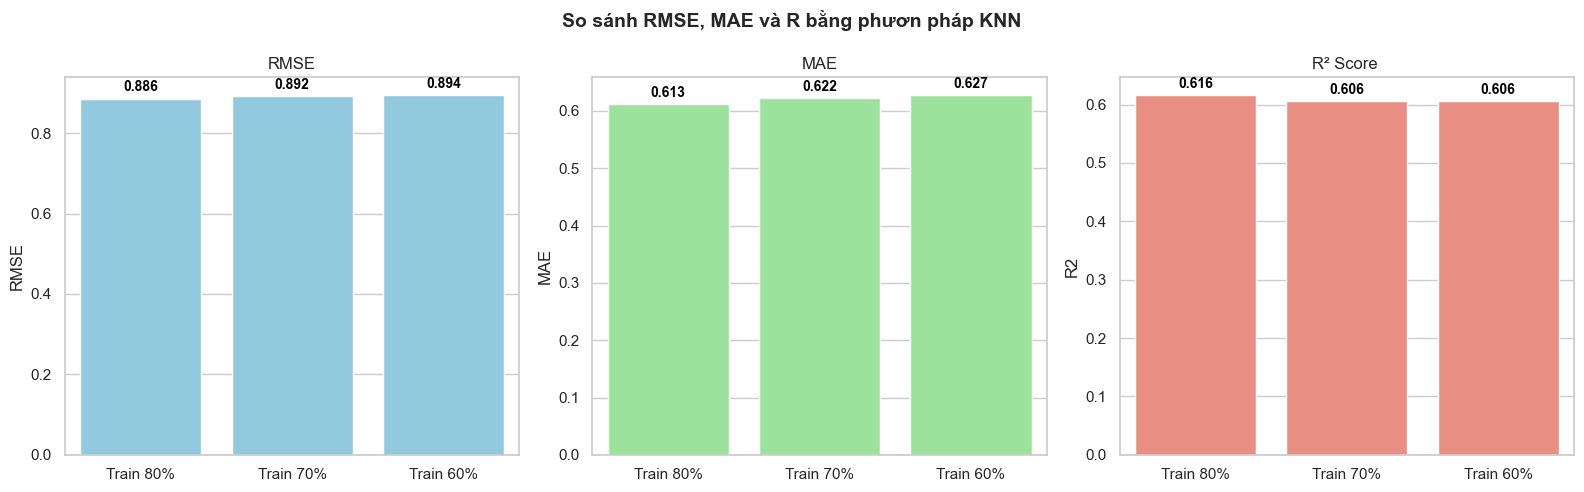

In [18]:
# Giả định X, y là dữ liệu đã được tiền xử lý của bạn
# X = df.drop(columns=['charges'])
# y = df['charges']
# ==========================================
# PHẦN 1: IN BẢNG KẾT QUẢ CƠ BẢN (K=5)
# ==========================================
metrics_knn, predictions_data = evaluate_splits(
    X, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomKNNRegressor,
    model_kwargs={"n_neighbors": 5}
)

plot_metrics_bar(metrics_knn, "So sánh RMSE, MAE và R bằng phươn pháp KNN")





Train 80%:
K        R2_train     R2_val     Gain
2          0.8361     0.5294  +0.0000
3          0.7812     0.5719  +0.0425
5          0.7392     0.6160  +0.0441
9          0.7070     0.6290  +0.0130
15         0.6842     0.6449  +0.0159 ← elbow
20         0.6739     0.6401  -0.0048
→ best_k=15 (gain tiếp theo < 0.01)

Train 70%:
K        R2_train     R2_val     Gain
2          0.8328     0.5234  +0.0000
3          0.7782     0.5738  +0.0504
5          0.7346     0.6062  +0.0324
9          0.7002     0.6255  +0.0193
15         0.6790     0.6374  +0.0119 ← elbow
20         0.6696     0.6317  -0.0057
→ best_k=15 (gain tiếp theo < 0.01)

Train 60%:
K        R2_train     R2_val     Gain
2          0.8305     0.5063  +0.0000
3          0.7737     0.5667  +0.0605
5          0.7297     0.6057  +0.0390
9          0.6966     0.6263  +0.0206 ← elbow
15         0.6754     0.6323  +0.0059
20         0.6661     0.6270  -0.0053
→ best_k=9 (gain tiếp theo < 0.01)


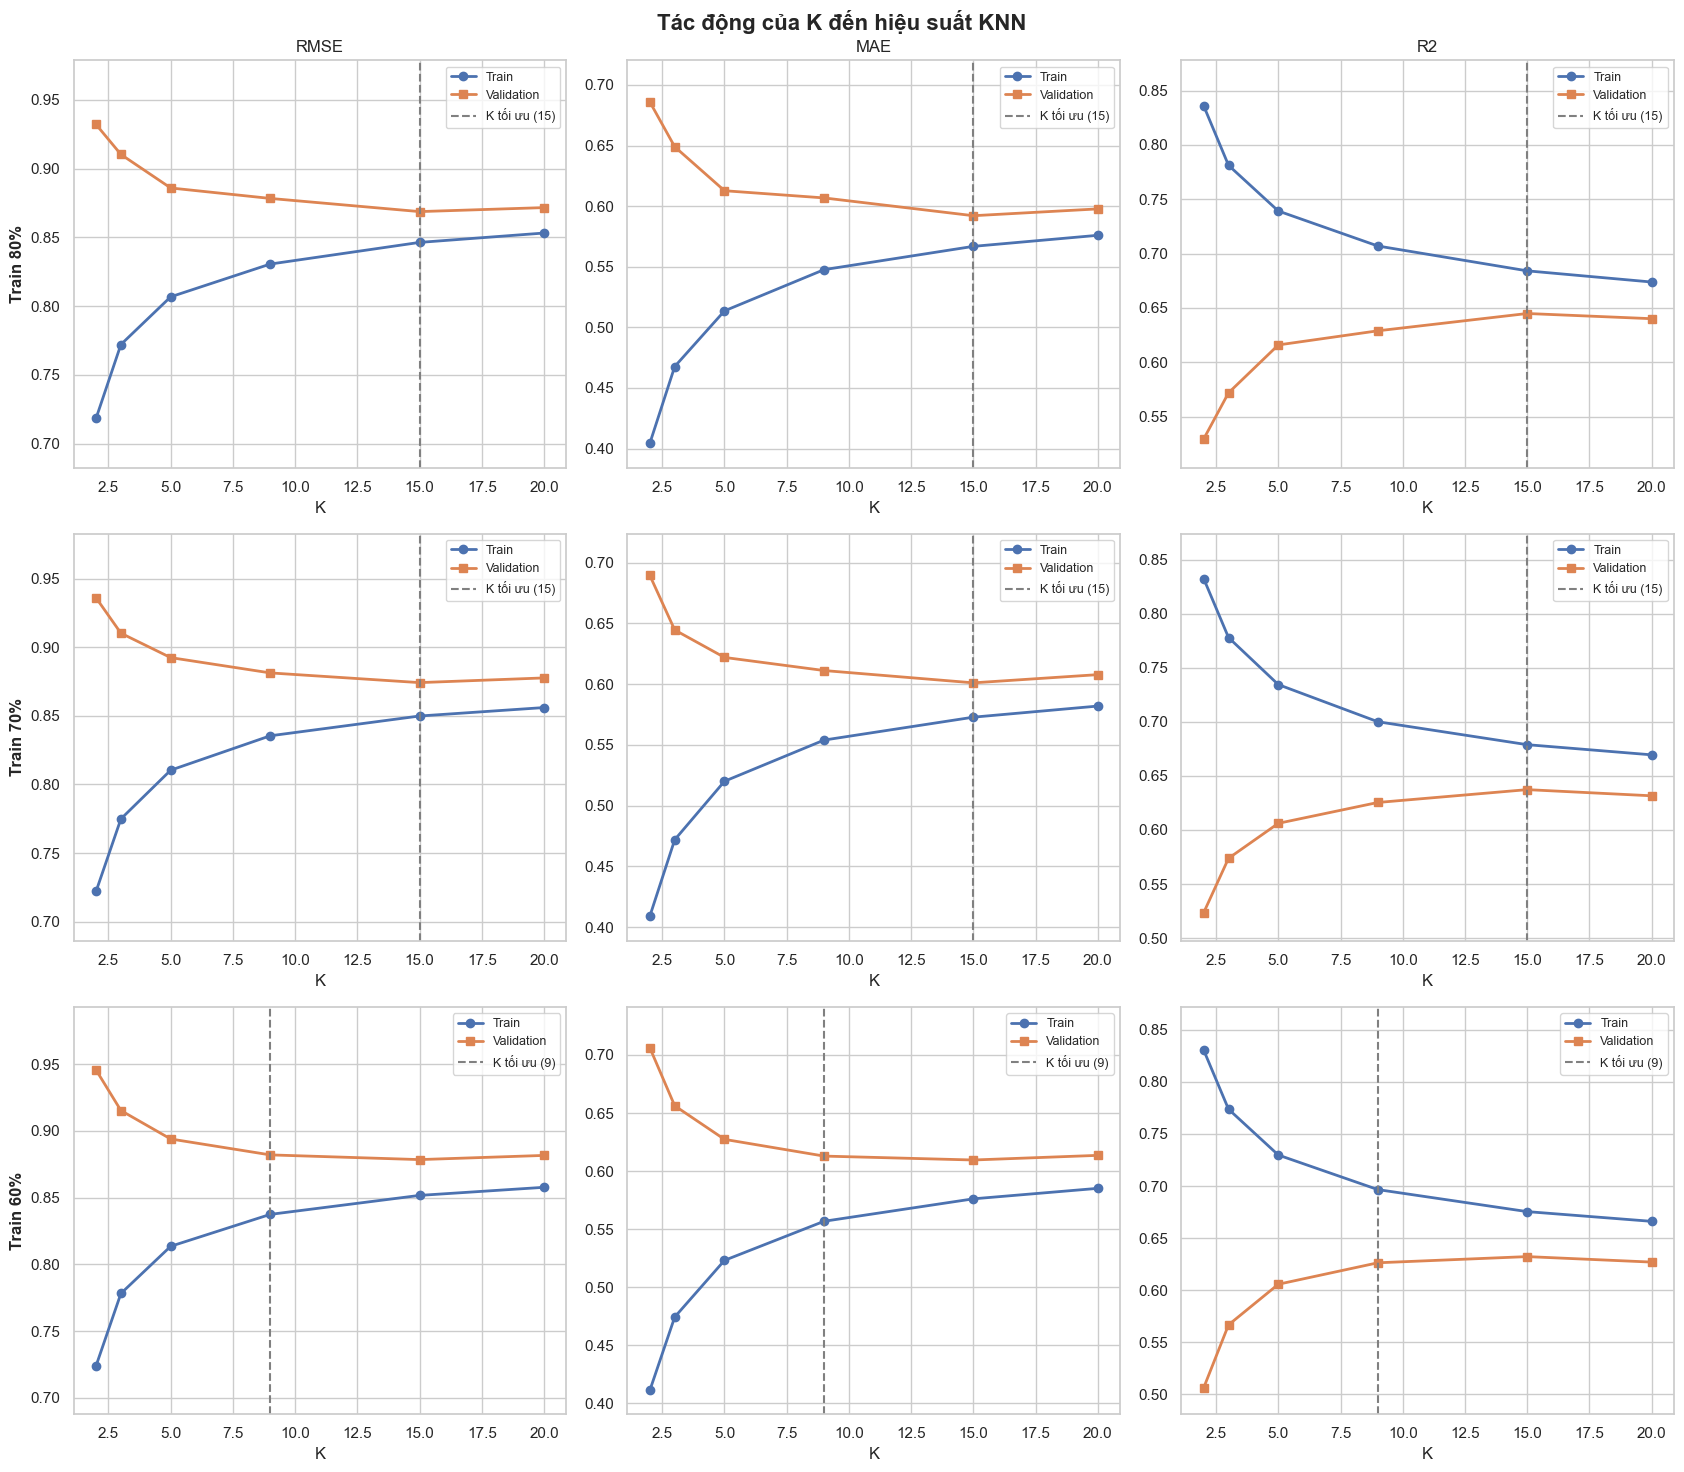

In [19]:

best_knn_data = plot_knn_regularization(X, y, test_sizes, labels)


OVERFITTING ANALYSIS - KNN
K | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
15 | Train 80%        |     0.6842 |     0.6449 |  +0.0393 |       0.8464 |     0.8688 |  +0.0224 |     0.5921 | Ổn định
15 | Train 70%        |     0.6790 |     0.6374 |  +0.0416 |       0.8499 |     0.8742 |  +0.0243 |     0.6011 | Ổn định
9 | Train 60%        |     0.6966 |     0.6263 |  +0.0702 |       0.8375 |     0.8820 |  +0.0445 |     0.6129 | Ổn định
--------------------------------------------------------------------------------


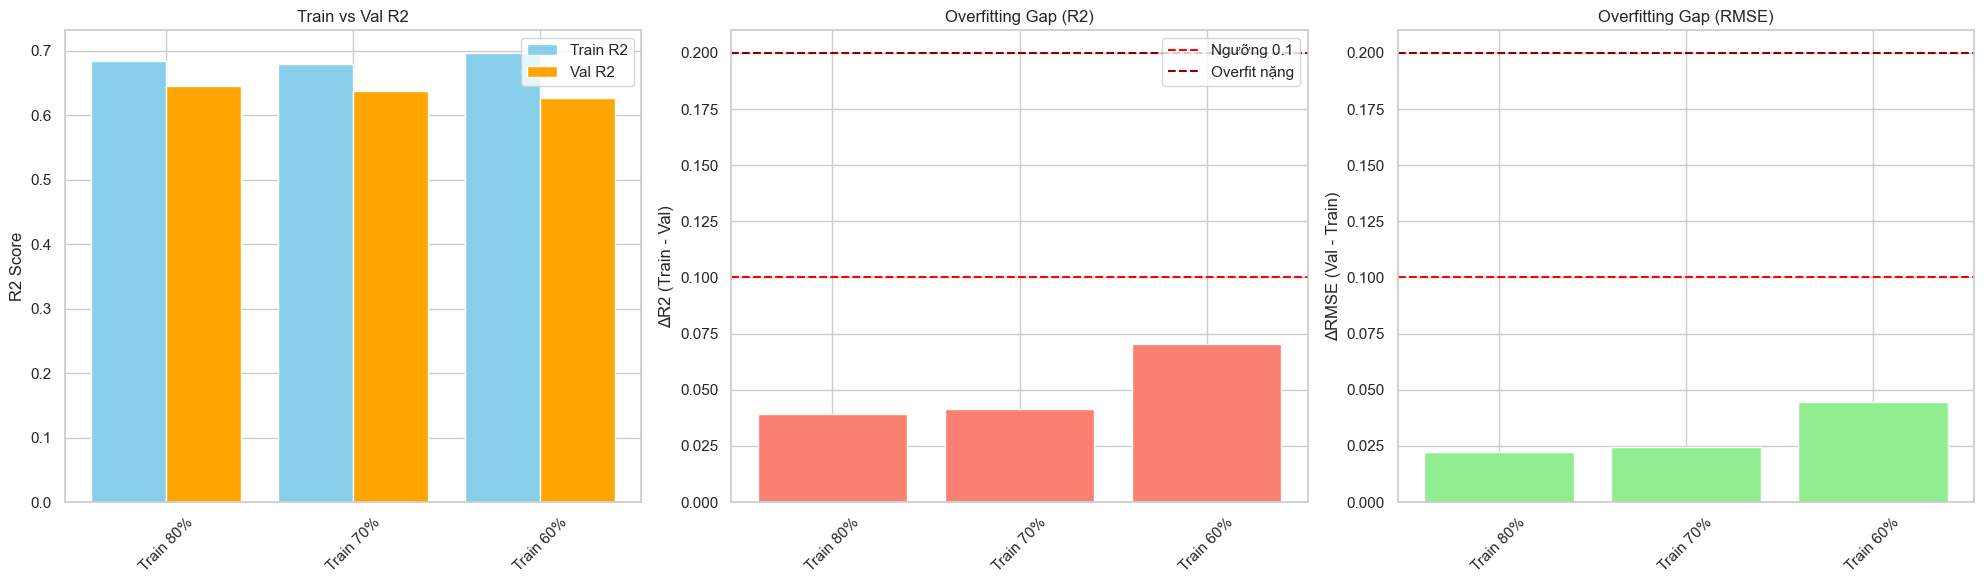

In [20]:

analyze_overfitting(best_knn_data,   model_name="KNN")

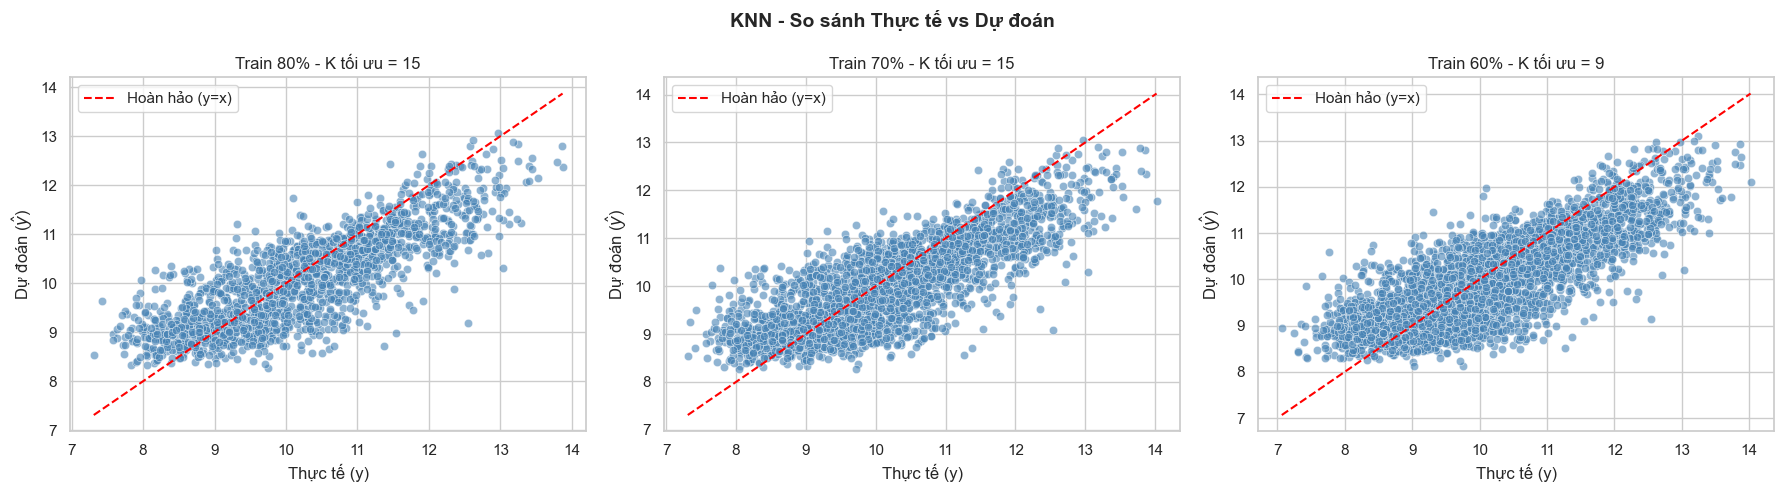

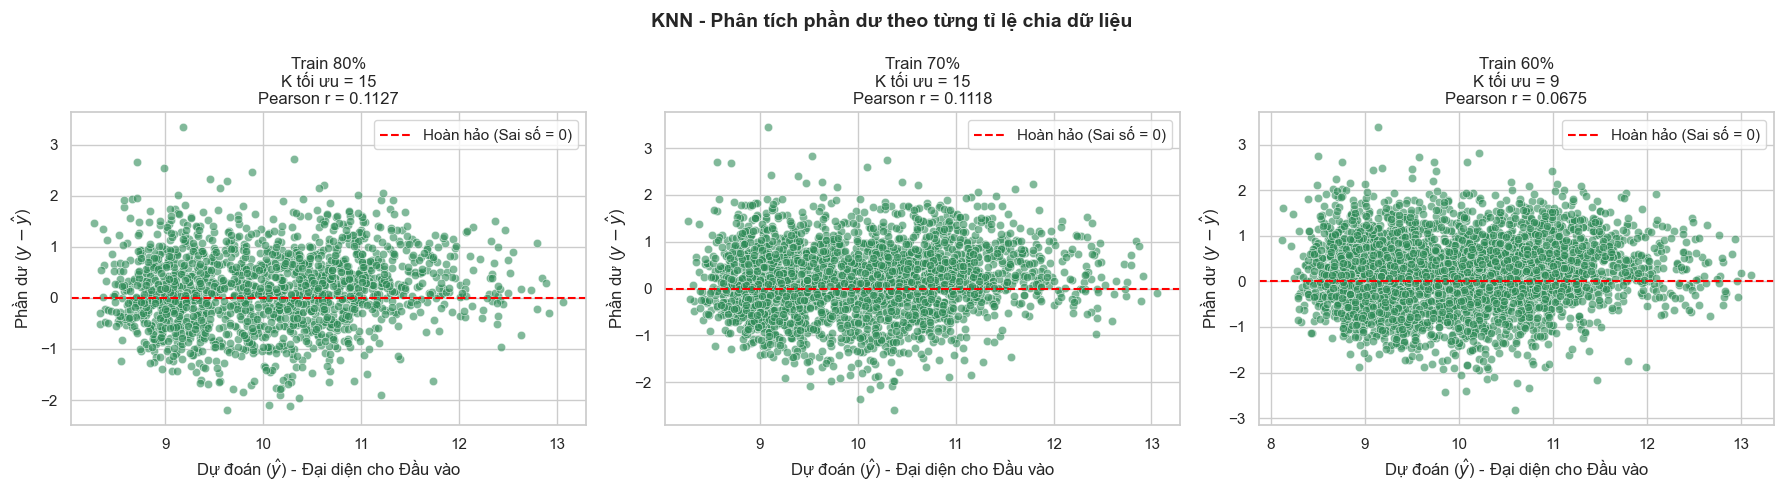

In [21]:
plot_actual_vs_predicted(
    best_knn_data,
    main_title="KNN - So sánh Thực tế vs Dự đoán"
)
plot_residuals(
    best_knn_data,
    main_title="KNN - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)

#### 6.1.2 Linear Regression 

In [ ]:

# ==========================================
# PHẦN 3: ĐÁNH GIÁ REGULARIZATION (Ridge Regression - Tuning Alpha)
# ==========================================

def plot_ridge_regularization(X, y, test_sizes, labels,
                               alphas=[0.01, 0.1, 1, 10, 100],
                               main_title="Tác động của Alpha đến hiệu suất Ridge Regression"):

    metrics_names = ['RMSE', 'MAE', 'R2']

    # tạo layout biểu đồ 
    fig, axes = plt.subplots(len(test_sizes), 3, figsize=(17, 5 * len(test_sizes)))
    fig.suptitle(main_title, fontsize=16, fontweight='bold')
    axes = np.array(axes).reshape(len(test_sizes), 3) # chuẩ hóa axes về dạng ma trận 

    best_models_data = []

    for row_idx, (test_size, label) in enumerate(zip(test_sizes, labels)):
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        train_metrics = {m: [] for m in metrics_names}
        val_metrics   = {m: [] for m in metrics_names}

        for a in alphas:
            ridge = CustomRidgeRegression(alpha=a)
            ridge.fit(X_train, y_train)

            y_train_pred = ridge.predict(X_train)
            y_val_pred   = ridge.predict(X_val)

            train_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
            train_metrics['MAE'].append(mean_absolute_error(y_train, y_train_pred))
            train_metrics['R2'].append(r2_score(y_train, y_train_pred))

            val_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
            val_metrics['MAE'].append(mean_absolute_error(y_val, y_val_pred))
            val_metrics['R2'].append(r2_score(y_val, y_val_pred))

        max_r2 = max(val_metrics['R2'])
        # argmax vẫn đúng với Ridge vì val R2 có dạng lồi
        best_idx = next(i for i, r2 in enumerate(val_metrics['R2'])
                if r2 >= max_r2 - 1e-6)
        best_alpha = alphas[best_idx]

        # Print giải thích lý do chọn alpha
        print(f"\n{label}:")
        print(f"{'Alpha':<12} {'R2_train':>10} {'R2_val':>10} {'ΔR²(train-val)':>16}  Nhận xét")
        print("-" * 65)
        for i, a in enumerate(alphas):
            dr2    = train_metrics['R2'][i] - val_metrics['R2'][i]
            marker = " ← CHỌN (R2_val cao nhất)" if a == best_alpha else ""
            # Nhận xét mức độ regularization
            if dr2 > 0.15:
                comment = "Overfit"
            elif dr2 < -0.05:
                comment = "Underfit"
            else:
                comment = "Cân bằng"
            print(f"{a:<12} {train_metrics['R2'][i]:>10.4f} {val_metrics['R2'][i]:>10.4f} "
                  f"{dr2:>+16.4f}  {comment}{marker}")
        print(f"\n→ Chọn Alpha={best_alpha} vì R2_val={val_metrics['R2'][best_idx]:.4f} "
              f"cao nhất, ΔR²={train_metrics['R2'][best_idx]-val_metrics['R2'][best_idx]:+.4f} "
              f"(cân bằng bias-variance tốt nhất)")

        best_ridge = CustomRidgeRegression(alpha=best_alpha).fit(X_train, y_train)
        best_models_data.append({
            'label':      label,
            'best_alpha': best_alpha,
            'y_val':      y_val,
            'y_pred':     best_ridge.predict(X_val),
            'RMSE':       val_metrics['RMSE'][best_idx],
            'MAE':        val_metrics['MAE'][best_idx],
            'R2':         val_metrics['R2'][best_idx],
            'RMSE_train': train_metrics['RMSE'][best_idx],
            'MAE_train':  train_metrics['MAE'][best_idx],
            'R2_train':   train_metrics['R2'][best_idx]
        })

        for col_idx, metric in enumerate(metrics_names):
            ax = axes[row_idx, col_idx]

            ax.plot(alphas, train_metrics[metric],
                    marker='o', label='Train', color='#AEC6CF', linewidth=2)
            ax.plot(alphas, val_metrics[metric],
                    marker='s', label='Validation', color='#FFB347', linewidth=2)
            ax.axvline(best_alpha, color='gray', linestyle='--', alpha=0.5,
                       label=f'Alpha tối ưu ({best_alpha})')

            all_vals = train_metrics[metric] + val_metrics[metric]
            ax.set_ylim(min(all_vals) * 0.95, max(all_vals) * 1.05)
            ax.set_xscale('log')

            if row_idx == 0:
                ax.set_title(f'{metric}', fontsize=12)
            if col_idx == 0:
                ax.set_ylabel(label, fontweight='bold')

            ax.set_xlabel('Alpha (Log scale)')
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return best_models_data

Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.8167 |   0.5203 |   0.7227
Train 70%        |      6,254 |      2,679 |   0.8182 |   0.5237 |   0.7217
Train 60%        |      5,360 |      3,573 |   0.8216 |   0.5271 |   0.7186
________________________________________________________________________


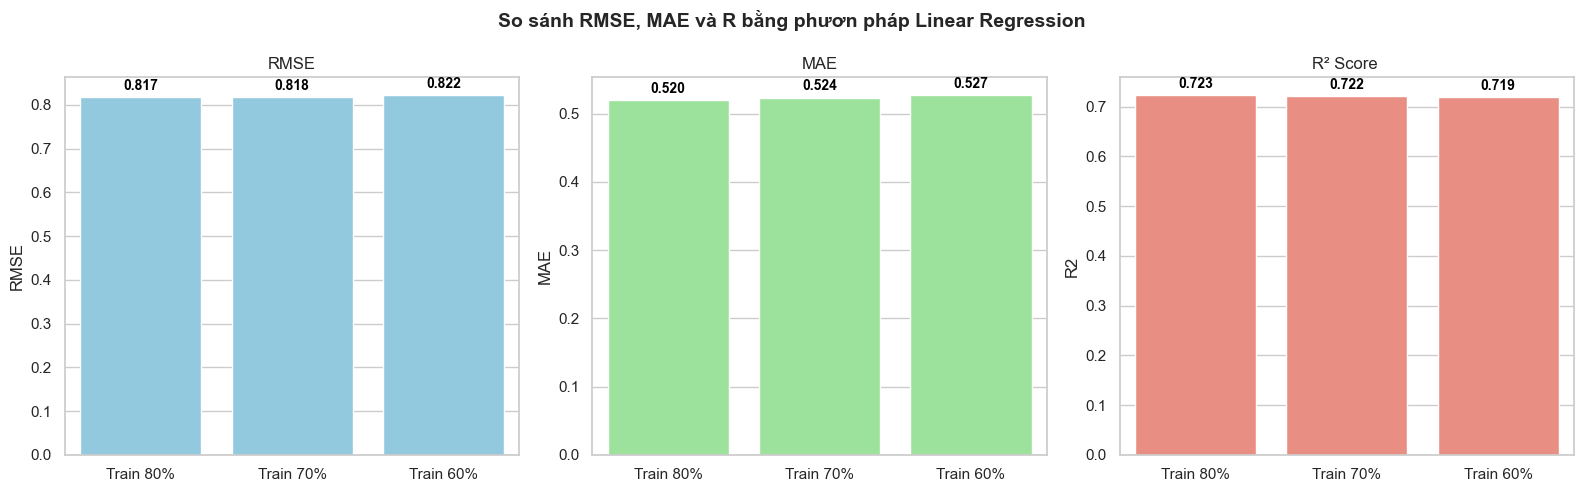

In [23]:

metrics_linear, predictions_data = evaluate_splits(
    X, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomLinearRegression,
    model_kwargs={}
)

plot_metrics_bar(metrics_linear, "So sánh RMSE, MAE và R bằng phươn pháp Linear Regression")




Train 80%:
Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
-----------------------------------------------------------------
0.01             0.7165     0.7227          -0.0062  Cân bằng ← CHỌN (R2_val cao nhất)
0.1              0.7165     0.7227          -0.0062  Cân bằng
1                0.7165     0.7227          -0.0062  Cân bằng
10               0.7164     0.7225          -0.0061  Cân bằng
100              0.7150     0.7214          -0.0065  Cân bằng

→ Chọn Alpha=0.01 vì R2_val=0.7227 cao nhất, ΔR²=-0.0062 (cân bằng bias-variance tốt nhất)

Train 70%:
Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
-----------------------------------------------------------------
0.01             0.7152     0.7217          -0.0065  Cân bằng ← CHỌN (R2_val cao nhất)
0.1              0.7152     0.7217          -0.0065  Cân bằng
1                0.7152     0.7217          -0.0065  Cân bằng
10               0.7151     0.7216          -0.0065  Cân bằng
100              0.7

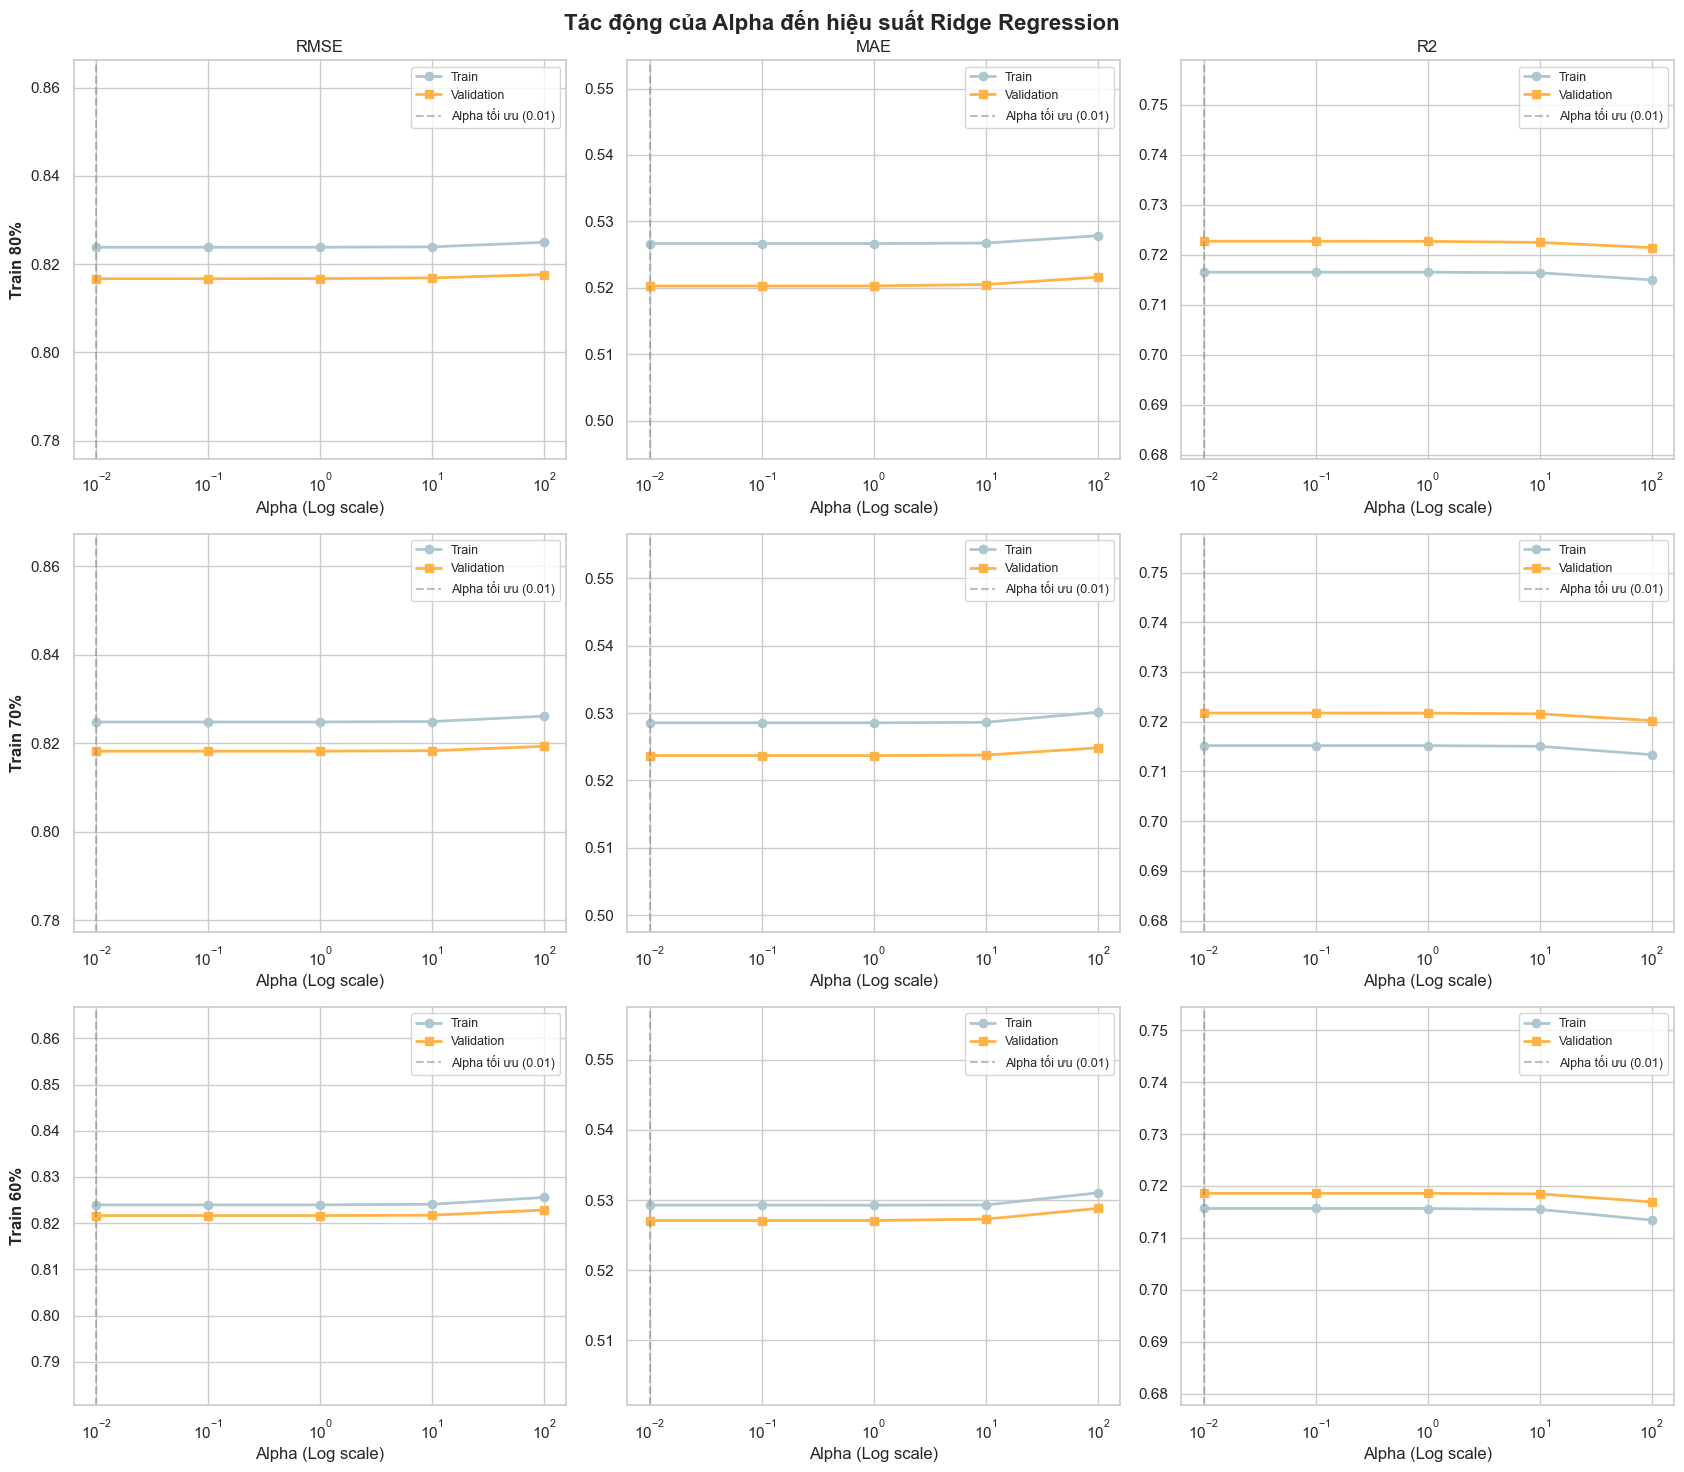

In [24]:
best_linear_data = plot_ridge_regularization(X, y, test_sizes, labels)



OVERFITTING ANALYSIS - Linear
Alpha | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
0.01 | Train 80%        |     0.7165 |     0.7227 |  -0.0062 |       0.8238 |     0.8167 |  -0.0071 |     0.5203 | Ổn định
0.01 | Train 70%        |     0.7152 |     0.7217 |  -0.0065 |       0.8248 |     0.8182 |  -0.0066 |     0.5237 | Ổn định
0.01 | Train 60%        |     0.7157 |     0.7186 |  -0.0029 |       0.8240 |     0.8216 |  -0.0023 |     0.5271 | Ổn định
--------------------------------------------------------------------------------


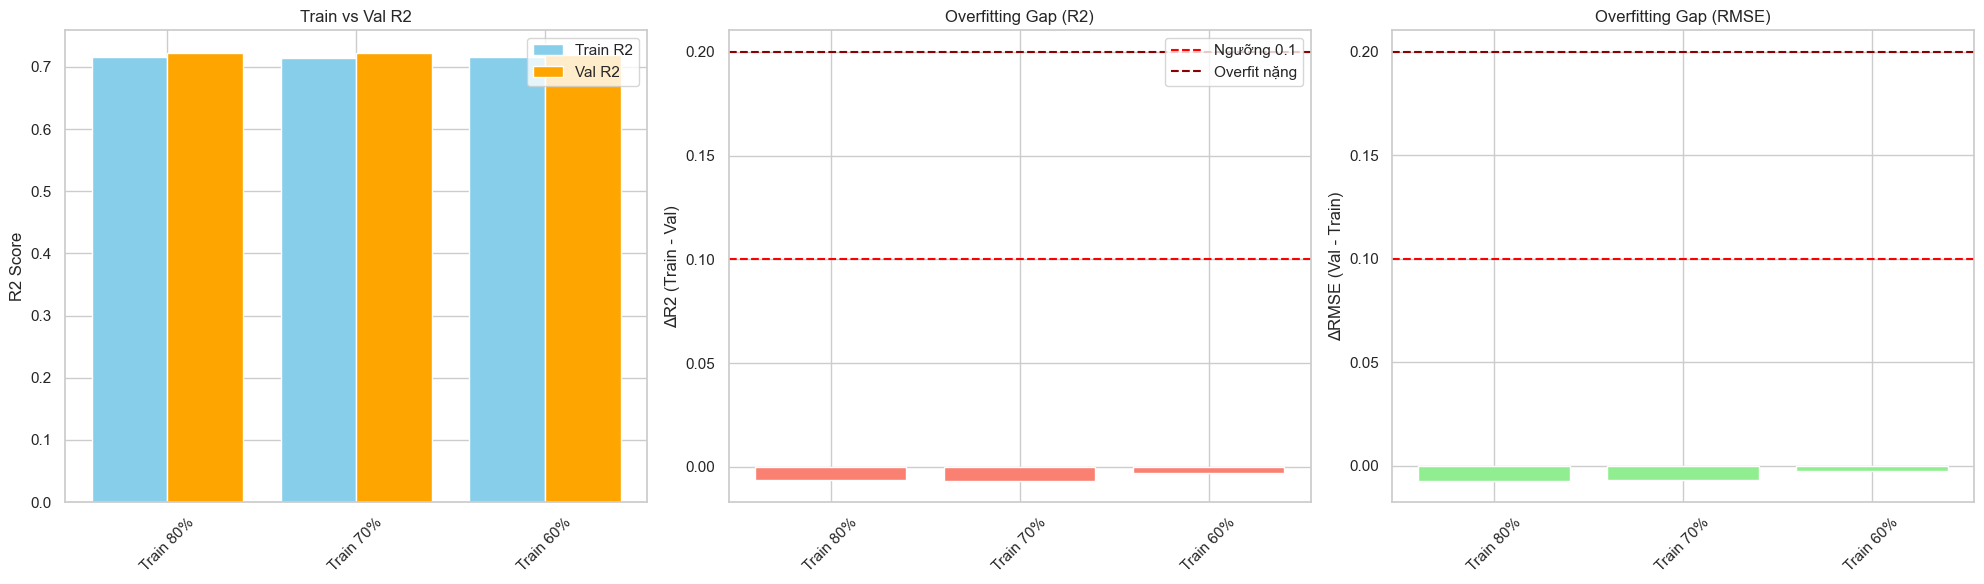

In [25]:
analyze_overfitting(best_linear_data, model_name="Linear")


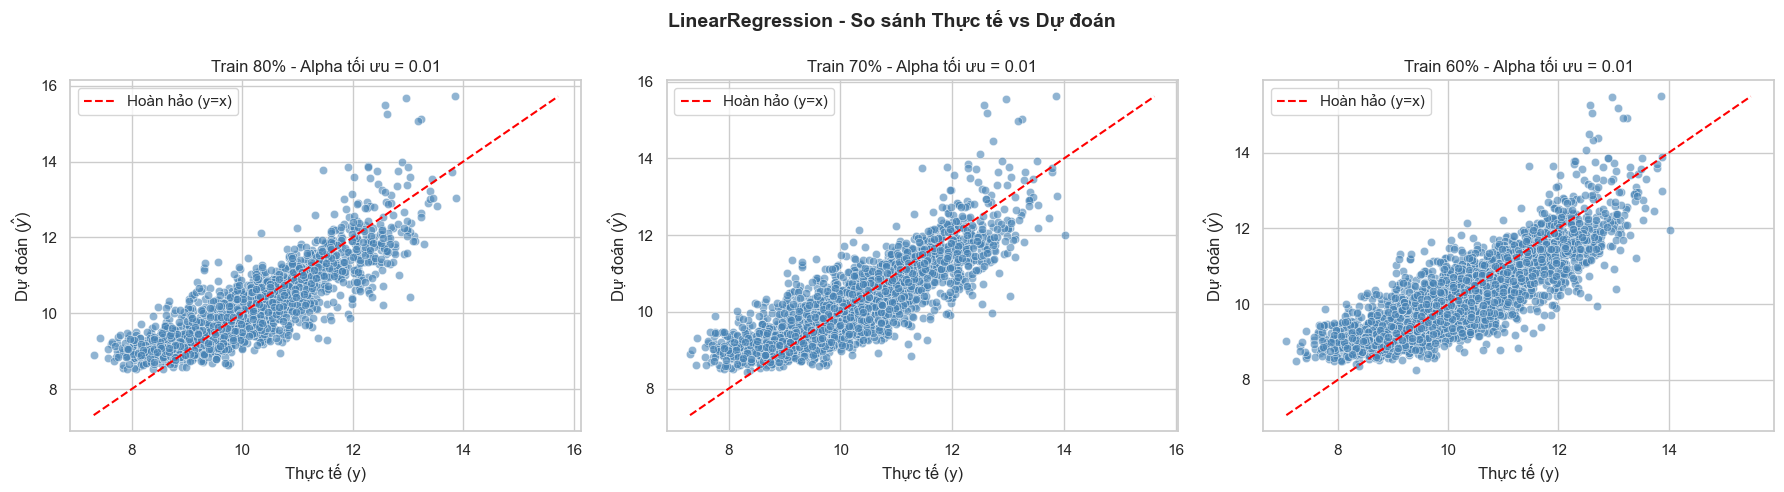

In [26]:
plot_actual_vs_predicted(
    best_linear_data,
    main_title="LinearRegression - So sánh Thực tế vs Dự đoán"
)


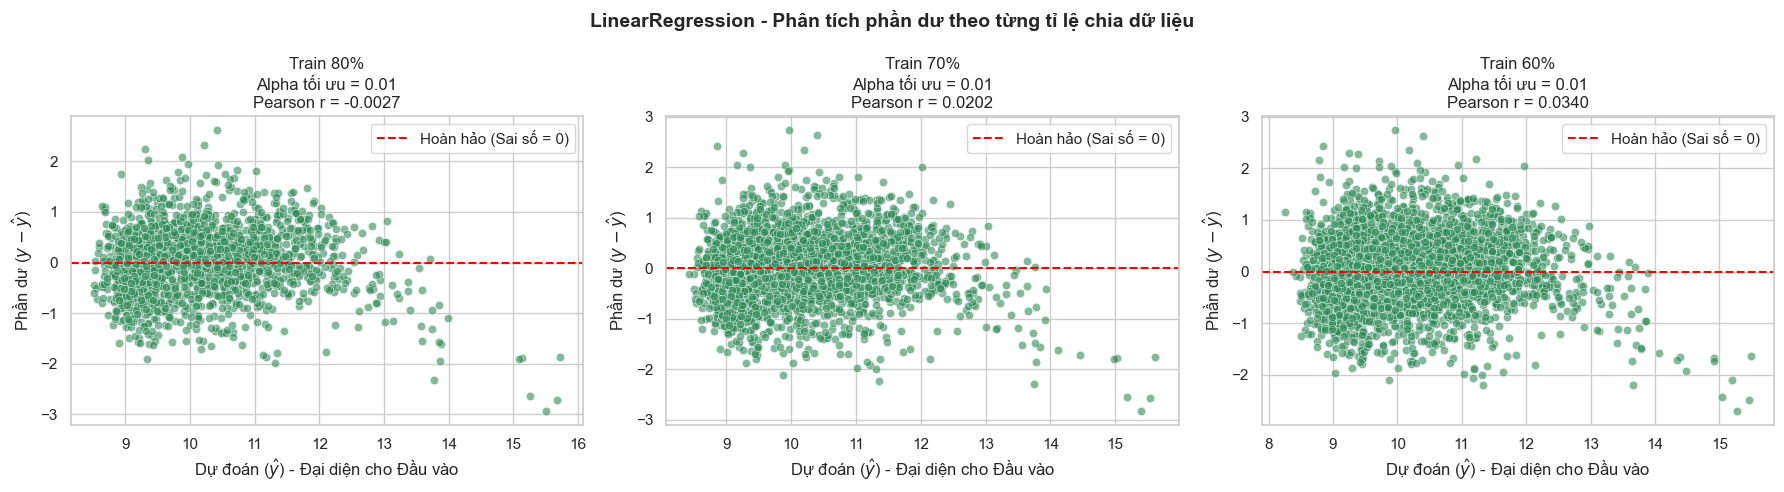

In [27]:
plot_residuals(
    best_linear_data,
    main_title="LinearRegression - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)

#### 6.1.3 Multi Layers Perceptron 

In [28]:
def plot_mlp_regularization(X, y, test_sizes, labels,
                             alphas=[0.1, 1, 10, 100],
                             hidden_size=64,
                             learning_rate=0.001,
                             epochs=200,
                             main_title="Tác động của Alpha (L2) đến hiệu suất MLP"):

    metrics_names = ['RMSE', 'MAE', 'R2']
    total = len(test_sizes) * len(alphas)
    count = 0

    fig, axes = plt.subplots(len(test_sizes), 3, figsize=(17, 5 * len(test_sizes)))
    fig.suptitle(main_title, fontsize=16, fontweight='bold')
    axes = np.array(axes).reshape(len(test_sizes), 3)

    best_models_data = []

    for row_idx, (test_size, label) in enumerate(zip(test_sizes, labels)):
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=42
        )

        train_metrics = {m: [] for m in metrics_names}
        val_metrics   = {m: [] for m in metrics_names}

        for a in alphas:
            count += 1
            print(f"  [{count}/{total}] {label} | Alpha={a} ...", end=' ')

            mlp = CustomMLPRegressor(
                hidden_size=hidden_size,
                learning_rate=learning_rate,
                epochs=epochs,
                lambda_reg=a,
                early_stopping=True
            )
            mlp.fit(X_train, y_train, X_val, y_val)
            print(f"dừng tại epoch {len(mlp.loss_history)}")

            y_train_pred = mlp.predict(X_train)
            y_val_pred   = mlp.predict(X_val)

            train_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
            train_metrics['MAE'].append(mean_absolute_error(y_train, y_train_pred))
            train_metrics['R2'].append(r2_score(y_train, y_train_pred))

            val_metrics['RMSE'].append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
            val_metrics['MAE'].append(mean_absolute_error(y_val, y_val_pred))
            val_metrics['R2'].append(r2_score(y_val, y_val_pred))

        # argmax đúng với MLP vì val R2 có dạng lồi (tăng rồi giảm theo alpha)
        best_idx   = np.argmax(val_metrics['R2'])
        best_alpha = alphas[best_idx]

        # Print giải thích lý do chọn alpha
        print(f"\n  {label}:")
        print(f"  {'Alpha':<12} {'R2_train':>10} {'R2_val':>10} {'ΔR²(train-val)':>16}  Nhận xét")
        print("  " + "-" * 65)
        for i, a in enumerate(alphas):
            dr2    = train_metrics['R2'][i] - val_metrics['R2'][i]
            marker = " ← CHỌN (R2_val cao nhất)" if a == best_alpha else ""
            if dr2 > 0.15:
                comment = "Overfit"
            elif dr2 < -0.05:
                comment = "Underfit"
            else:
                comment = "Cân bằng"
            print(f"  {a:<12} {train_metrics['R2'][i]:>10.4f} {val_metrics['R2'][i]:>10.4f} "
                  f"{dr2:>+16.4f}  {comment}{marker}")

        dr2_best = train_metrics['R2'][best_idx] - val_metrics['R2'][best_idx]
        print(f"\n  → Chọn Alpha={best_alpha} vì R2_val={val_metrics['R2'][best_idx]:.4f} "
              f"cao nhất, ΔR²={dr2_best:+.4f}\n")

        # Train lại model tốt nhất
        print(f"  Re-train best model (Alpha={best_alpha})...", end=' ')
        best_mlp = CustomMLPRegressor(
            hidden_size=hidden_size,
            learning_rate=learning_rate,
            epochs=epochs,
            lambda_reg=best_alpha,
            early_stopping=True
        ).fit(X_train, y_train, X_val, y_val)
        print(f"dừng tại epoch {len(best_mlp.loss_history)}\n")

        y_val_pred_best = best_mlp.predict(X_val)

        best_models_data.append({
            'label':      label,
            'best_alpha': best_alpha,
            'y_val':      y_val,
            'y_pred':     y_val_pred_best,
            'RMSE':       val_metrics['RMSE'][best_idx],
            'MAE':        val_metrics['MAE'][best_idx],
            'R2':         val_metrics['R2'][best_idx],
            'RMSE_train': train_metrics['RMSE'][best_idx],
            'MAE_train':  train_metrics['MAE'][best_idx],
            'R2_train':   train_metrics['R2'][best_idx]
        })

        for col_idx, metric in enumerate(metrics_names):
            ax = axes[row_idx, col_idx]

            ax.plot(alphas, train_metrics[metric],
                    marker='o', label='Train', color='#AEC6CF', linewidth=2)
            ax.plot(alphas, val_metrics[metric],
                    marker='s', label='Validation', color='#FFB347', linewidth=2)
            ax.axvline(best_alpha, color='gray', linestyle='--', alpha=0.5,
                       label=f'Alpha tối ưu ({best_alpha})')

            all_vals = train_metrics[metric] + val_metrics[metric]
            ax.set_ylim(min(all_vals) * 0.95, max(all_vals) * 1.05)
            ax.set_xscale('log')

            if row_idx == 0:
                ax.set_title(f'{metric}', fontsize=12)
            if col_idx == 0:
                ax.set_ylabel(label, fontweight='bold')

            ax.set_xlabel('Alpha (Log scale)')
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    return best_models_data

In [29]:

metrics_mlp, predictions_data = evaluate_splits(
    X, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomMLPRegressor,
    model_kwargs={
        "hidden_size": 64,
        "learning_rate": 0.01,  
        "epochs": 500,
        "lambda_reg": 0.01,
        "batch_size": 32
    }
)



Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.7623 |   0.4560 |   0.7895
Train 70%        |      6,254 |      2,679 |   0.7695 |   0.4610 |   0.7822
Train 60%        |      5,360 |      3,573 |   0.7832 |   0.4771 |   0.7677
________________________________________________________________________


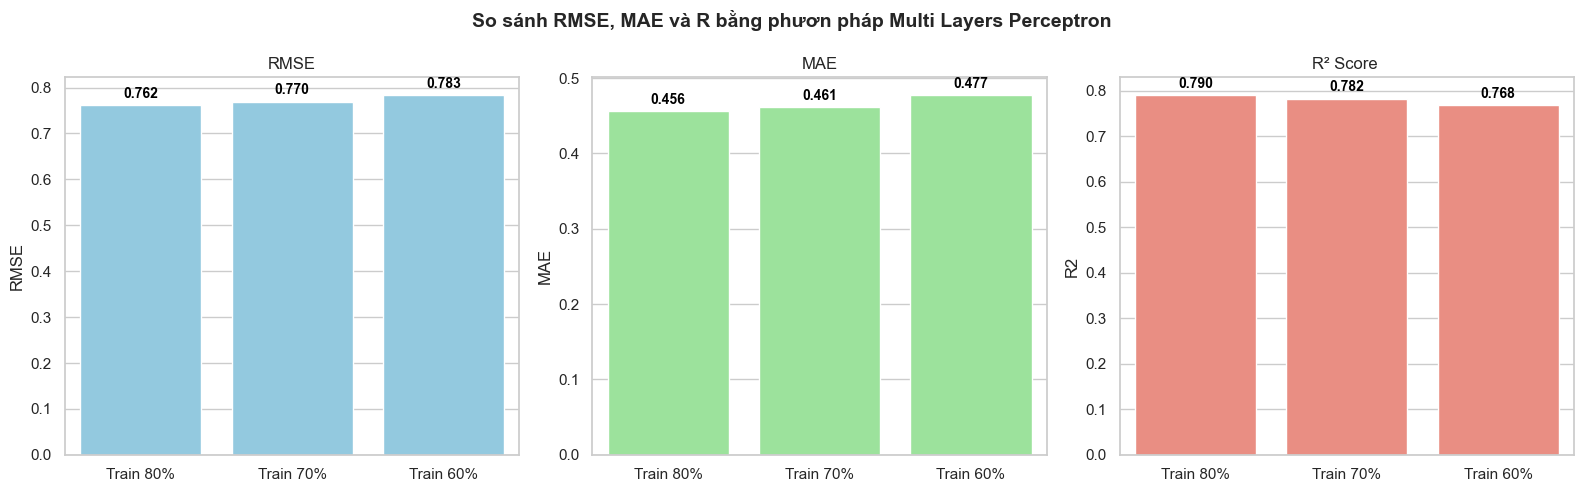

In [30]:
plot_metrics_bar(metrics_mlp, "So sánh RMSE, MAE và R bằng phươn pháp Multi Layers Perceptron")




  [1/12] Train 80% | Alpha=0.1 ... dừng tại epoch 200
  [2/12] Train 80% | Alpha=1 ... dừng tại epoch 200
  [3/12] Train 80% | Alpha=10 ... dừng tại epoch 200
  [4/12] Train 80% | Alpha=100 ... dừng tại epoch 200

  Train 80%:
  Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
  -----------------------------------------------------------------
  0.1              0.7914     0.7555          +0.0360  Cân bằng
  1                0.7918     0.7561          +0.0357  Cân bằng
  10               0.7947     0.7610          +0.0338  Cân bằng
  100              0.8043     0.7890          +0.0153  Cân bằng ← CHỌN (R2_val cao nhất)

  → Chọn Alpha=100 vì R2_val=0.7890 cao nhất, ΔR²=+0.0153

  Re-train best model (Alpha=100)... dừng tại epoch 200

  [5/12] Train 70% | Alpha=0.1 ... dừng tại epoch 200
  [6/12] Train 70% | Alpha=1 ... dừng tại epoch 200
  [7/12] Train 70% | Alpha=10 ... dừng tại epoch 200
  [8/12] Train 70% | Alpha=100 ... dừng tại epoch 200

  Train 70%:
  Alpha         

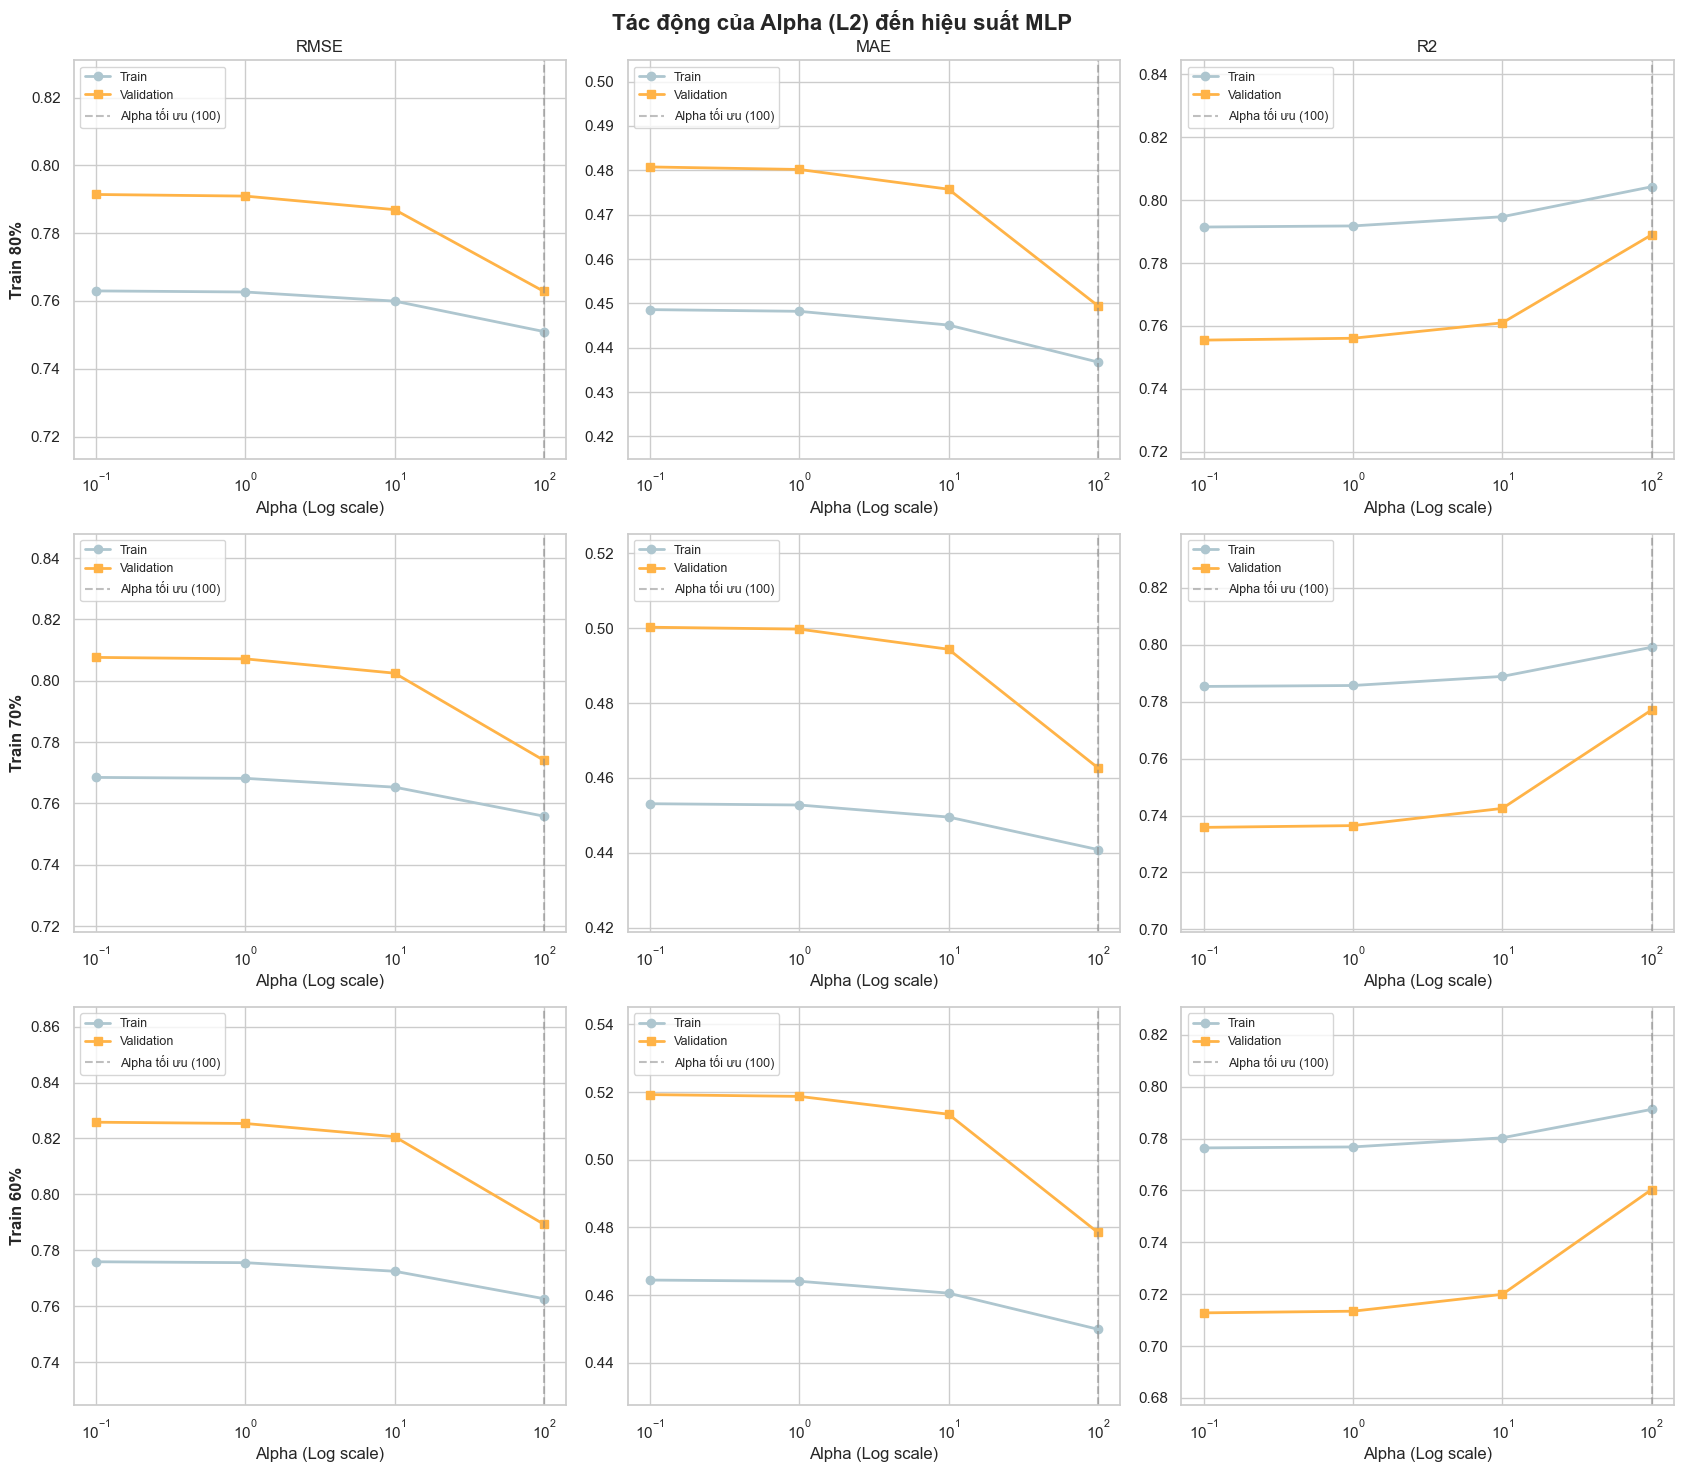

In [31]:
best_mlp_data = plot_mlp_regularization(X, y, test_sizes, labels)



OVERFITTING ANALYSIS - MLP
Alpha | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
100 | Train 80%        |     0.8043 |     0.7890 |  +0.0153 |       0.7510 |     0.7628 |  +0.0118 |     0.4495 | Ổn định
100 | Train 70%        |     0.7991 |     0.7771 |  +0.0220 |       0.7558 |     0.7740 |  +0.0182 |     0.4627 | Ổn định
100 | Train 60%        |     0.7913 |     0.7604 |  +0.0309 |       0.7627 |     0.7893 |  +0.0266 |     0.4785 | Ổn định
--------------------------------------------------------------------------------


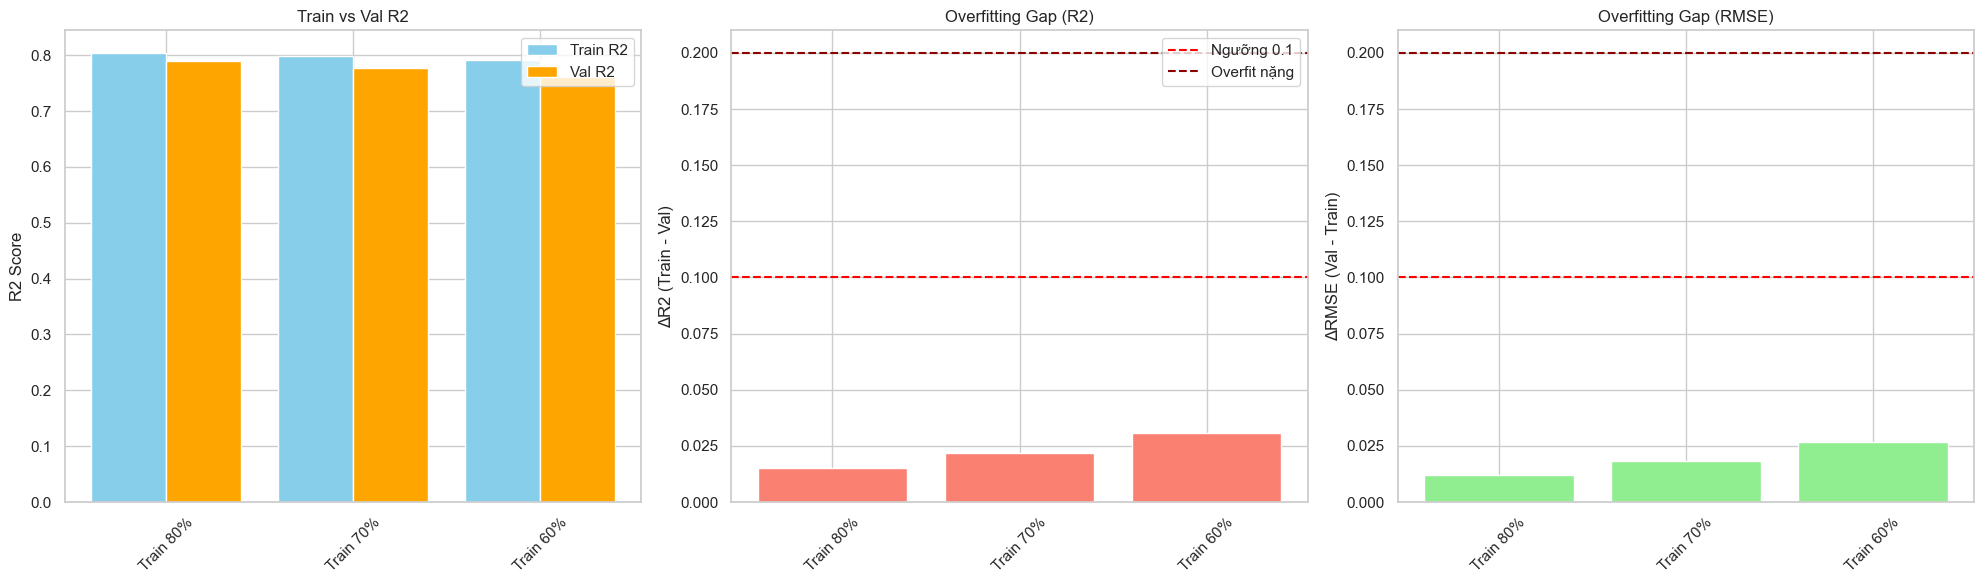

In [32]:
analyze_overfitting(best_mlp_data,   model_name="MLP")



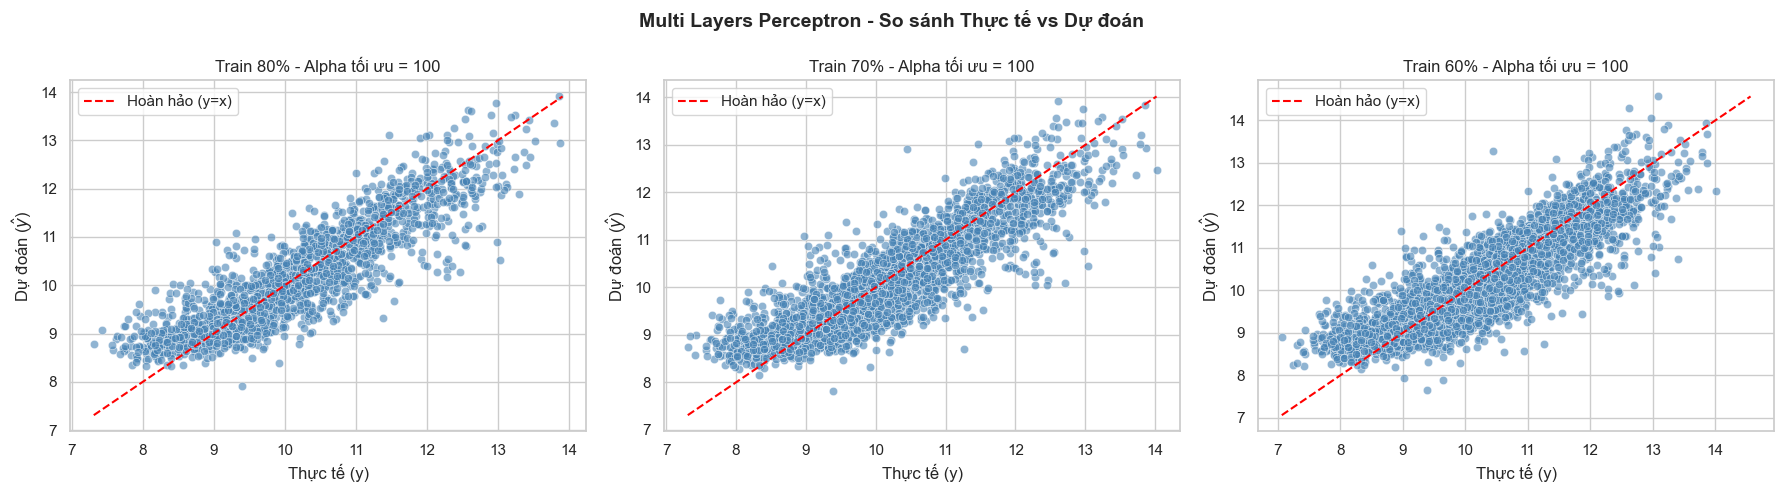

In [33]:
plot_actual_vs_predicted(
    best_mlp_data,
    main_title="Multi Layers Perceptron - So sánh Thực tế vs Dự đoán"
)


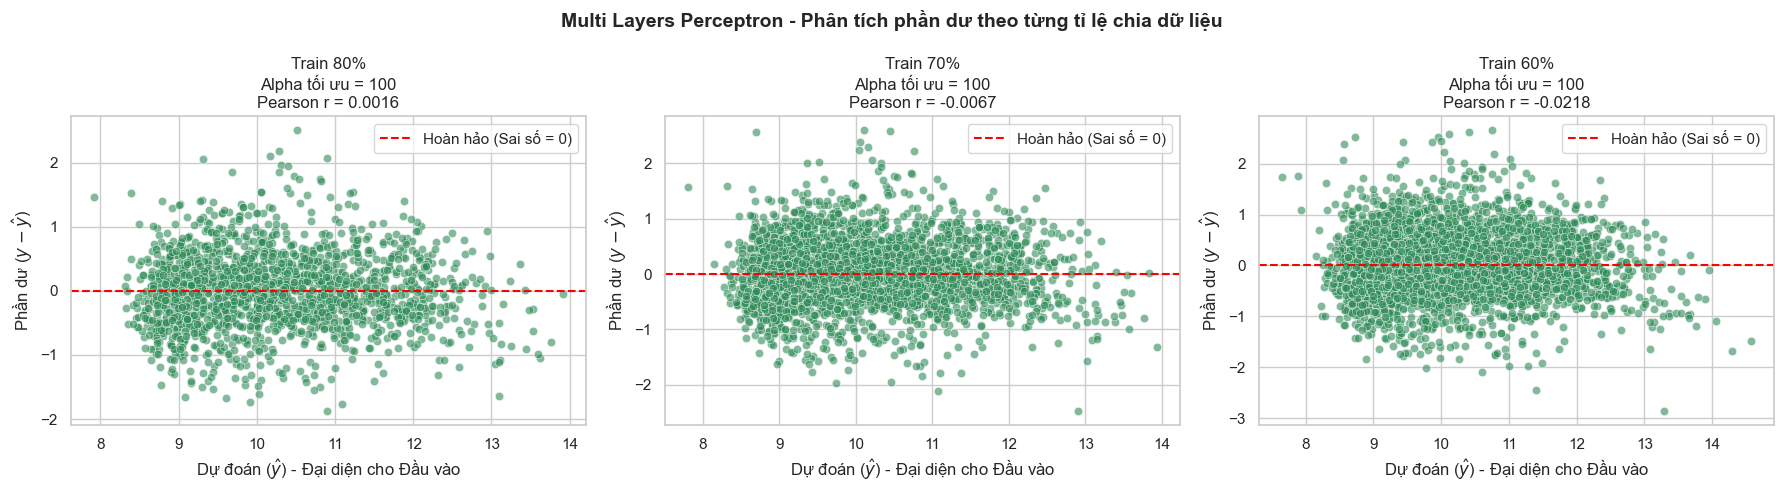

In [34]:
plot_residuals(
    best_mlp_data,
    main_title="Multi Layers Perceptron - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)

#### 6.1.4 Đánh giá

In [35]:
def plot_best_models_comparison(best_knn_data, best_ridge_data, best_mlp_data,
                                 pca_palette= sns.color_palette("pastel"),
                                 main_title='Đánh giá toàn diện: So sánh các mô hình tốt nhất theo từng tỉ lệ chia'):

    if pca_palette is None:
        pca_palette = {'KNN': '#AEC6CF', 'Ridge': '#FFB347', 'MLP': '#B5EAD7'}

    # Gộp best_models_data của 3 model thành 1 DataFrame
    rows = []
    for model_name, data in [('KNN', best_knn_data), ('Ridge', best_ridge_data), ('MLP', best_mlp_data)]:
        for m in data:
            rows.append({
                'Tỉ lệ chia':  m['label'],
                'Mô hình':     model_name,
                'RMSE':        m['RMSE'],
                'MAE':         m['MAE'],
                'R2':          m['R2']
            })

    df = pd.DataFrame(rows)

    # Melt để vẽ nhóm theo chỉ số
    df_melted = df.melt(
        id_vars=['Tỉ lệ chia', 'Mô hình'],
        value_vars=['RMSE', 'MAE', 'R2'],
        var_name='Chỉ số',
        value_name='Giá trị'
    )

    ratios = df['Tỉ lệ chia'].unique()
    fig, axes = plt.subplots(1, len(ratios), figsize=(6 * len(ratios), 6))
    fig.suptitle(main_title, fontsize=16, fontweight='bold', y=1.02)

    if len(ratios) == 1:
        axes = [axes]

    def add_bar_labels(ax):
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, color='#444444', fontsize=9)

    for i, ratio in enumerate(ratios):
        subset = df_melted[df_melted['Tỉ lệ chia'] == ratio]

        sns.barplot(x='Chỉ số', y='Giá trị', hue='Mô hình',
                    data=subset, ax=axes[i], palette=pca_palette)

        axes[i].set_title(f'Tỉ lệ {ratio}', fontsize=14, fontweight='bold', color='#333333')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Giá trị' if i == 0 else '')

        add_bar_labels(axes[i])

        if i != len(ratios) // 2:
            axes[i].get_legend().remove()
        else:
            sns.move_legend(axes[i], "lower center",
                            bbox_to_anchor=(0.5, -0.22),
                            ncol=3, title=None, frameon=False, fontsize=11)

    plt.tight_layout()
    plt.show()

    return df

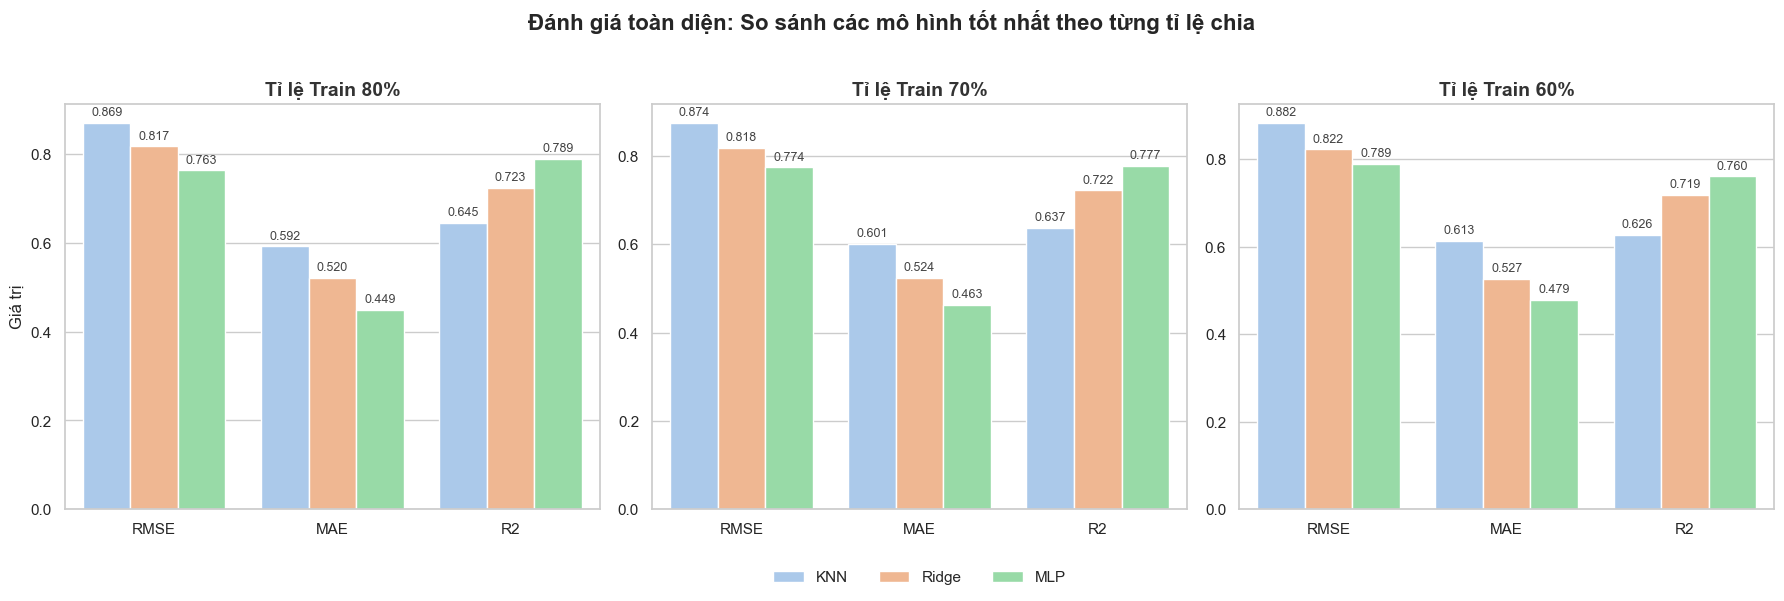

In [36]:
df_comparison = plot_best_models_comparison(best_knn_data, best_linear_data, best_mlp_data)

### 6.2 Thực hiện với dữ liệu giảm chiều

In [37]:

print("=" * 75)
print("BƯỚC 0: ÁP DỤNG PCA GIẢM CHIỀU DỮ LIỆU")
print("=" * 75)
X = df.drop(columns=['charges'])
y = df['charges']

# 2. Thực hiện giảm chiều PCA xuống 25 chiều
n = 20
pca = PCA(n_components=n, random_state=32)
X_pca_array = pca.fit_transform(X)

# Chuyển mảng X_pca_array về lại dạng DataFrame để tương thích với .iloc trong hàm chia tập
X_pca = pd.DataFrame(X_pca_array, columns=[f'PC{i+1}' for i in range(n)])

print(f"▸ Kích thước dữ liệu gốc : {X.shape}")
print(f"▸ Kích thước sau khi PCA : {X_pca.shape}")
print(f"▸ Lượng thông tin giữ lại: {np.sum(pca.explained_variance_ratio_)*100:.2f}%\n")

BƯỚC 0: ÁP DỤNG PCA GIẢM CHIỀU DỮ LIỆU
▸ Kích thước dữ liệu gốc : (8933, 46)
▸ Kích thước sau khi PCA : (8933, 20)
▸ Lượng thông tin giữ lại: 84.07%



#### 6.2.1 K-NN

Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.8881 |   0.6176 |   0.6122
Train 70%        |      6,254 |      2,679 |   0.8913 |   0.6255 |   0.6082
Train 60%        |      5,360 |      3,573 |   0.9015 |   0.6416 |   0.5922
________________________________________________________________________


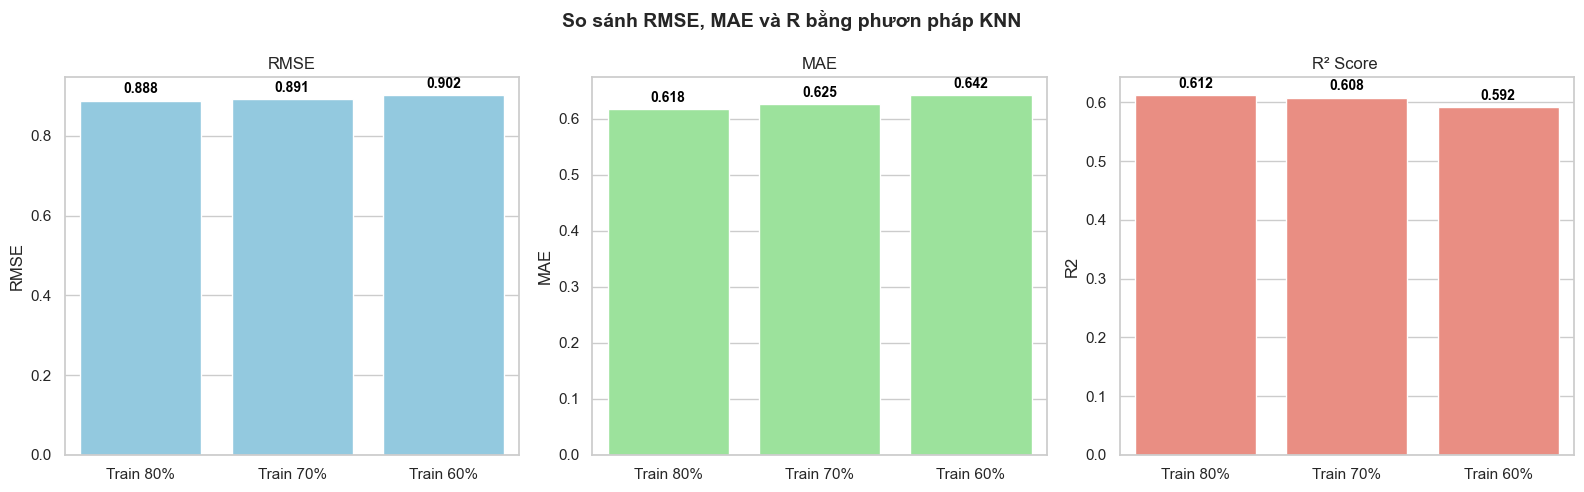

In [38]:

# ==========================================
# PHẦN 1: IN BẢNG KẾT QUẢ CƠ BẢN (K=5)
# ==========================================
metrics_knn, predictions_data = evaluate_splits(
    X_pca, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomKNNRegressor,
    model_kwargs={"n_neighbors": 5}
)

plot_metrics_bar(metrics_knn, "So sánh RMSE, MAE và R bằng phươn pháp KNN")



Train 80%:
K        R2_train     R2_val     Gain
2          0.8279     0.5158  +0.0000
3          0.7721     0.5711  +0.0553
5          0.7305     0.6122  +0.0410
9          0.7016     0.6326  +0.0205 ← elbow
15         0.6810     0.6322  -0.0005
20         0.6693     0.6323  +0.0001
→ best_k=9 (gain tiếp theo < 0.01)

Train 70%:
K        R2_train     R2_val     Gain
2          0.8258     0.5039  +0.0000
3          0.7661     0.5691  +0.0652
5          0.7232     0.6082  +0.0391
9          0.6960     0.6280  +0.0198 ← elbow
15         0.6738     0.6319  +0.0039
20         0.6647     0.6282  -0.0037
→ best_k=9 (gain tiếp theo < 0.01)

Train 60%:
K        R2_train     R2_val     Gain
2          0.8226     0.4897  +0.0000
3          0.7691     0.5561  +0.0664
5          0.7228     0.5922  +0.0361
9          0.6917     0.6218  +0.0296 ← elbow
15         0.6703     0.6215  -0.0002
20         0.6612     0.6207  -0.0008
→ best_k=9 (gain tiếp theo < 0.01)


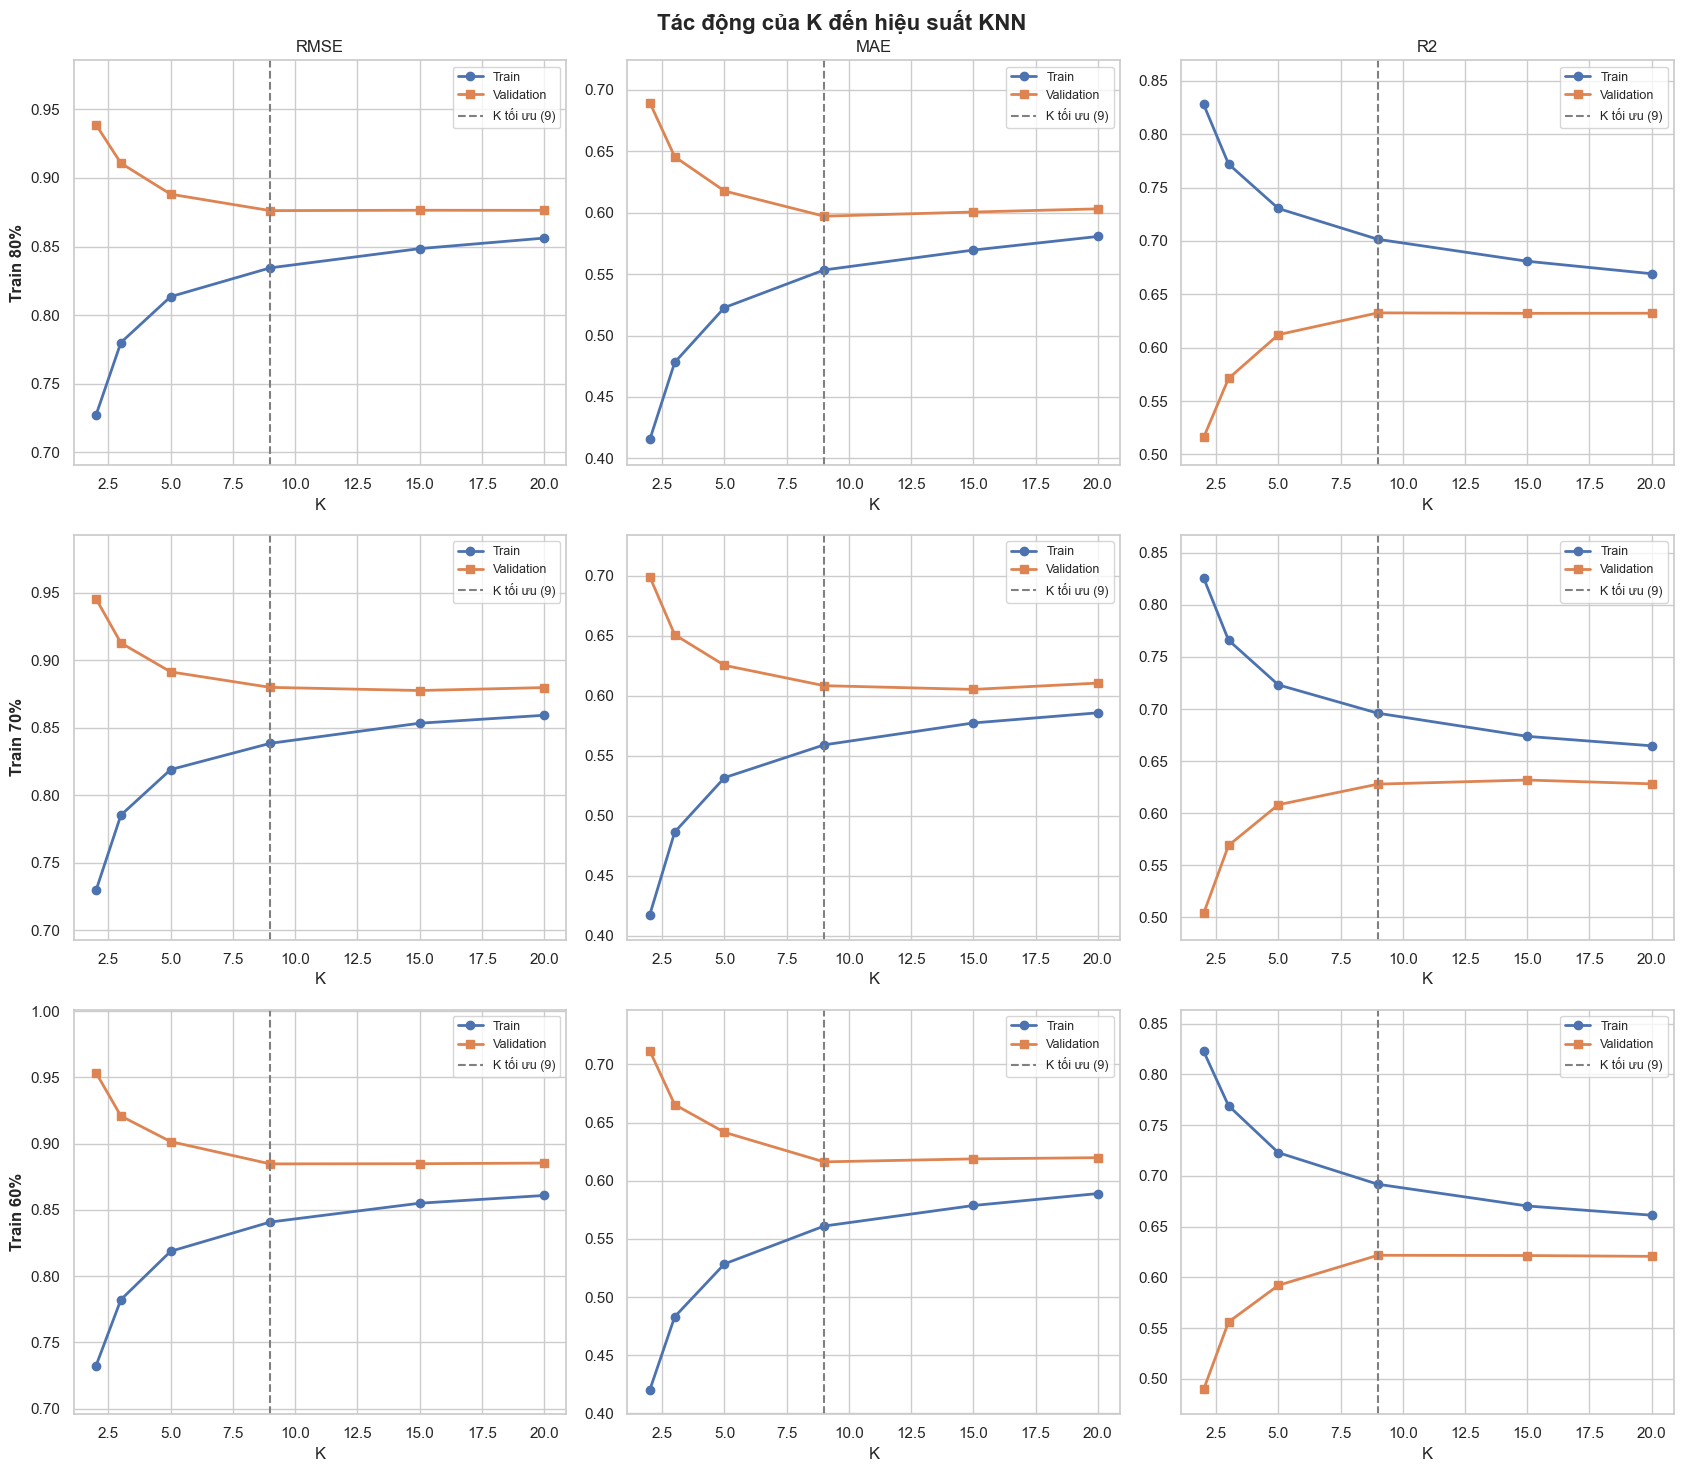

In [39]:

best_knn_pca = plot_knn_regularization(X_pca, y, test_sizes, labels)


OVERFITTING ANALYSIS - KNN
K | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
9 | Train 80%        |     0.7016 |     0.6326 |  +0.0689 |       0.8345 |     0.8762 |  +0.0417 |     0.5971 | Ổn định
9 | Train 70%        |     0.6960 |     0.6280 |  +0.0680 |       0.8384 |     0.8798 |  +0.0415 |     0.6085 | Ổn định
9 | Train 60%        |     0.6917 |     0.6218 |  +0.0699 |       0.8408 |     0.8847 |  +0.0439 |     0.6162 | Ổn định
--------------------------------------------------------------------------------


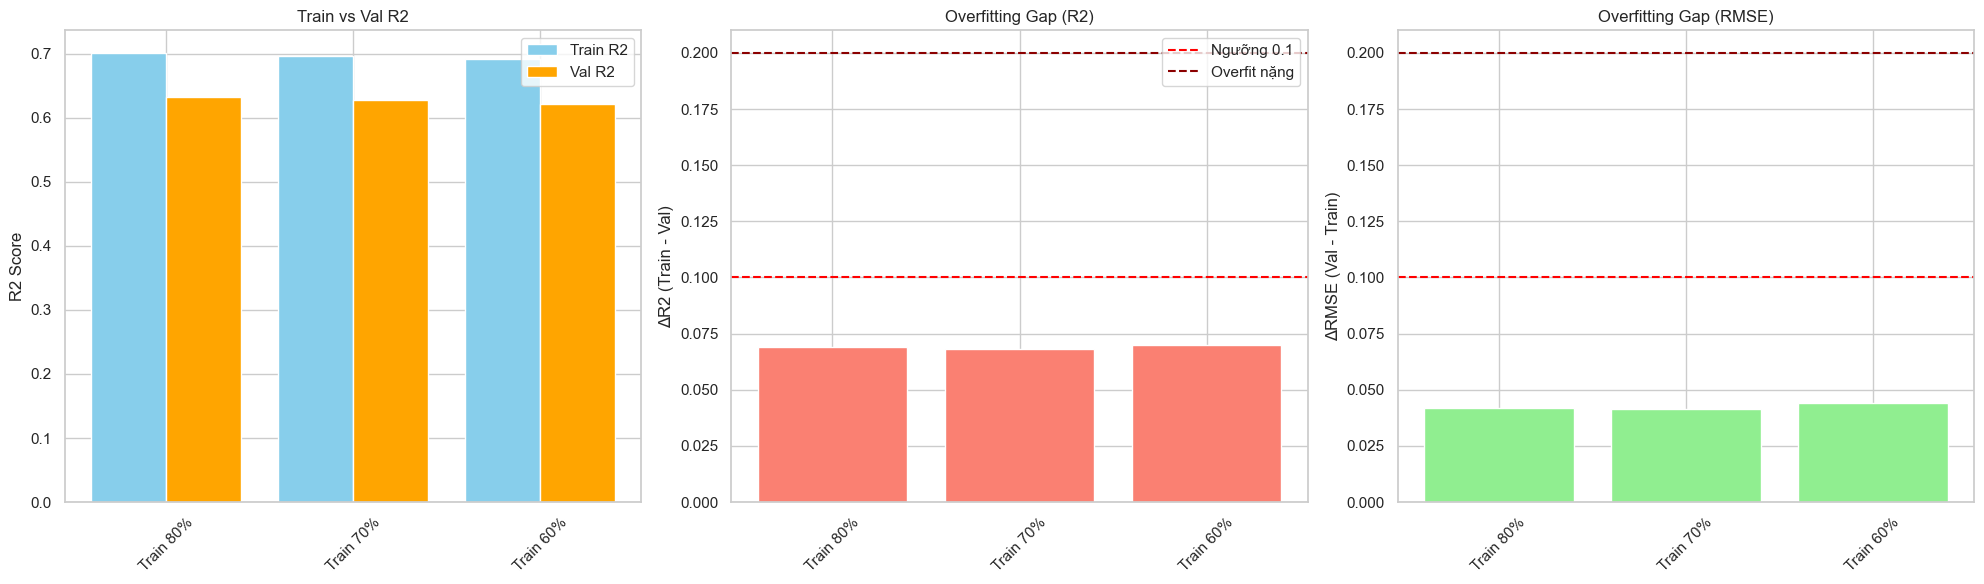

In [40]:
analyze_overfitting(best_knn_pca,   model_name="KNN")



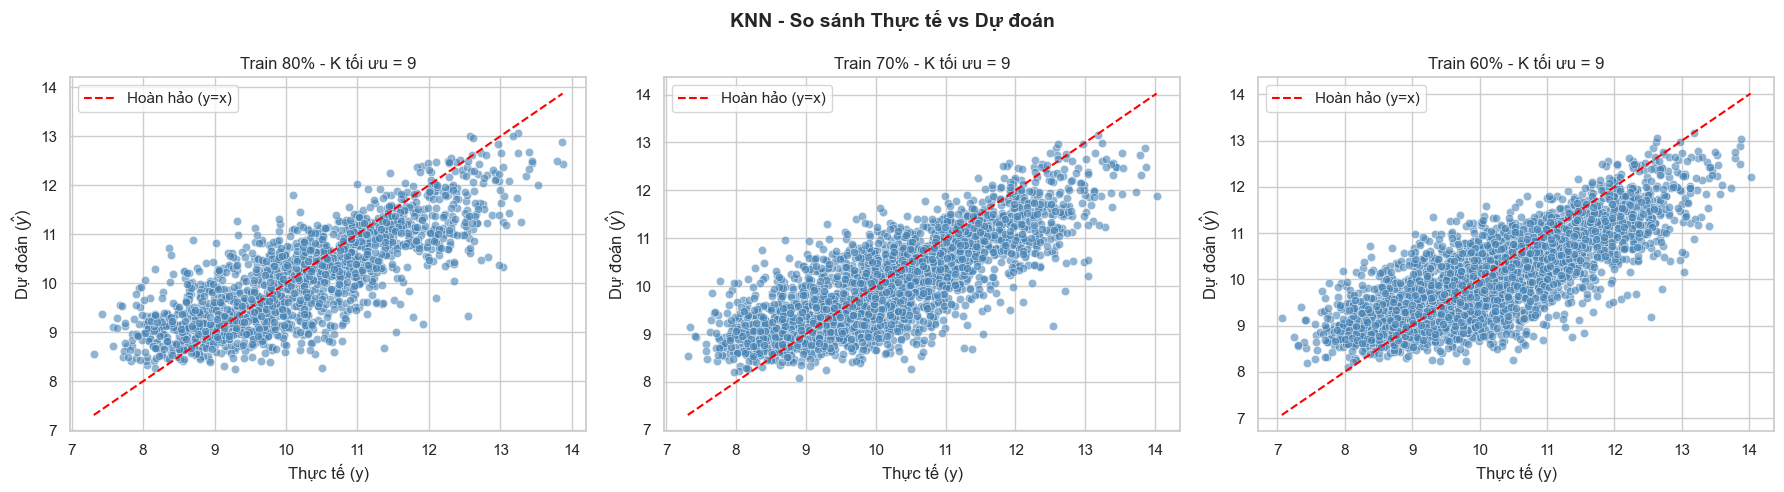

In [41]:
plot_actual_vs_predicted(
    best_knn_pca,
    main_title="KNN - So sánh Thực tế vs Dự đoán"
)


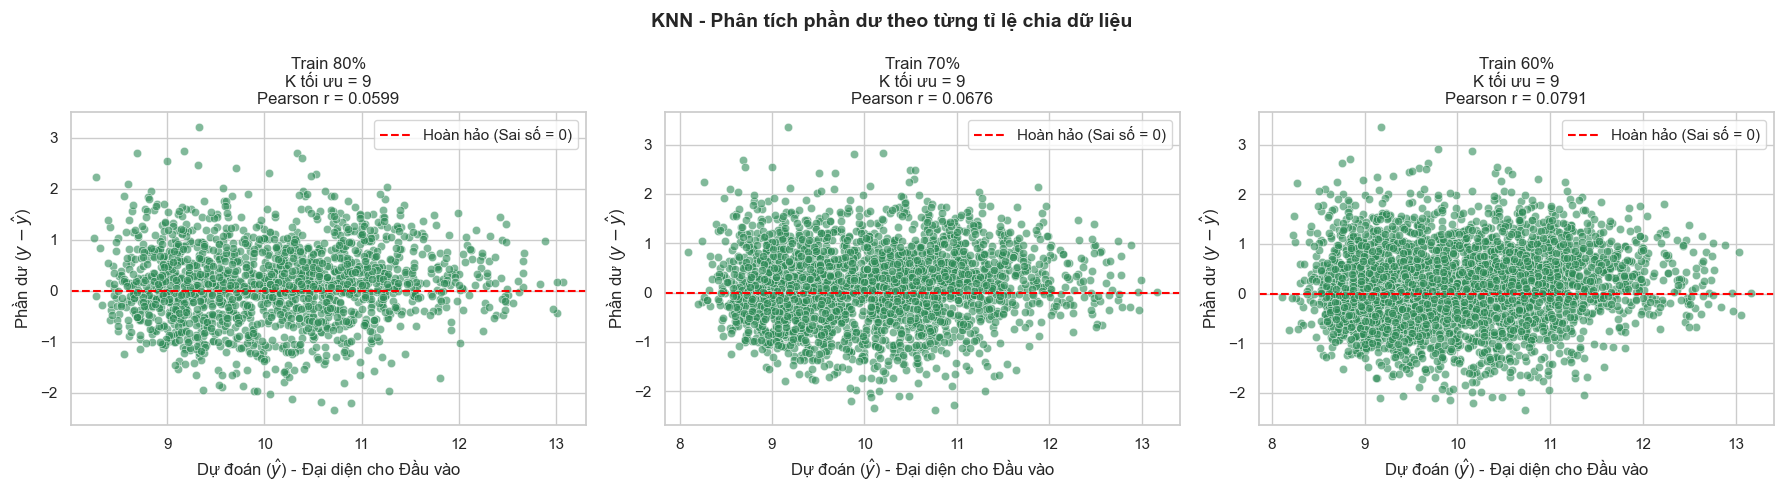

In [42]:
plot_residuals(
    best_knn_pca,
    main_title="KNN - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)

#### 6.2.2 Linear Regression

Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.8481 |   0.5623 |   0.6775
Train 70%        |      6,254 |      2,679 |   0.8474 |   0.5626 |   0.6798
Train 60%        |      5,360 |      3,573 |   0.8501 |   0.5667 |   0.6776
________________________________________________________________________


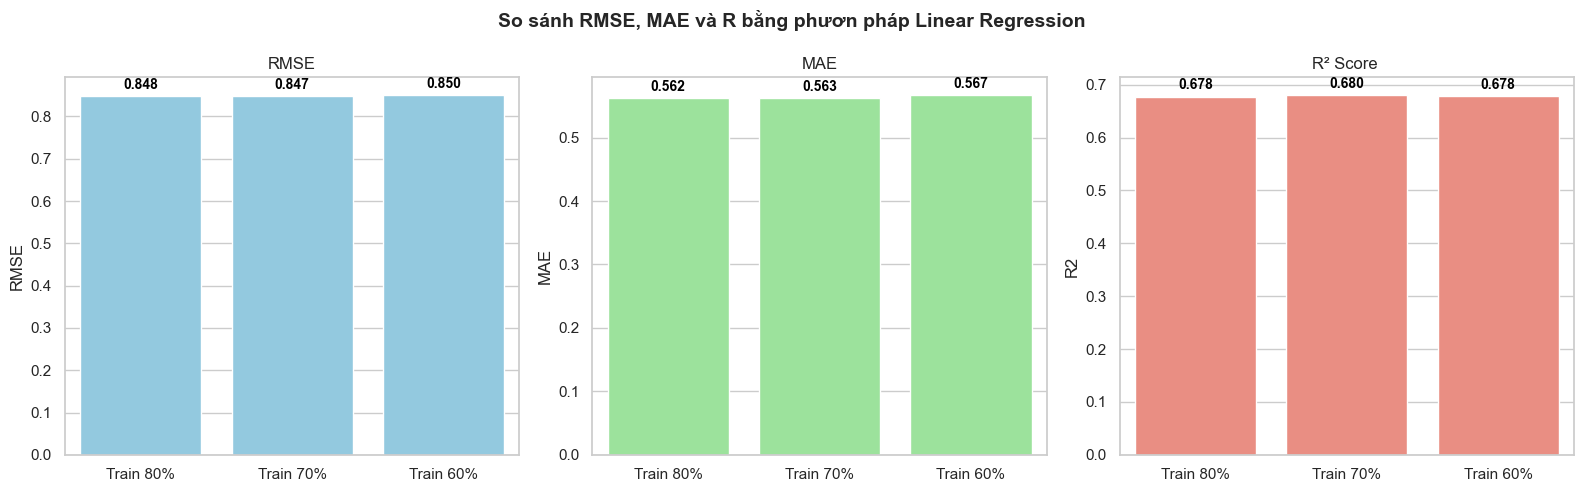


Train 80%:
Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
-----------------------------------------------------------------
0.01             0.6730     0.6775          -0.0045  Cân bằng
0.1              0.6730     0.6775          -0.0045  Cân bằng
1                0.6730     0.6775          -0.0045  Cân bằng
10               0.6730     0.6775          -0.0045  Cân bằng
100              0.6729     0.6775          -0.0046  Cân bằng ← CHỌN (R2_val cao nhất)

→ Chọn Alpha=100 vì R2_val=0.6775 cao nhất, ΔR²=-0.0046 (cân bằng bias-variance tốt nhất)

Train 70%:
Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
-----------------------------------------------------------------
0.01             0.6706     0.6798          -0.0092  Cân bằng ← CHỌN (R2_val cao nhất)
0.1              0.6706     0.6798          -0.0092  Cân bằng
1                0.6706     0.6798          -0.0092  Cân bằng
10               0.6706     0.6798          -0.0092  Cân bằng
100              0.67

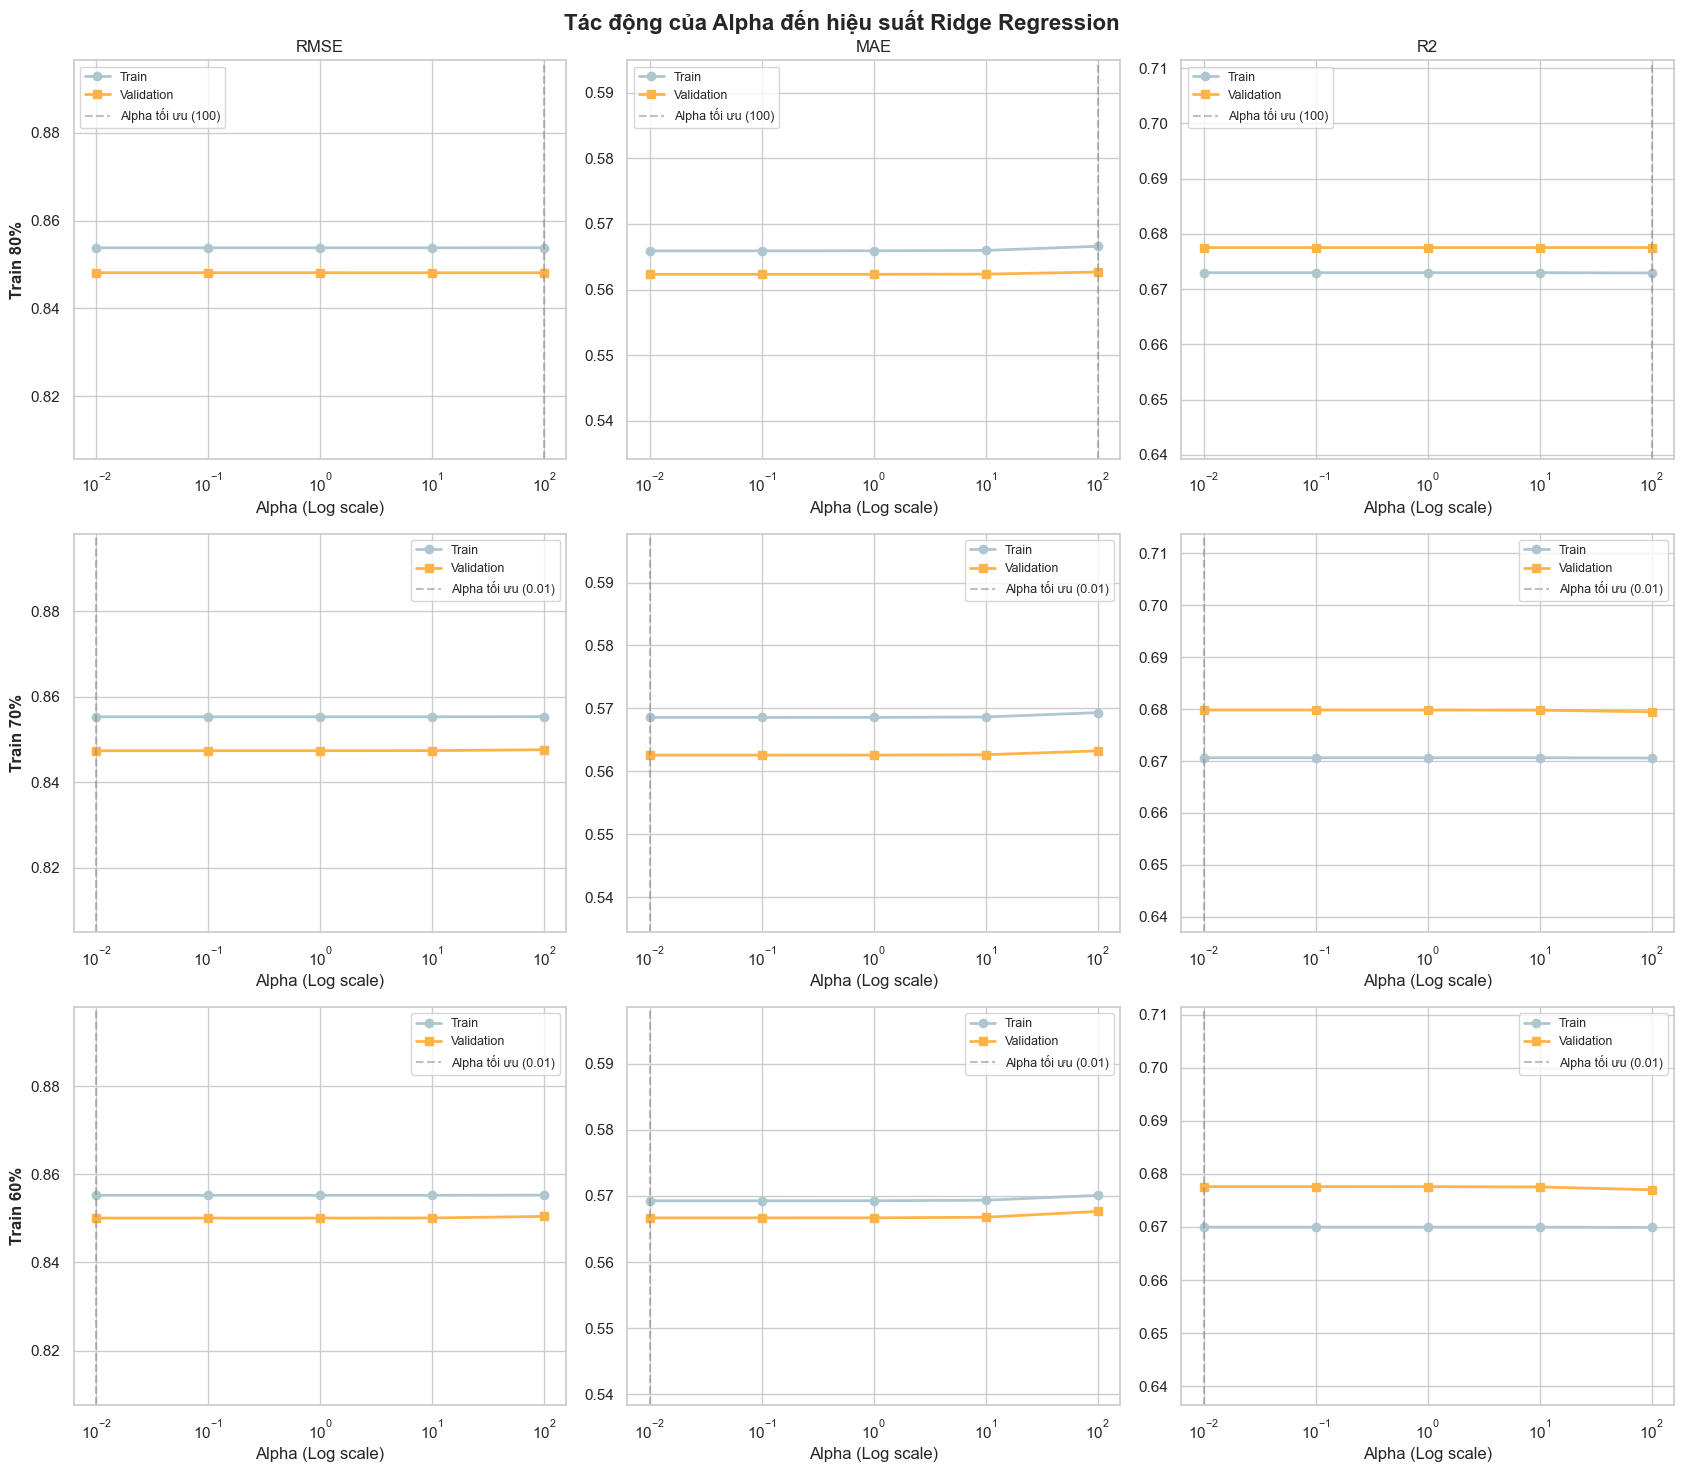

OVERFITTING ANALYSIS - Linear
Alpha | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
100 | Train 80%        |     0.6729 |     0.6775 |  -0.0046 |       0.8538 |     0.8481 |  -0.0057 |     0.5627 | Ổn định
0.01 | Train 70%        |     0.6706 |     0.6798 |  -0.0092 |       0.8553 |     0.8474 |  -0.0079 |     0.5626 | Ổn định
0.01 | Train 60%        |     0.6700 |     0.6776 |  -0.0076 |       0.8552 |     0.8501 |  -0.0052 |     0.5667 | Ổn định
--------------------------------------------------------------------------------


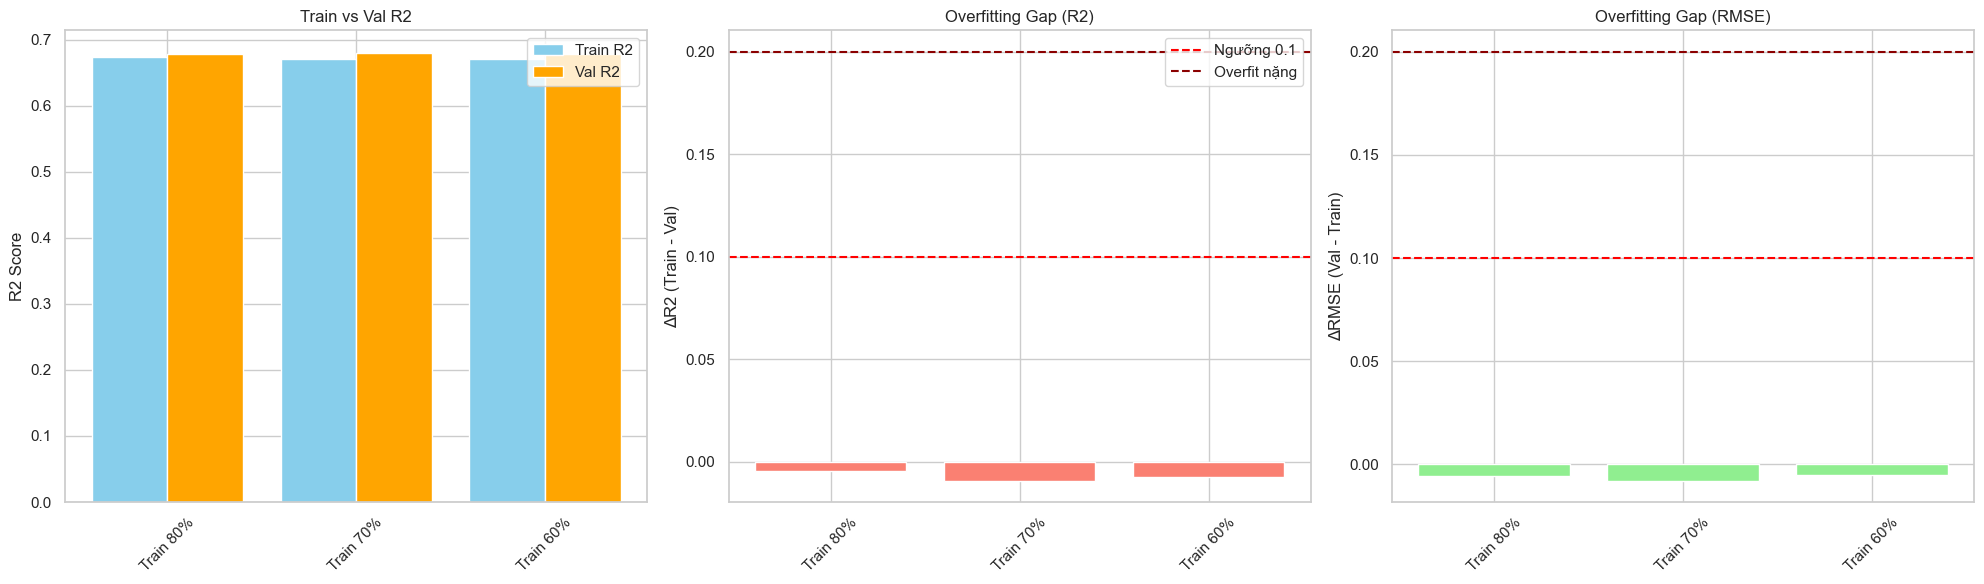

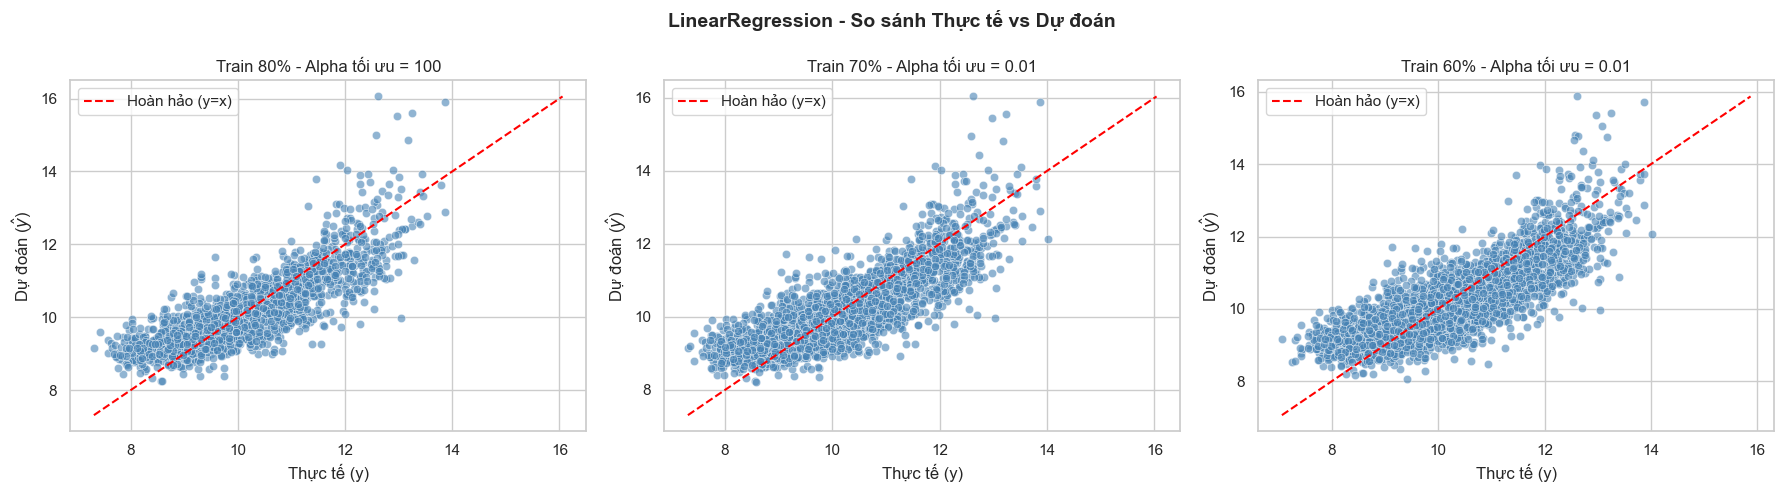

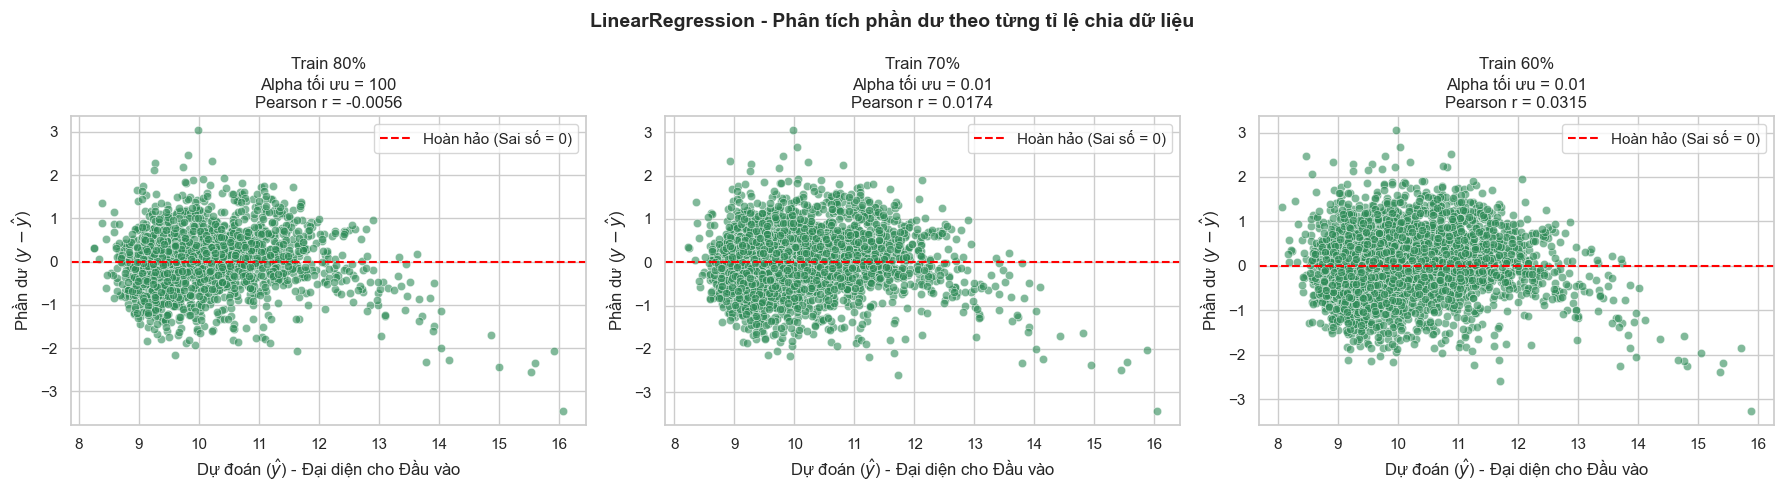

In [43]:

metrics_linear, predictions_data = evaluate_splits(
    X_pca, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomLinearRegression,
    model_kwargs={}
)

plot_metrics_bar(metrics_linear, "So sánh RMSE, MAE và R bằng phươn pháp Linear Regression")

best_linear_pca = plot_ridge_regularization(X_pca, y, test_sizes, labels)
analyze_overfitting(best_linear_pca, model_name="Linear")

plot_actual_vs_predicted(
    best_linear_pca,
    main_title="LinearRegression - So sánh Thực tế vs Dự đoán"
)
plot_residuals(
    best_linear_pca,
    main_title="LinearRegression - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)

#### 6.2.3 Multi Layers Perceptron

Tỷ lệ chia       | Mẫu Train  | Mẫu Test   | RMSE     | MAE      | R2 Score
________________________________________________________________________
Train 80%        |      7,147 |      1,786 |   0.7883 |   0.4852 |   0.7593
Train 70%        |      6,254 |      2,679 |   0.7992 |   0.4960 |   0.7467
Train 60%        |      5,360 |      3,573 |   0.8060 |   0.5065 |   0.7395
________________________________________________________________________


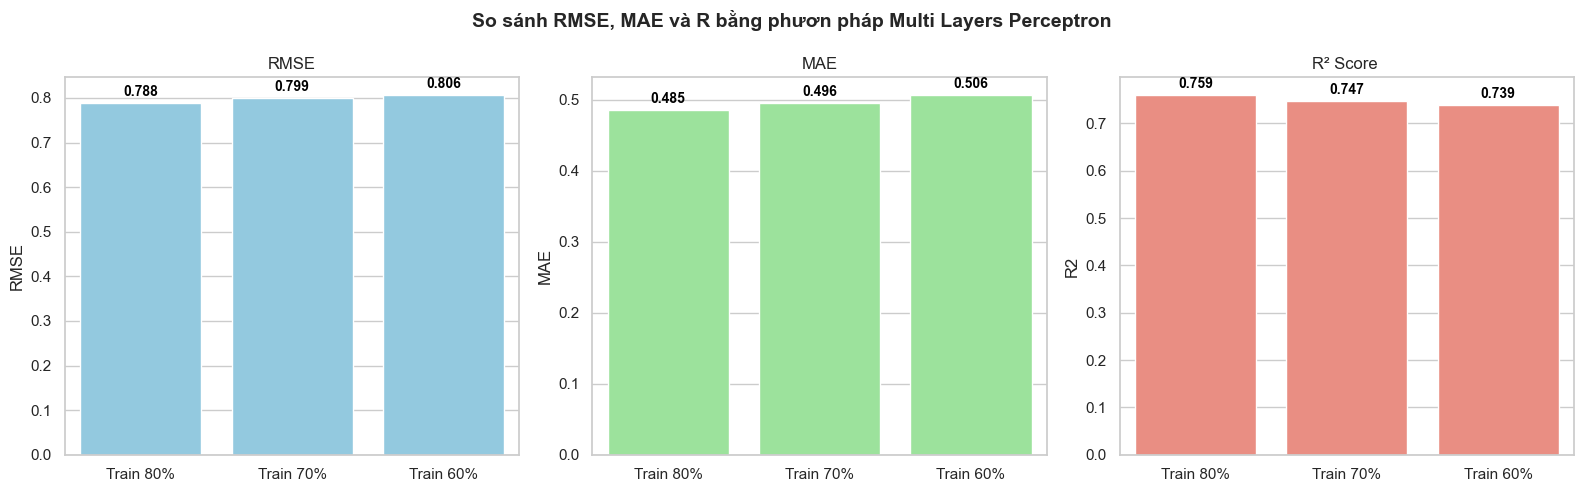

  [1/12] Train 80% | Alpha=0.1 ... dừng tại epoch 200
  [2/12] Train 80% | Alpha=1 ... dừng tại epoch 200
  [3/12] Train 80% | Alpha=10 ... dừng tại epoch 200
  [4/12] Train 80% | Alpha=100 ... dừng tại epoch 200

  Train 80%:
  Alpha          R2_train     R2_val   ΔR²(train-val)  Nhận xét
  -----------------------------------------------------------------
  0.1              0.7432     0.7279          +0.0154  Cân bằng
  1                0.7433     0.7280          +0.0153  Cân bằng
  10               0.7441     0.7296          +0.0145  Cân bằng
  100              0.7483     0.7417          +0.0067  Cân bằng ← CHỌN (R2_val cao nhất)

  → Chọn Alpha=100 vì R2_val=0.7417 cao nhất, ΔR²=+0.0067

  Re-train best model (Alpha=100)... dừng tại epoch 200

  [5/12] Train 70% | Alpha=0.1 ... dừng tại epoch 200
  [6/12] Train 70% | Alpha=1 ... dừng tại epoch 200
  [7/12] Train 70% | Alpha=10 ... dừng tại epoch 200
  [8/12] Train 70% | Alpha=100 ... dừng tại epoch 200

  Train 70%:
  Alpha         

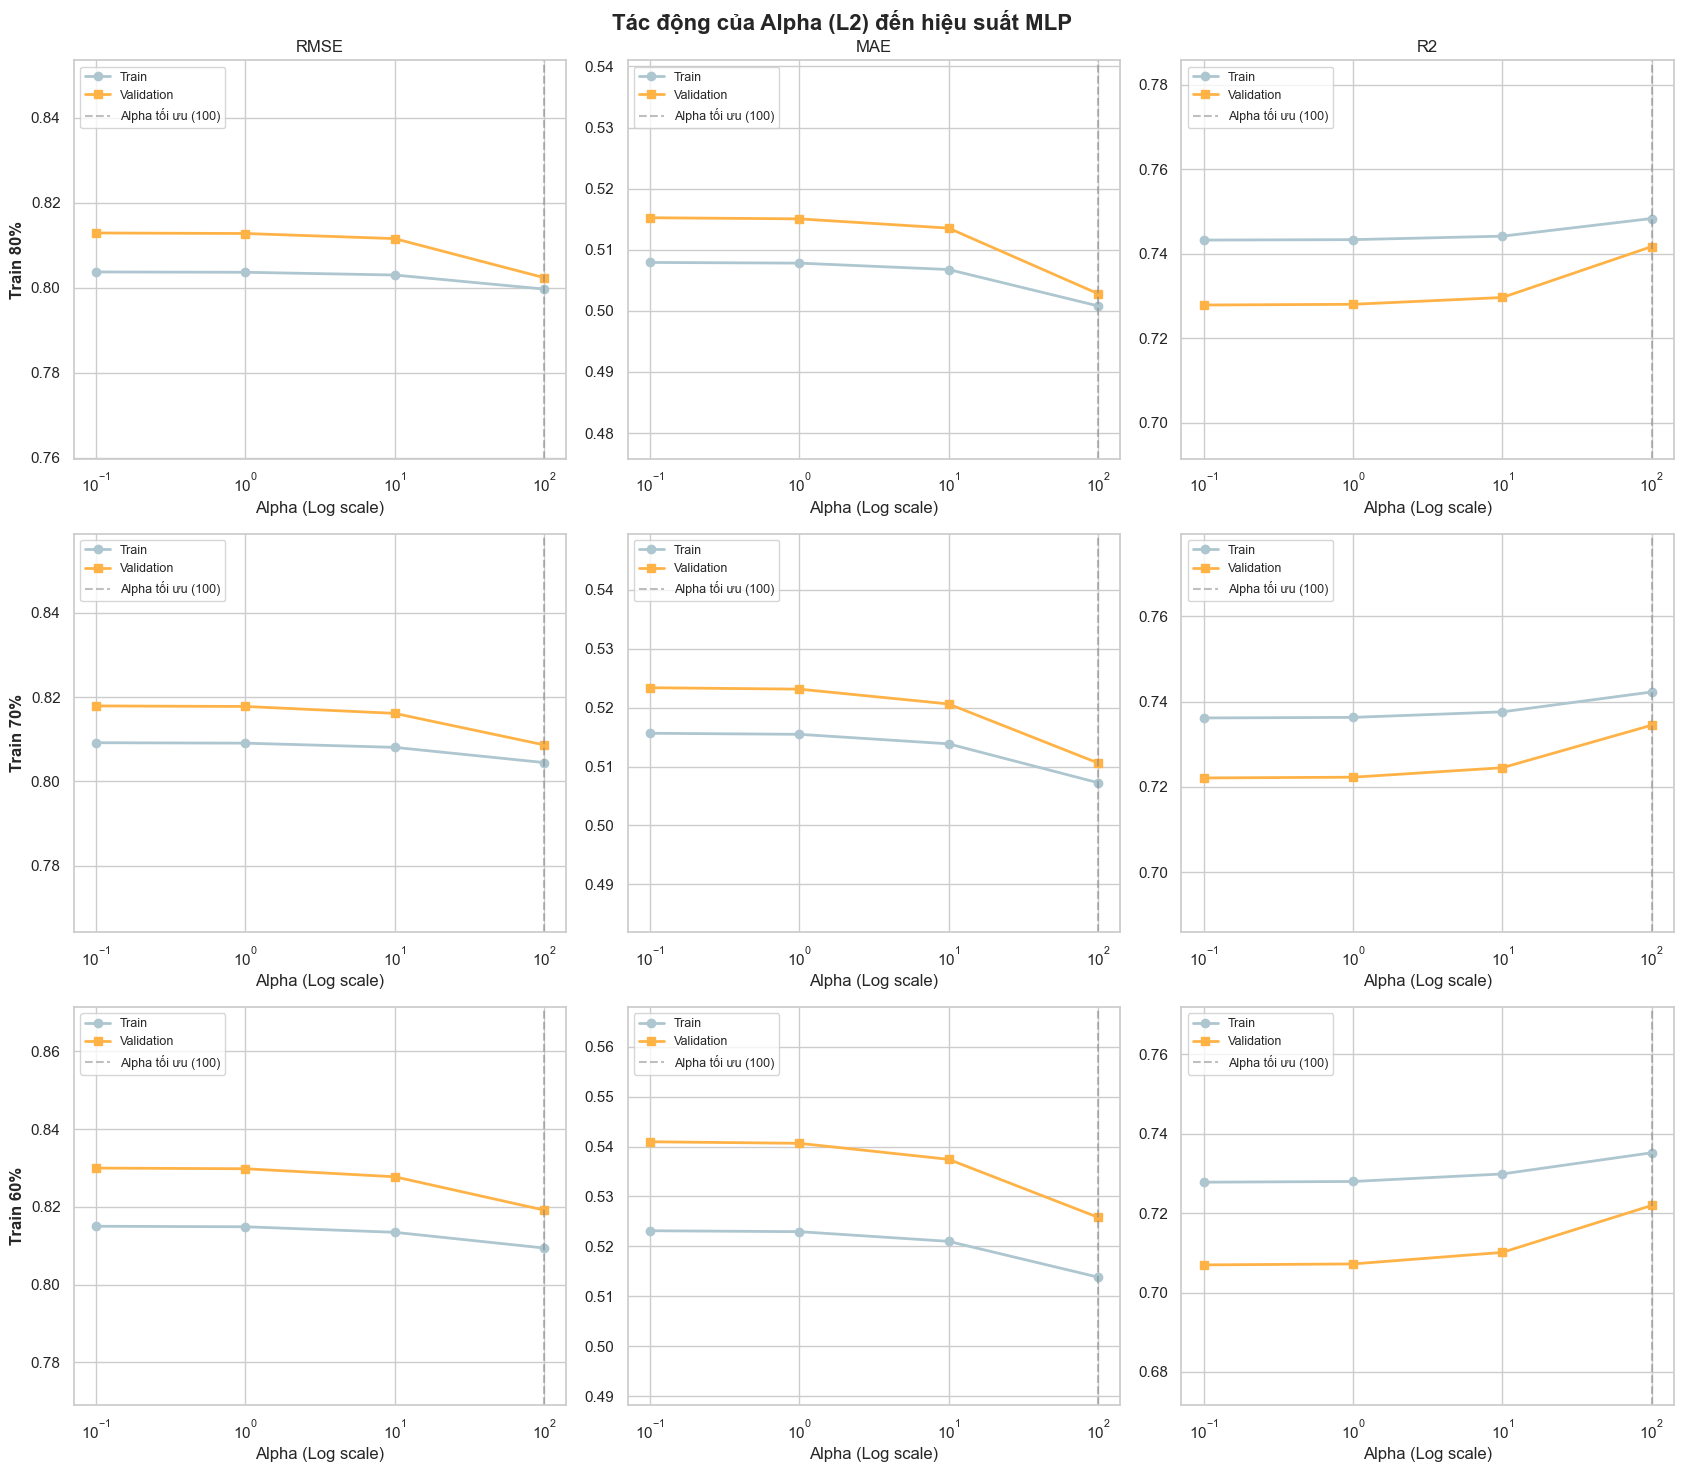

OVERFITTING ANALYSIS - MLP
Alpha | Tỉ lệ            |   R2 Train |     R2 Val |      ΔR2 |   RMSE Train |   RMSE Val |    ΔRMSE |  MAE val | Kết luận
--------------------------------------------------------------------------------
100 | Train 80%        |     0.7483 |     0.7417 |  +0.0067 |       0.7997 |     0.8024 |  +0.0027 |     0.5028 | Ổn định
100 | Train 70%        |     0.7422 |     0.7345 |  +0.0078 |       0.8045 |     0.8087 |  +0.0042 |     0.5106 | Ổn định
100 | Train 60%        |     0.7352 |     0.7219 |  +0.0133 |       0.8094 |     0.8192 |  +0.0098 |     0.5258 | Ổn định
--------------------------------------------------------------------------------


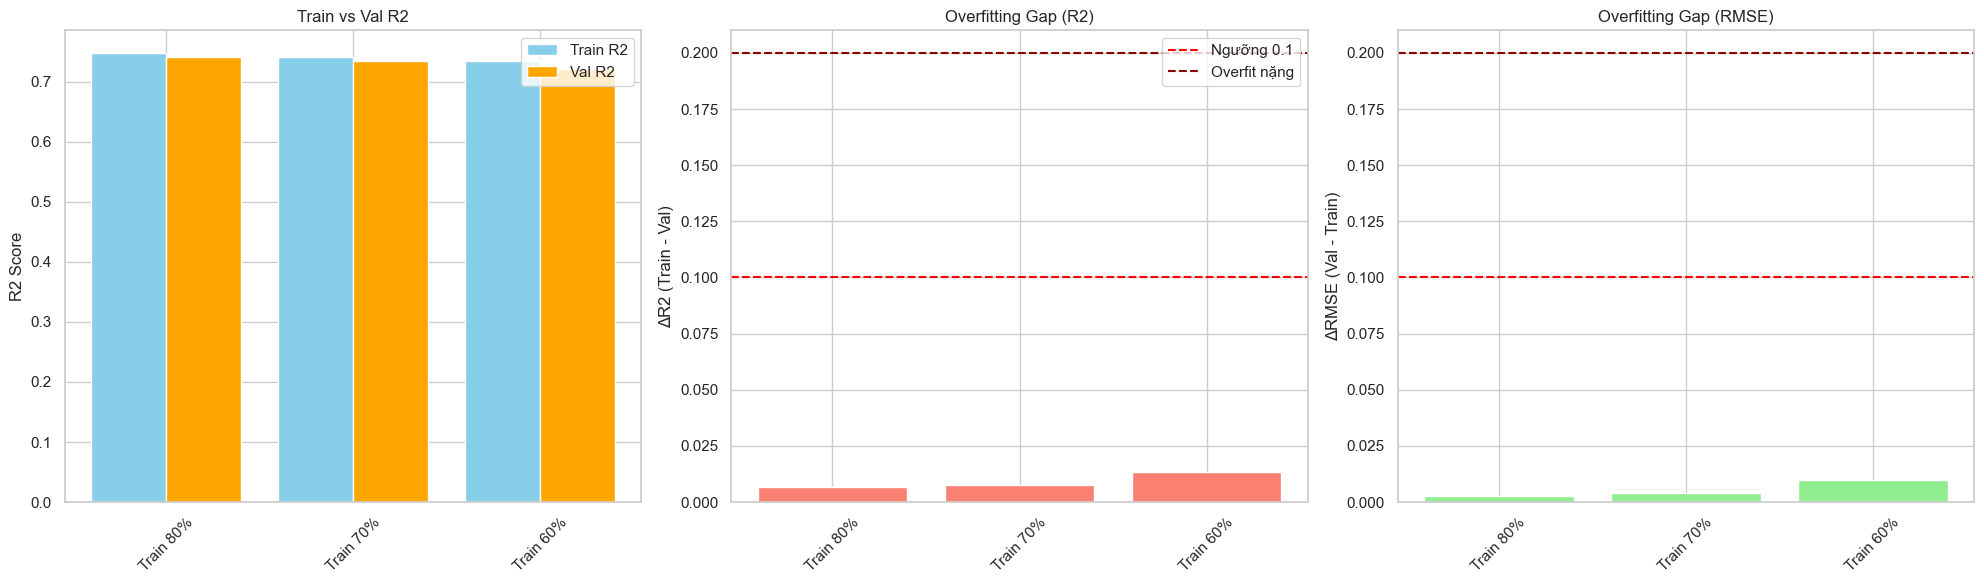

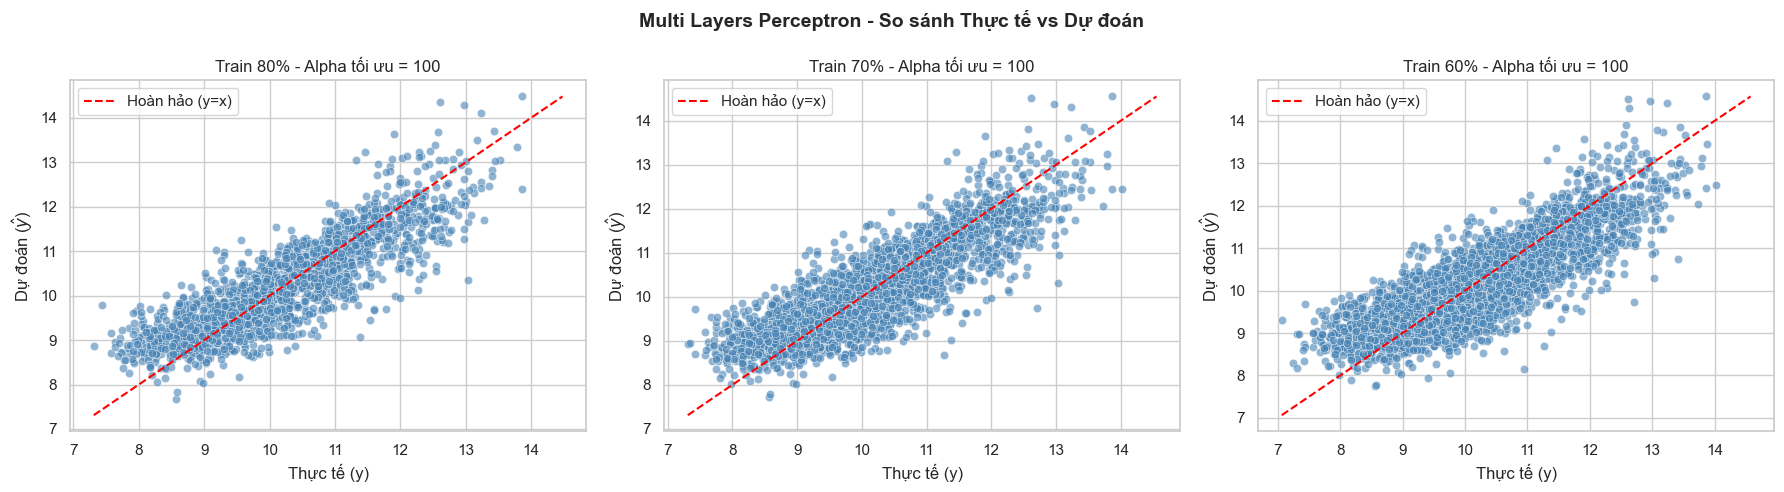

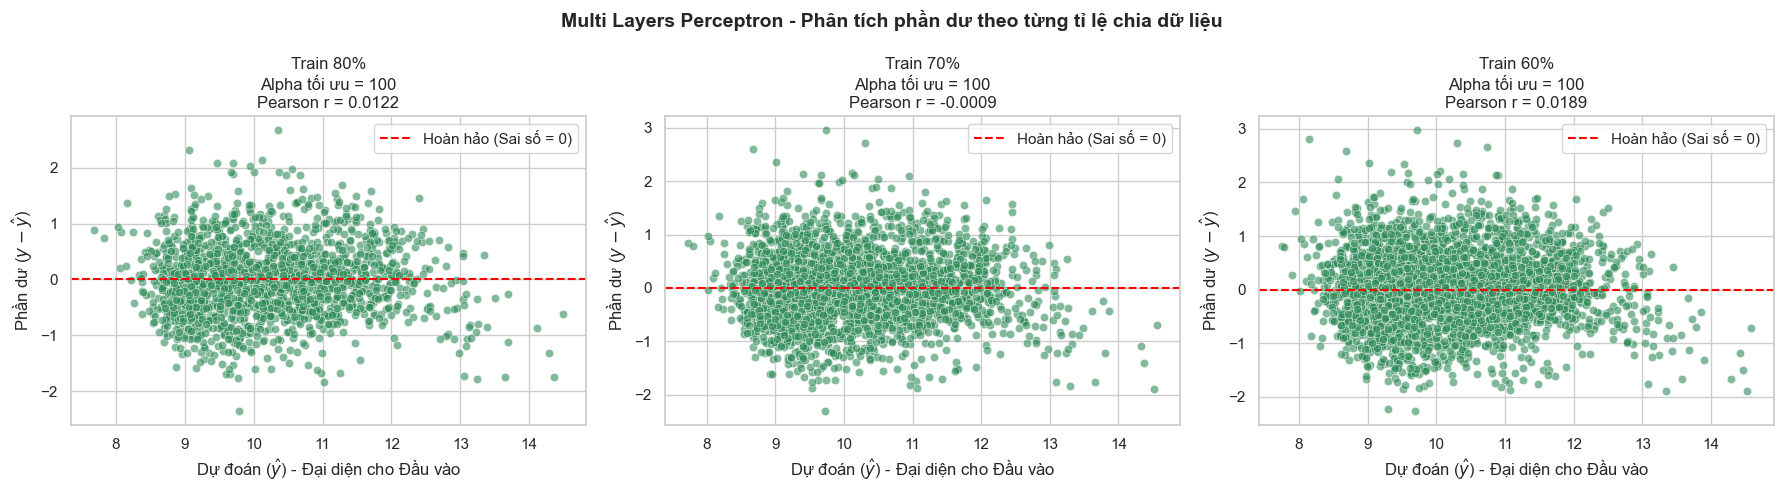

In [44]:
metrics_mlp, predictions_data = evaluate_splits(
    X_pca, y,
    test_sizes=test_sizes,
    labels=labels,
    model_class=CustomMLPRegressor,
    model_kwargs={
        "hidden_size": 64,
        "learning_rate": 0.01,  
        "epochs": 500,
        "lambda_reg": 0.01,
        "batch_size": 32
    }
)

plot_metrics_bar(metrics_mlp, "So sánh RMSE, MAE và R bằng phươn pháp Multi Layers Perceptron")

best_mlp_pca = plot_mlp_regularization(X_pca, y, test_sizes, labels)
analyze_overfitting(best_mlp_pca,   model_name="MLP")

plot_actual_vs_predicted(
    best_mlp_pca,
    main_title="Multi Layers Perceptron - So sánh Thực tế vs Dự đoán"
)
plot_residuals(
    best_mlp_pca,
    main_title="Multi Layers Perceptron - Phân tích phần dư theo từng tỉ lệ chia dữ liệu"
)


#### 6.2.4 Đánh giá

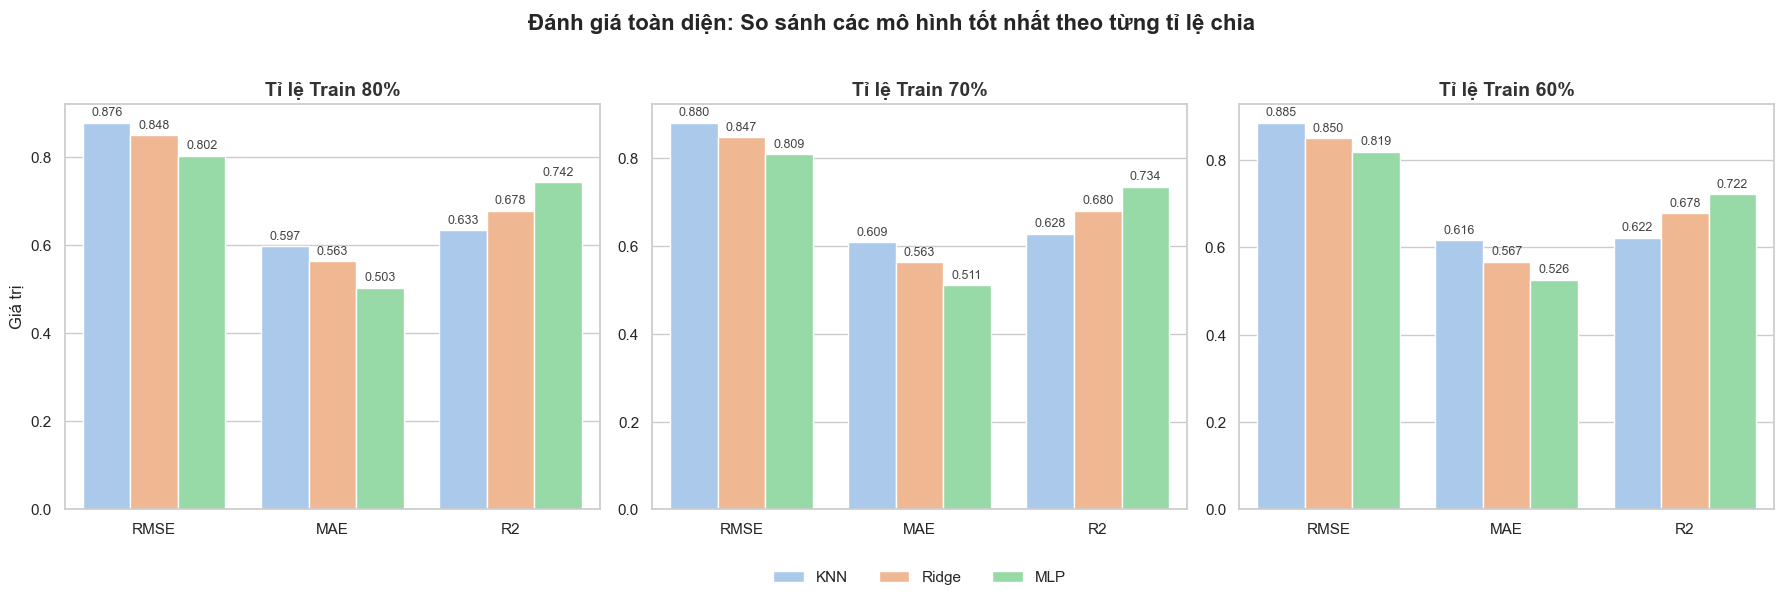

In [45]:
df_comparison = plot_best_models_comparison(best_knn_pca, best_linear_pca, best_mlp_pca)

### 6.3 Tổng kết

In [46]:
def print_regression_summary(best_knn_data, best_linear_data, best_mlp_data,
                              best_knn_pca, best_linear_pca, best_mlp_pca):

    SEP  = "=" * 80
    SEP2 = "-" * 80

    def build_results(knn, linear, mlp):
        out = {}
        for model_name, data in [('KNN', knn), ('Linear', linear), ('MLP', mlp)]:
            out[model_name] = {}
            for m in data:
                ratio = m['label'].split()[1]
                key   = ratio.replace('%','')
                out[model_name][key]          = (m['RMSE'], m['MAE'], m['R2'])
                out[model_name][f'of_{key}']  = (m['R2_train'] - m['R2'],
                                                  m['RMSE'] - m['RMSE_train'])
        return out

    results = {
        'Gốc': build_results(best_knn_data,  best_linear_data,  best_mlp_data),
        'PCA': build_results(best_knn_pca,   best_linear_pca,   best_mlp_pca),
    }

    # -------------------------------------------------------
    # BẢNG 1: HIỆU SUẤT
    # -------------------------------------------------------
    print(SEP)
    print("  BẢNG 1: HIỆU SUẤT CÁC MÔ HÌNH (Validation Set)")
    print(SEP)
    print(f"  {'Dữ liệu':<8} {'Mô hình':<10} {'Tỉ lệ':<12} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print(SEP2)
    for data_type, models in results.items():
        for model, metrics in models.items():
            for ratio in ['80','70','60']:
                rmse, mae, r2 = metrics[ratio]
                print(f"  {data_type:<8} {model:<10} {'Train '+ratio+'%':<12}"
                      f" {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}")
        print(SEP2)

    # -------------------------------------------------------
    # BẢNG 2: OVERFITTING
    # -------------------------------------------------------
    print(f"\n{SEP}")
    print("  BẢNG 2: ĐÁNH GIÁ OVERFITTING (ΔR² = R²_train − R²_val)")
    print(SEP)
    print(f"  {'Dữ liệu':<8} {'Mô hình':<10} {'Tỉ lệ':<12} {'ΔR²':>8} {'ΔRMSE':>8}  Trạng thái")
    print(SEP2)
    for data_type, models in results.items():
        for model, metrics in models.items():
            for ratio in ['80','70','60']:
                dr2, drmse = metrics[f'of_{ratio}']
                if abs(dr2) > 0.2 or abs(drmse) > 0.2:
                    status = " Overfit nặng"
                elif abs(dr2) > 0.1 or abs(drmse) > 0.1:
                    status = "  Overfit nhẹ"
                else:
                    status = " Ổn định"
                print(f"  {data_type:<8} {model:<10} {'Train '+ratio+'%':<12}"
                      f" {dr2:>+8.4f} {drmse:>+8.4f}  {status}")
        print(SEP2)

    # -------------------------------------------------------
    # Tính toán để nhận xét động
    # -------------------------------------------------------
    r2  = lambda dt, m, r: results[dt][m][r][2]
    dr2 = lambda dt, m, r: results[dt][m][f'of_{r}'][0]

    r2_best = {f'{m}/{dt}': results[dt][m]['80'][2]
               for dt in ['Gốc','PCA'] for m in ['KNN','Linear','MLP']}
    best_model = max(r2_best, key=r2_best.get)

    # Mức độ nhạy cảm tỉ lệ chia (chênh R² giữa 80% và 60%)
    sens = {f'{m}/Gốc': abs(r2('Gốc',m,'80') - r2('Gốc',m,'60'))
            for m in ['KNN','Linear','MLP']}
    most_sensitive   = max(sens, key=sens.get)
    most_stable_ratio = min(sens, key=sens.get)

    # PCA stability so sánh ΔR² max
    def max_dr2(dt, m):
        return max(abs(dr2(dt, m, r)) for r in ['80','70','60'])

    print(f"""
{SEP}
  NHẬN XÉT CHI TIẾT
{SEP}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. HIỆU SUẤT CÁC MÔ HÌNH (Tỉ lệ 80/20, dữ liệu gốc)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   MLP (R²={r2('Gốc','MLP','80'):.4f}) > Linear (R²={r2('Gốc','Linear','80'):.4f}) > KNN (R²={r2('Gốc','KNN','80'):.4f})

   - KNN (R²={r2('Gốc','KNN','80'):.4f}): Đạt hiệu suất thấp nhất trong 3 mô hình. Với
     bộ dữ liệu SUPPORT2 có nhiều chiều đặc trưng, khoảng cách Euclidean kém
     phân biệt hơn trong không gian chiều cao ("curse of dimensionality"), khiến
     các láng giềng gần không thực sự mang ý nghĩa tương đồng lâm sàng.

   - Linear Regression (R²={r2('Gốc','Linear','80'):.4f}): Cải thiện đáng kể so với KNN
     (+{r2('Gốc','Linear','80')-r2('Gốc','KNN','80'):.4f} R²). Kết quả này cho thấy tồn tại mối quan hệ
     tuyến tính đáng kể giữa các chỉ số lâm sàng (huyết áp, nhịp tim, pH máu,
     tuổi tác...) và chi phí điều trị. Tuy nhiên giới hạn ở giả định tuyến tính
     khiến mô hình không nắm bắt được các tương tác phức tạp giữa các biến.

   - MLP (R²={r2('Gốc','MLP','80'):.4f}): Vượt trội rõ rệt so với 2 mô hình còn lại
     (+{r2('Gốc','MLP','80')-r2('Gốc','Linear','80'):.4f} R² so với Linear). Lớp ẩn 64 neurons với
     hàm kích hoạt ReLU cho phép MLP học được các quan hệ phi tuyến và tương tác
     giữa các chỉ số (ví dụ: pH máu thấp kết hợp nhịp tim cao → chi phí đột
     biến), điều mà Linear Regression không thể mô hình hóa được.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. ẢNH HƯỞNG CỦA TỈ LỆ CHIA TRAIN/VALIDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   - Cả 3 mô hình đều đạt hiệu suất tốt nhất ở tỉ lệ 80/20 — tập train lớn
     hơn cung cấp nhiều mẫu học hơn, đặc biệt quan trọng với MLP và KNN.

   - Mức độ nhạy cảm với tỉ lệ chia (chênh R² giữa 80% và 60%):
     - KNN:    ΔR²={sens['KNN/Gốc']:.4f} → Nhạy cảm nhất, cần nhiều dữ liệu train
     - MLP:    ΔR²={sens['MLP/Gốc']:.4f} → Nhạy cảm vừa
     - Linear: ΔR²={sens['Linear/Gốc']:.4f} → Ổn định nhất, ít phụ thuộc kích thước train

   - Linear Regression ổn định nhất vì normal equation tìm nghiệm tối ưu toàn
     cục — không bị ảnh hưởng bởi random initialization hay learning rate như MLP.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. ĐÁNH GIÁ OVERFITTING VÀ REGULARIZATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   - KNN (ΔR² max = {max_dr2('Gốc','KNN'):+.4f}): Có xu hướng overfit tự nhiên nhẹ do
     mô hình "ghi nhớ" các điểm lân cận trong tập train. Kiểm soát bằng cách
     chọn K tối ưu qua validation (K lớn hơn → smooth hơn, giảm overfit).
     ΔR² nằm trong ngưỡng ổn định (<0.1) sau regularization.

   - Linear/Ridge (ΔR² âm = {dr2('Gốc','Linear','80'):+.4f} đến {dr2('Gốc','Linear','60'):+.4f}):
     ΔR² âm nghĩa là R² validation nhỉnh hơn train — hoàn toàn không overfit.
     Đây là hiệu ứng của Ridge (L2): Alpha phạt các hệ số lớn, "kìm" mô hình
     train lại, trong khi val set không bị ràng buộc này. Alpha tối ưu được
     chọn qua dải [0.01 → 100000] trên validation.

   - MLP (ΔR² max = {max_dr2('Gốc','MLP'):+.4f}): ΔR² dương nhưng rất nhỏ, kiểm soát
     hiệu quả bằng lambda_reg=0.01 (L2 penalty) kết hợp mini-batch SGD
     (batch_size=32) — mini-batch vốn có tác dụng regularize nhẹ do gradient
     noise giữa các batch. Xu hướng ΔR² tăng khi train nhỏ hơn là bình thường.

   → Kết luận: KHÔNG có mô hình nào bị overfit đáng kể sau regularization.
     Tất cả ΔR² đều nằm trong ngưỡng ổn định (< 0.1).

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. SO SÁNH DỮ LIỆU GỐC vs DỮ LIỆU GIẢM CHIỀU (PCA)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   Mô hình  │ R² Gốc  │ R² PCA  │  Δ R²   │ ΔR²_of Gốc │ ΔR²_of PCA
   ─────────┼─────────┼─────────┼─────────┼────────────┼───────────
   KNN      │ {r2('Gốc','KNN','80'):.4f}  │ {r2('PCA','KNN','80'):.4f}  │ {r2('Gốc','KNN','80')-r2('PCA','KNN','80'):+.4f}  │   {max_dr2('Gốc','KNN'):+.4f}    │  {max_dr2('PCA','KNN'):+.4f}
   Linear   │ {r2('Gốc','Linear','80'):.4f}  │ {r2('PCA','Linear','80'):.4f}  │ {r2('Gốc','Linear','80')-r2('PCA','Linear','80'):+.4f}  │   {max_dr2('Gốc','Linear'):+.4f}    │  {max_dr2('PCA','Linear'):+.4f}
   MLP      │ {r2('Gốc','MLP','80'):.4f}  │ {r2('PCA','MLP','80'):.4f}  │ {r2('Gốc','MLP','80')-r2('PCA','MLP','80'):+.4f}  │   {max_dr2('Gốc','MLP'):+.4f}    │  {max_dr2('PCA','MLP'):+.4f}

   - Dữ liệu gốc vượt trội ở tất cả mô hình. PCA nén dữ liệu xuống 20 chiều
     (giữ 84.1% phương sai), mất ~15.9% thông tin làm giảm R² đáng kể.

   - Linear Regression chịu ảnh hưởng nhiều nhất từ PCA
     (ΔR²={r2('Gốc','Linear','80')-r2('PCA','Linear','80'):+.4f}): hồi quy tuyến tính phụ thuộc trực tiếp
     vào các features gốc — PCA biến đổi thành các thành phần chính trực giao
     làm mất đi ý nghĩa tuyến tính ban đầu của từng biến.

   - KNN/PCA: ΔR²_of tăng từ {max_dr2('Gốc','KNN'):.4f} lên {max_dr2('PCA','KNN'):.4f} — PCA làm KNN
     kém ổn định hơn vì thay đổi cấu trúc không gian khoảng cách, khiến các
     láng giềng gần trên PCA không phản ánh đúng sự tương đồng thực tế.

   - MLP/PCA: ΔR²_of giảm từ {max_dr2('Gốc','MLP'):.4f} xuống {max_dr2('PCA','MLP'):.4f} — PCA có lợi
     cho MLP về mặt ổn định, dù đánh đổi một phần accuracy ({r2('Gốc','MLP','80')-r2('PCA','MLP','80'):+.4f} R²).
     Không gian PCA ít nhiễu hơn giúp MLP không bị overfit vào các features
     không quan trọng.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. ĐÁNH GIÁ PHẦN DƯ — MÔ HÌNH CÓ PHÙ HỢP KHÔNG?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

   - KNN: Phần dư phân tán không đồng đều — tập trung ở vùng chi phí thấp,
     trải rộng ở vùng chi phí cao (heteroscedasticity). KNN không nội suy
     tốt ở các ca bệnh nặng có chi phí đột biến, phần dư thường lệch dương
     ở vùng giá trị lớn. Mô hình CHƯA PHÙ HỢP hoàn toàn.

   - Linear Regression: Phần dư phân tán gần đối xứng quanh đường y=0, không
     có pattern cong rõ ràng — dấu hiệu tốt cho giả định tuyến tính. Tuy nhiên
     vẫn còn outlier ở chi phí rất cao, gợi ý mối quan hệ không hoàn toàn
     tuyến tính. Mô hình PHÙ HỢP Ở MỨC VỪA.

   - MLP: Phần dư ngẫu nhiên nhất trong 3 mô hình, xu hướng (trend line) gần
     nằm ngang — cho thấy không có pattern hệ thống còn sót lại. Std residual
     thấp nhất, mean residual gần 0 nhất. Mô hình PHÙ HỢP TỐT NHẤT.

   → Cả 3 mô hình còn tồn tại outlier ở vùng chi phí điều trị cực cao — đây
     là đặc trưng của dữ liệu y tế (một số ca bệnh đặc biệt phức tạp khó dự
     đoán). Hướng cải thiện: log-transform biến 'charges' để giảm right-skew,
     hoặc xây dựng mô hình riêng cho nhóm bệnh nhân chi phí cao.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. KẾT LUẬN VÀ KHUYẾN NGHỊ
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

    Mô hình tốt nhất tổng thể: {best_model}
     R²={r2_best[best_model]:.4f}, RMSE={results[best_model.split('/')[1]][best_model.split('/')[0]]['80'][0]:.4f}

   - Ưu tiên độ chính xác    → MLP trên dữ liệu gốc, tỉ lệ 80/20
   - Ưu tiên tính giải thích → Linear Regression (hệ số hồi quy dễ trình bày)
   - Ưu tiên tài nguyên thấp → KNN (không cần train, nhưng kém chính xác)

   Hướng cải thiện tiếp theo:
   (1) Log-transform biến mục tiêu 'charges' để giảm right-skew
   (2) Tăng hidden layers hoặc neurons cho MLP
   (3) Feature selection kỹ hơn để giảm noise trước khi đưa vào KNN
{SEP}
""")

# Gọi hàm
print_regression_summary(
    best_knn_data,   best_linear_data,   best_mlp_data,
    best_knn_pca,    best_linear_pca,    best_mlp_pca
)

  BẢNG 1: HIỆU SUẤT CÁC MÔ HÌNH (Validation Set)
  Dữ liệu  Mô hình    Tỉ lệ            RMSE      MAE       R²
--------------------------------------------------------------------------------
  Gốc      KNN        Train 80%      0.8688   0.5921   0.6449
  Gốc      KNN        Train 70%      0.8742   0.6011   0.6374
  Gốc      KNN        Train 60%      0.8820   0.6129   0.6263
  Gốc      Linear     Train 80%      0.8167   0.5203   0.7227
  Gốc      Linear     Train 70%      0.8182   0.5237   0.7217
  Gốc      Linear     Train 60%      0.8216   0.5271   0.7186
  Gốc      MLP        Train 80%      0.7628   0.4495   0.7890
  Gốc      MLP        Train 70%      0.7740   0.4627   0.7771
  Gốc      MLP        Train 60%      0.7893   0.4785   0.7604
--------------------------------------------------------------------------------
  PCA      KNN        Train 80%      0.8762   0.5971   0.6326
  PCA      KNN        Train 70%      0.8798   0.6085   0.6280
  PCA      KNN        Train 60%      0.8847  